# E-Commerce Churn & Retention Analytics

## Project Overview

Customer churn occurs when existing customers stop purchasing from a business. Unlike subscription-based industries, e-commerce customers do not formally cancel their relationship with a company. Therefore, churn must be identified by analysing customer purchasing behaviour and periods of inactivity.

This project develops a time-aware machine-learning solution to predict customers who are likely to stop purchasing within a defined future period. It also estimates the revenue associated with high-risk customers and supports data-driven retention prioritisation.

## Business Problem

Retaining an existing customer is often more efficient than repeatedly acquiring new customers. However, businesses cannot contact every inactive or declining customer with the same level of attention.

The business therefore needs to answer four important questions:

1. Which customers are most likely to churn?
2. What behavioural factors are contributing to their churn risk?
3. How much customer revenue may be at risk?
4. Which customers should be prioritised for retention campaigns?

## Project Objectives

The objectives of this project are to:

* Clean and validate transaction-level retail data.
* Analyse customer purchasing and repeat-order behaviour.
* Develop a suitable behavioural definition of customer churn.
* Create customer-level features using historical transactions.
* Compare multiple classification models.
* Evaluate the model using both statistical and business-focused metrics.
* Explain the important drivers behind churn predictions.
* Estimate customer value and revenue at risk.
* Prioritise high-risk, high-value customers for retention.
* Develop an interactive Power BI dashboard for business decision-making.

## Dataset

The project uses the **Online Retail II** dataset from the UCI Machine Learning Repository. It contains more than one million transactions recorded by a UK-based non-store online retailer between December 2009 and December 2011.

The dataset includes invoice details, product information, quantities, transaction dates, unit prices, customer identifiers, customer countries and cancelled transactions.

**Dataset source:** [UCI Online Retail II](https://archive.ics.uci.edu/dataset/502/online%2Bretail%2Bii)

## Planned Churn Definition

The initial working definition considers a customer to have churned if they were active during the historical observation period but made no completed purchase during the following 90 days.

Before finalising this definition, customer repurchase intervals will be analysed to determine whether a 60-day, 90-day or 120-day inactivity period represents the most appropriate churn threshold.

## Project Workflow

The project will cover:

1. Data collection and inspection
2. Data cleaning and validation
3. Exploratory data analysis
4. Customer behaviour and cohort analysis
5. Churn-label development
6. RFM and behavioural feature engineering
7. Time-based training, validation and testing
8. Machine-learning model comparison
9. Model evaluation and explainability
10. Revenue-at-risk estimation
11. Customer retention prioritisation
12. Power BI dashboard development
13. Model documentation and GitHub presentation



In [1]:
# Step 1: Download and extract the Online Retail II dataset

from pathlib import Path
from urllib.request import urlretrieve
from zipfile import ZipFile

DATA_DIR = Path("/content/customer_churn_data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

dataset_url = (
    "https://archive.ics.uci.edu/static/public/502/"
    "online%2Bretail%2Bii.zip"
)

zip_path = DATA_DIR / "online_retail_ii.zip"

print("Downloading dataset...")
urlretrieve(dataset_url, zip_path)

print("Extracting dataset...")
with ZipFile(zip_path, "r") as zip_file:
    zip_file.extractall(DATA_DIR)

print("\nDataset setup completed successfully.")
print("Available files:")

for file in DATA_DIR.iterdir():
    print("-", file.name)

Extracting dataset...

Dataset setup completed successfully.
Available files:
- online_retail_ii.zip
- online_retail_II.xlsx


## 1. Data Collection and Workbook Inspection

The Excel workbook is inspected to confirm its size and available transaction periods before loading the complete dataset.



In [2]:
# Step 2: Inspect the Excel workbook structure

from pathlib import Path
import pandas as pd

DATA_DIR = Path("/content/customer_churn_data")
excel_path = DATA_DIR / "online_retail_II.xlsx"

workbook = pd.ExcelFile(excel_path, engine="openpyxl")
file_size_mb = excel_path.stat().st_size / (1024 ** 2)

print(f"Workbook name: {excel_path.name}")
print(f"Workbook size: {file_size_mb:.2f} MB")
print(f"Number of worksheets: {len(workbook.sheet_names)}")
print("\nWorksheet names:")

for number, sheet_name in enumerate(workbook.sheet_names, start=1):
    print(f"{number}. {sheet_name}")

Workbook name: online_retail_II.xlsx
Workbook size: 43.51 MB
Number of worksheets: 2

Worksheet names:
1. Year 2009-2010
2. Year 2010-2011


## 2. Initial Dataset Preview

A small sample from each worksheet is examined to verify the columns and data structure before loading all transactions.



In [3]:
# Step 3: Preview the first five rows from both worksheets

preview_2009_2010 = pd.read_excel(
    excel_path,
    sheet_name="Year 2009-2010",
    nrows=5,
    engine="openpyxl"
)

preview_2010_2011 = pd.read_excel(
    excel_path,
    sheet_name="Year 2010-2011",
    nrows=5,
    engine="openpyxl"
)

print("Year 2009-2010")
display(preview_2009_2010)

print("\nYear 2010-2011")
display(preview_2010_2011)

print("\nColumns in Year 2009-2010:")
print(preview_2009_2010.columns.tolist())

print("\nColumns in Year 2010-2011:")
print(preview_2010_2011.columns.tolist())

Year 2009-2010


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom



Year 2010-2011


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom



Columns in Year 2009-2010:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

Columns in Year 2010-2011:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


## 3. Loading and Combining the Dataset

Both yearly worksheets are loaded and combined into one transaction dataset. A source-period column is retained for traceability.


In [4]:
# Step 4: Load and combine both worksheets

print("Loading Year 2009-2010...")
data_2009_2010 = pd.read_excel(
    excel_path,
    sheet_name="Year 2009-2010",
    engine="openpyxl"
)

print("Loading Year 2010-2011...")
data_2010_2011 = pd.read_excel(
    excel_path,
    sheet_name="Year 2010-2011",
    engine="openpyxl"
)

first_shape = data_2009_2010.shape
second_shape = data_2010_2011.shape

data_2009_2010["SourcePeriod"] = "2009-2010"
data_2010_2011["SourcePeriod"] = "2010-2011"

retail_raw = pd.concat(
    [data_2009_2010, data_2010_2011],
    ignore_index=True
)

print("\nLoading completed.")
print(f"Year 2009-2010 shape: {first_shape}")
print(f"Year 2010-2011 shape: {second_shape}")
print(f"Combined dataset shape: {retail_raw.shape}")
print(f"Date range: {retail_raw['InvoiceDate'].min()} to "
      f"{retail_raw['InvoiceDate'].max()}")

display(retail_raw.head())

Loading Year 2009-2010...
Loading Year 2010-2011...

Loading completed.
Year 2009-2010 shape: (525461, 8)
Year 2010-2011 shape: (541910, 8)
Combined dataset shape: (1067371, 9)
Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,SourcePeriod
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,2009-2010
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009-2010
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009-2010
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,2009-2010
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,2009-2010


## 4. Initial Data-Quality Assessment

The dataset is checked for missing values, duplicate records, data types and unique values before cleaning.


In [5]:
# Step 5: Perform an initial data-quality assessment

audit_table = pd.DataFrame({
    "Data Type": retail_raw.dtypes.astype(str),
    "Missing Values": retail_raw.isna().sum(),
    "Missing (%)": (
        retail_raw.isna().mean() * 100
    ).round(2),
    "Unique Values": retail_raw.nunique(dropna=True)
})

duplicate_rows = retail_raw.duplicated().sum()
memory_mb = retail_raw.memory_usage(deep=True).sum() / (1024 ** 2)

print(f"Total rows: {retail_raw.shape[0]:,}")
print(f"Total columns: {retail_raw.shape[1]}")
print(f"Exact duplicate rows: {duplicate_rows:,}")
print(f"Memory usage: {memory_mb:.2f} MB\n")

display(audit_table)

Total rows: 1,067,371
Total columns: 9
Exact duplicate rows: 12,133
Memory usage: 308.09 MB



,Data Type,Missing Values,Missing (%),Unique Values
Invoice,object,0,0.00,53628
StockCode,object,0,0.00,5305
Description,object,4382,0.41,5698
Quantity,int64,0,0.00,1057
InvoiceDate,datetime64[ns],0,0.00,47635
Price,float64,0,0.00,2807
Customer ID,float64,243007,22.77,5942
Country,object,0,0.00,43
SourcePeriod,object,0,0.00,2


### Transaction Integrity Checks

The audit identified duplicate records and substantial missing Customer IDs. Cancellations, returns and non-positive prices are examined before applying cleaning rules.


In [6]:
# Step 6: Examine transaction integrity

invoice_text = (
    retail_raw["Invoice"]
    .astype("string")
    .str.strip()
    .str.upper()
)

is_cancellation = invoice_text.str.startswith("C", na=False)
is_negative_quantity = retail_raw["Quantity"] < 0

integrity_checks = pd.DataFrame({
    "Condition": [
        "Cancellation invoice rows",
        "Negative quantity rows",
        "Zero quantity rows",
        "Zero price rows",
        "Negative price rows",
        "Missing Customer ID rows",
        "Missing Description rows",
        "Exact duplicate rows"
    ],
    "Rows": [
        is_cancellation.sum(),
        is_negative_quantity.sum(),
        (retail_raw["Quantity"] == 0).sum(),
        (retail_raw["Price"] == 0).sum(),
        (retail_raw["Price"] < 0).sum(),
        retail_raw["Customer ID"].isna().sum(),
        retail_raw["Description"].isna().sum(),
        retail_raw.duplicated().sum()
    ]
})

integrity_checks["Percentage (%)"] = (
    integrity_checks["Rows"] / len(retail_raw) * 100
).round(2)

display(integrity_checks)

print("Cancellation and quantity relationship:")
display(pd.crosstab(
    is_cancellation.map({True: "Cancellation", False: "Regular"}),
    is_negative_quantity.map({
        True: "Negative quantity",
        False: "Zero or positive quantity"
    }),
    margins=True
))

print(f"Quantity range: {retail_raw['Quantity'].min()} "
      f"to {retail_raw['Quantity'].max()}")

print(f"Price range: {retail_raw['Price'].min()} "
      f"to {retail_raw['Price'].max()}")

,Condition,Rows,Percentage (%)
0,Cancellation invoice rows,19494,1.83
1,Negative quantity rows,22950,2.15
2,Zero quantity rows,0,0.00
3,Zero price rows,6202,0.58
4,Negative price rows,5,0.00
5,Missing Customer ID rows,243007,22.77
6,Missing Description rows,4382,0.41
7,Exact duplicate rows,12133,1.14


Cancellation and quantity relationship:


Quantity,Negative quantity,Zero or positive quantity,All
Invoice,,,
Cancellation,19493,1,19494
Regular,3457,1044420,1047877
All,22950,1044421,1067371


Quantity range: -80995 to 80995
Price range: -53594.36 to 38970.0


## 5. Data Cleaning and Transaction Classification

Duplicates and anonymous transactions are removed because they cannot support customer tracking. Purchases, cancellations and return adjustments are retained as separate transaction types.


In [7]:
# Step 7: Clean and classify customer-linked transactions

import numpy as np

column_names = {
    "Invoice": "invoice_id",
    "StockCode": "stock_code",
    "Description": "description",
    "Quantity": "quantity",
    "InvoiceDate": "invoice_date",
    "Price": "unit_price",
    "Customer ID": "customer_id",
    "Country": "country",
    "SourcePeriod": "source_period"
}

customer_transactions = retail_raw.rename(
    columns=column_names
).copy()

# Remove exact duplicates
rows_before_cleaning = len(customer_transactions)

customer_transactions = (
    customer_transactions
    .drop_duplicates()
    .copy()
)

duplicates_removed = (
    rows_before_cleaning - len(customer_transactions)
)

# Remove anonymous transactions
anonymous_rows_removed = (
    customer_transactions["customer_id"].isna().sum()
)

customer_transactions = (
    customer_transactions
    .dropna(subset=["customer_id"])
    .copy()
)

# Standardise formats
customer_transactions["customer_id"] = (
    customer_transactions["customer_id"]
    .astype("Int64")
    .astype("string")
)

customer_transactions["invoice_id"] = (
    customer_transactions["invoice_id"]
    .astype("string")
    .str.strip()
    .str.upper()
)

customer_transactions["stock_code"] = (
    customer_transactions["stock_code"]
    .astype("string")
    .str.strip()
    .str.upper()
)

customer_transactions["description"] = (
    customer_transactions["description"]
    .astype("string")
    .fillna("Unknown Product")
    .str.strip()
)

customer_transactions["country"] = (
    customer_transactions["country"]
    .astype("string")
    .str.strip()
)

# Create transaction flags
customer_transactions["is_cancellation"] = (
    customer_transactions["invoice_id"]
    .str.startswith("C", na=False)
)

customer_transactions["is_return_adjustment"] = (
    (~customer_transactions["is_cancellation"]) &
    (customer_transactions["quantity"] < 0)
)

customer_transactions["is_valid_sale"] = (
    (~customer_transactions["is_cancellation"]) &
    (customer_transactions["quantity"] > 0) &
    (customer_transactions["unit_price"] > 0)
)

# Calculate transaction values
customer_transactions["line_value"] = (
    customer_transactions["quantity"] *
    customer_transactions["unit_price"]
).round(2)

customer_transactions["sales_revenue"] = np.where(
    customer_transactions["is_valid_sale"],
    customer_transactions["line_value"],
    0.0
)

# Assign transaction types
customer_transactions["transaction_type"] = np.select(
    [
        customer_transactions["is_cancellation"],
        customer_transactions["is_return_adjustment"],
        customer_transactions["is_valid_sale"]
    ],
    [
        "Cancellation",
        "Return/Adjustment",
        "Valid Sale"
    ],
    default="Non-sale/Invalid Price"
)

# Separate valid purchases for churn modelling
sales_transactions = customer_transactions[
    customer_transactions["is_valid_sale"]
].copy()

transaction_summary = (
    customer_transactions["transaction_type"]
    .value_counts()
    .rename_axis("Transaction Type")
    .to_frame("Rows")
)

transaction_summary["Percentage (%)"] = (
    transaction_summary["Rows"] /
    len(customer_transactions) * 100
).round(2)

print(f"Rows before cleaning: {rows_before_cleaning:,}")
print(f"Duplicates removed: {duplicates_removed:,}")
print(f"Anonymous rows removed: {anonymous_rows_removed:,}")
print(f"Customer-linked rows retained: {len(customer_transactions):,}")
print(f"Valid sales rows: {len(sales_transactions):,}")
print(f"Unique customers: "
      f"{customer_transactions['customer_id'].nunique():,}")
print(f"Customers with valid purchases: "
      f"{sales_transactions['customer_id'].nunique():,}\n")

display(transaction_summary)

Rows before cleaning: 1,067,371
Duplicates removed: 12,133
Anonymous rows removed: 242,870
Customer-linked rows retained: 812,368
Valid sales rows: 793,609
Unique customers: 5,942
Customers with valid purchases: 5,878



,Rows,Percentage (%)
Transaction Type,,
Valid Sale,793609,97.69
Cancellation,18688,2.30
Non-sale/Invalid Price,71,0.01


In [8]:
# Step 8: Validate the cleaned datasets

validation_table = pd.DataFrame({
    "Validation Check": [
        "Duplicate customer-linked rows",
        "Missing Customer IDs",
        "Missing invoice IDs",
        "Missing invoice dates",
        "Missing descriptions",
        "Non-positive quantities in valid sales",
        "Non-positive prices in valid sales",
        "Cancellation invoices in valid sales",
        "Non-positive revenue in valid sales"
    ],
    "Issues Found": [
        customer_transactions.duplicated().sum(),
        customer_transactions["customer_id"].isna().sum(),
        customer_transactions["invoice_id"].isna().sum(),
        customer_transactions["invoice_date"].isna().sum(),
        customer_transactions["description"].isna().sum(),
        (sales_transactions["quantity"] <= 0).sum(),
        (sales_transactions["unit_price"] <= 0).sum(),
        sales_transactions["is_cancellation"].sum(),
        (sales_transactions["sales_revenue"] <= 0).sum()
    ]
})

validation_table["Expected"] = 0

validation_table["Status"] = np.where(
    validation_table["Issues Found"] ==
    validation_table["Expected"],
    "PASS",
    "CHECK"
)

display(validation_table)

,Validation Check,Issues Found,Expected,Status
0,Duplicate customer-linked rows,0,0,PASS
1,Missing Customer IDs,0,0,PASS
2,Missing invoice IDs,0,0,PASS
3,Missing invoice dates,0,0,PASS
4,Missing descriptions,0,0,PASS
5,Non-positive quantities in valid sales,0,0,PASS
6,Non-positive prices in valid sales,0,0,PASS
7,Cancellation invoices in valid sales,0,0,PASS
8,Non-positive revenue in valid sales,18,0,CHECK


In [9]:
# Step 9: Inspect sales rounded to zero

precision_check = sales_transactions.loc[
    sales_transactions["sales_revenue"] <= 0,
    [
        "invoice_id",
        "stock_code",
        "description",
        "quantity",
        "unit_price",
        "line_value",
        "customer_id"
    ]
].copy()

precision_check["unrounded_line_value"] = (
    precision_check["quantity"] *
    precision_check["unit_price"]
)

print(f"Records found: {len(precision_check)}")
display(precision_check)

print("\nUnrounded value summary:")
display(
    precision_check["unrounded_line_value"]
    .describe()
    .to_frame()
)

Records found: 18


,invoice_id,stock_code,description,quantity,unit_price,line_value,customer_id,unrounded_line_value
62299,494914,PADS,PADS TO MATCH ALL CUSHIONS,1,0.001,0.0,16705,0.001
74731,496222,PADS,PADS TO MATCH ALL CUSHIONS,1,0.001,0.0,13583,0.001
77702,496473,PADS,PADS TO MATCH ALL CUSHIONS,1,0.001,0.0,17350,0.001
79794,496643,PADS,PADS TO MATCH ALL CUSHIONS,1,0.001,0.0,13408,0.001
90798,497935,PADS,PADS TO MATCH ALL CUSHIONS,1,0.001,0.0,13408,0.001
97716,498562,PADS,PADS TO MATCH ALL CUSHIONS,1,0.001,0.0,15182,0.001
101718,499056,PADS,PADS TO MATCH ALL CUSHIONS,1,0.001,0.0,13765,0.001
104480,499399,PADS,PADS TO MATCH ALL CUSHIONS,1,0.001,0.0,14459,0.001
123947,501176,PADS,PADS TO MATCH ALL CUSHIONS,1,0.001,0.0,14857,0.001
156809,504332,PADS,PADS TO MATCH ALL CUSHIONS,1,0.001,0.0,12671,0.001



Unrounded value summary:


,unrounded_line_value
count,1.800000e+01
mean,1.000000e-03
std,4.462539e-19
min,1.000000e-03
25%,1.000000e-03
50%,1.000000e-03
75%,1.000000e-03
max,1.000000e-03


### Monetary Precision

Eighteen positive transactions were rounded to zero. Monetary values are therefore retained at full precision and rounded only during reporting.


In [10]:
# Step 10: Correct monetary precision

customer_transactions["line_value"] = (
    customer_transactions["quantity"] *
    customer_transactions["unit_price"]
)

customer_transactions["sales_revenue"] = (
    customer_transactions["line_value"]
    .where(customer_transactions["is_valid_sale"], 0.0)
)

# Recreate the valid-sales dataset
sales_transactions = customer_transactions[
    customer_transactions["is_valid_sale"]
].copy()

# Repeat validation
validation_table = pd.DataFrame({
    "Validation Check": [
        "Duplicate customer-linked rows",
        "Missing Customer IDs",
        "Missing invoice IDs",
        "Missing invoice dates",
        "Missing descriptions",
        "Non-positive quantities in valid sales",
        "Non-positive prices in valid sales",
        "Cancellation invoices in valid sales",
        "Non-positive revenue in valid sales"
    ],
    "Issues Found": [
        customer_transactions.duplicated().sum(),
        customer_transactions["customer_id"].isna().sum(),
        customer_transactions["invoice_id"].isna().sum(),
        customer_transactions["invoice_date"].isna().sum(),
        customer_transactions["description"].isna().sum(),
        (sales_transactions["quantity"] <= 0).sum(),
        (sales_transactions["unit_price"] <= 0).sum(),
        sales_transactions["is_cancellation"].sum(),
        (sales_transactions["sales_revenue"] <= 0).sum()
    ]
})

validation_table["Expected"] = 0

validation_table["Status"] = np.where(
    validation_table["Issues Found"] ==
    validation_table["Expected"],
    "PASS",
    "CHECK"
)

display(validation_table)

print(
    "Minimum valid sales revenue:",
    sales_transactions["sales_revenue"].min()
)

,Validation Check,Issues Found,Expected,Status
0,Duplicate customer-linked rows,0,0,PASS
1,Missing Customer IDs,0,0,PASS
2,Missing invoice IDs,0,0,PASS
3,Missing invoice dates,0,0,PASS
4,Missing descriptions,0,0,PASS
5,Non-positive quantities in valid sales,0,0,PASS
6,Non-positive prices in valid sales,0,0,PASS
7,Cancellation invoices in valid sales,0,0,PASS
8,Non-positive revenue in valid sales,0,0,PASS


Minimum valid sales revenue: 0.001


### Non-Merchandise Code Review

Non-standard stock codes are reviewed to prevent postage, fees and manual adjustments from being counted as customer purchases.


In [11]:
# Step 11: Inspect non-standard stock codes

starts_with_digit = sales_transactions[
    "stock_code"
].str.match(r"^\d", na=False)

nonstandard_sales = sales_transactions[
    ~starts_with_digit
].copy()

nonstandard_summary = (
    nonstandard_sales
    .groupby("stock_code", as_index=False)
    .agg(
        example_description=("description", "first"),
        rows=("stock_code", "size"),
        invoices=("invoice_id", "nunique"),
        customers=("customer_id", "nunique"),
        revenue=("sales_revenue", "sum")
    )
    .sort_values(
        ["rows", "revenue"],
        ascending=[False, False]
    )
)

nonstandard_summary["revenue"] = (
    nonstandard_summary["revenue"].round(2)
)

print(
    f"Non-standard code rows: "
    f"{len(nonstandard_sales):,}"
)

print(
    f"Percentage of valid sales rows: "
    f"{len(nonstandard_sales) / len(sales_transactions) * 100:.2f}%"
)

print(
    f"Unique non-standard codes: "
    f"{nonstandard_sales['stock_code'].nunique():,}\n"
)

display(nonstandard_summary)

Non-standard code rows: 2,907
Percentage of valid sales rows: 0.37%
Unique non-standard codes: 12



,stock_code,example_description,rows,invoices,customers,revenue
8,POST,POSTAGE,1838,1803,405,126563.04
6,M,Manual,699,620,438,151951.92
3,C2,CARRIAGE,253,248,45,12796.00
0,ADJUST,Adjustment by john on 26/01/2010 16,32,32,25,3538.52
2,BANK CHARGES,Bank Charges,32,30,19,465.00
7,PADS,PADS TO MATCH ALL CUSHIONS,17,17,15,0.02
5,DOT,DOTCOM POSTAGE,16,16,1,11906.36
10,TEST001,This is a test product.,9,9,2,225.00
4,D,Discount,5,5,5,397.89
1,ADJUST2,Adjustment by Peter on Jun 25 2010,3,3,3,731.05


### Merchandise Definition

Postage, fees, adjustments, discounts, tests and nominal padding lines are excluded from purchase events. `SP1002` is retained because it represents a genuine product.


In [12]:
# Step 12: Exclude non-merchandise transactions

non_merchandise_codes = {
    "POST",
    "M",
    "C2",
    "ADJUST",
    "ADJUST2",
    "BANK CHARGES",
    "PADS",
    "DOT",
    "D",
    "TEST001",
    "TEST002"
}

excluded_nonmerchandise = sales_transactions[
    sales_transactions["stock_code"].isin(
        non_merchandise_codes
    )
].copy()

merchandise_sales = sales_transactions[
    ~sales_transactions["stock_code"].isin(
        non_merchandise_codes
    )
].copy()

total_invoices = (
    sales_transactions[
        ["customer_id", "invoice_id"]
    ]
    .drop_duplicates()
    .shape[0]
)

merchandise_invoices = (
    merchandise_sales[
        ["customer_id", "invoice_id"]
    ]
    .drop_duplicates()
    .shape[0]
)

print(f"Original valid sales rows: "
      f"{len(sales_transactions):,}")

print(f"Non-merchandise rows excluded: "
      f"{len(excluded_nonmerchandise):,}")

print(f"Merchandise rows retained: "
      f"{len(merchandise_sales):,}")

print(f"Original valid-sales invoices: "
      f"{total_invoices:,}")

print(f"Merchandise purchase invoices: "
      f"{merchandise_invoices:,}")

print(f"Non-merchandise-only invoices excluded: "
      f"{total_invoices - merchandise_invoices:,}")

print(f"Customers with merchandise purchases: "
      f"{merchandise_sales['customer_id'].nunique():,}")

print(
    f"Excluded non-merchandise value: "
    f"£{excluded_nonmerchandise['sales_revenue'].sum():,.2f}"
)

print(
    "SP1002 retained:",
    merchandise_sales["stock_code"]
    .eq("SP1002")
    .any()
)

Original valid sales rows: 793,609
Non-merchandise rows excluded: 2,905
Merchandise rows retained: 790,704
Original valid-sales invoices: 36,969
Merchandise purchase invoices: 36,594
Non-merchandise-only invoices excluded: 375
Customers with merchandise purchases: 5,852
Excluded non-merchandise value: £308,575.80
SP1002 retained: True


## 6. Customer Order-Level Dataset

Transaction lines are aggregated into individual customer orders. This prevents multi-product invoices from being counted as multiple purchases.


In [13]:
# Step 13: Aggregate product lines into customer orders

order_level = (
    merchandise_sales
    .groupby(
        ["customer_id", "invoice_id"],
        as_index=False
    )
    .agg(
        order_datetime=("invoice_date", "min"),
        country=("country", "first"),
        source_period=("source_period", "first"),
        order_revenue=("sales_revenue", "sum"),
        total_units=("quantity", "sum"),
        unique_products=("stock_code", "nunique"),
        line_items=("stock_code", "size")
    )
)

# Add useful date fields
order_level["order_date"] = (
    order_level["order_datetime"].dt.normalize()
)

order_level["order_year"] = (
    order_level["order_datetime"].dt.year
)

order_level["order_month"] = (
    order_level["order_datetime"]
    .dt.to_period("M")
    .astype(str)
)

order_level = (
    order_level
    .sort_values(
        ["customer_id", "order_datetime"]
    )
    .reset_index(drop=True)
)

# Validate invoice consistency
date_inconsistencies = (
    merchandise_sales
    .groupby(["customer_id", "invoice_id"])
    ["invoice_date"]
    .nunique()
    .gt(1)
    .sum()
)

country_inconsistencies = (
    merchandise_sales
    .groupby(["customer_id", "invoice_id"])
    ["country"]
    .nunique()
    .gt(1)
    .sum()
)

print(f"Order-level rows: {len(order_level):,}")
print(f"Unique customers: "
      f"{order_level['customer_id'].nunique():,}")

print(
    f"Order date range: "
    f"{order_level['order_datetime'].min()} to "
    f"{order_level['order_datetime'].max()}"
)

print(
    f"Total merchandise revenue: "
    f"£{order_level['order_revenue'].sum():,.2f}"
)

print(f"Invoices with multiple dates: "
      f"{date_inconsistencies:,}")

print(f"Invoices with multiple countries: "
      f"{country_inconsistencies:,}\n")

display(order_level.head())

Order-level rows: 36,594
Unique customers: 5,852
Order date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00
Total merchandise revenue: £17,376,884.84
Invoices with multiple dates: 64
Invoices with multiple countries: 0



,customer_id,invoice_id,order_datetime,country,source_period,order_revenue,total_units,unique_products,line_items,order_date,order_year,order_month
0,12346,499763,2010-03-02 13:08:00,United Kingdom,2009-2010,27.05,5,5,5,2010-03-02,2010,2010-03
1,12346,513774,2010-06-28 13:53:00,United Kingdom,2009-2010,142.31,19,19,19,2010-06-28,2010,2010-06
2,12346,541431,2011-01-18 10:01:00,United Kingdom,2010-2011,77183.60,74215,1,1,2011-01-18,2011,2011-01
3,12347,529924,2010-10-31 14:20:00,Iceland,2009-2010,611.53,509,40,40,2010-10-31,2010,2010-10
4,12347,537626,2010-12-07 14:57:00,Iceland,2009-2010,1423.58,638,31,62,2010-12-07,2010,2010-12


In [14]:
# Step 14: Inspect invoices containing multiple timestamps

invoice_date_audit = (
    merchandise_sales
    .groupby(
        ["customer_id", "invoice_id"],
        as_index=False
    )
    .agg(
        unique_timestamps=("invoice_date", "nunique"),
        calendar_days=(
            "invoice_date",
            lambda dates: dates.dt.normalize().nunique()
        ),
        first_timestamp=("invoice_date", "min"),
        last_timestamp=("invoice_date", "max"),
        line_rows=("invoice_date", "size")
    )
)

inconsistent_invoices = invoice_date_audit[
    invoice_date_audit["unique_timestamps"] > 1
].copy()

inconsistent_invoices["time_span_hours"] = (
    (
        inconsistent_invoices["last_timestamp"] -
        inconsistent_invoices["first_timestamp"]
    )
    .dt.total_seconds() / 3600
).round(2)

inconsistent_invoices = (
    inconsistent_invoices
    .sort_values(
        "time_span_hours",
        ascending=False
    )
    .reset_index(drop=True)
)

print(f"Invoices with multiple timestamps: "
      f"{len(inconsistent_invoices):,}")

print(
    "Occurring within one calendar day:",
    (inconsistent_invoices["calendar_days"] == 1).sum()
)

print(
    "Spanning multiple calendar days:",
    (inconsistent_invoices["calendar_days"] > 1).sum()
)

print(
    "Maximum time span in hours:",
    inconsistent_invoices["time_span_hours"].max()
)

display(inconsistent_invoices.head(20))

Invoices with multiple timestamps: 64
Occurring within one calendar day: 64
Spanning multiple calendar days: 0
Maximum time span in hours: 0.03


,customer_id,invoice_id,unique_timestamps,calendar_days,first_timestamp,last_timestamp,line_rows,time_span_hours
0,14688,521901,2,1,2010-09-09 12:35:00,2010-09-09 12:37:00,49,0.03
1,12576,521651,2,1,2010-09-07 13:41:00,2010-09-07 13:42:00,13,0.02
2,12637,541631,2,1,2011-01-20 10:47:00,2011-01-20 10:48:00,71,0.02
3,12631,521922,2,1,2010-09-09 14:49:00,2010-09-09 14:50:00,38,0.02
4,12668,500353,2,1,2010-03-07 15:24:00,2010-03-07 15:25:00,110,0.02
5,12748,550320,2,1,2011-04-17 12:37:00,2011-04-17 12:38:00,83,0.02
6,12754,543179,2,1,2011-02-04 10:31:00,2011-02-04 10:32:00,37,0.02
7,12645,520899,2,1,2010-09-01 09:25:00,2010-09-01 09:26:00,25,0.02
8,12836,542806,2,1,2011-02-01 11:19:00,2011-02-01 11:20:00,39,0.02
9,12890,533505,2,1,2010-11-17 14:05:00,2010-11-17 14:06:00,56,0.02


### Invoice Timestamp Decision

All multi-timestamp invoices occurred within two minutes on the same day, so each invoice is treated as one order.

## 7. Customer Repurchase Behaviour

Order frequency and repurchase intervals are analysed to select an evidence-based churn window.


In [15]:
# Step 15: Calculate customer repurchase behaviour

order_level = order_level.sort_values(
    ["customer_id", "order_datetime"]
).copy()

order_level["previous_order_datetime"] = (
    order_level
    .groupby("customer_id")
    ["order_datetime"]
    .shift(1)
)

order_level["days_since_previous_order"] = (
    (
        order_level["order_datetime"] -
        order_level["previous_order_datetime"]
    )
    .dt.total_seconds() / 86400
)

customer_order_summary = (
    order_level
    .groupby("customer_id", as_index=False)
    .agg(
        first_order=("order_datetime", "min"),
        last_order=("order_datetime", "max"),
        order_count=("invoice_id", "nunique"),
        total_revenue=("order_revenue", "sum"),
        average_order_value=("order_revenue", "mean"),
        median_order_value=("order_revenue", "median"),
        total_units=("total_units", "sum")
    )
)

customer_order_summary["customer_lifespan_days"] = (
    (
        customer_order_summary["last_order"] -
        customer_order_summary["first_order"]
    )
    .dt.total_seconds() / 86400
)

customer_order_summary["is_repeat_customer"] = (
    customer_order_summary["order_count"] > 1
)

repeat_intervals = (
    order_level["days_since_previous_order"]
    .dropna()
)

repeat_customers = (
    customer_order_summary[
        "is_repeat_customer"
    ].shape[0]
)

one_time_customers = (
    len(customer_order_summary) -
    repeat_customers
)

percentiles = [
    0.00, 0.25, 0.50, 0.75,
    0.80, 0.90, 0.95, 0.99, 1.00
]

interval_summary = (
    repeat_intervals
    .quantile(percentiles)
    .round(2)
    .rename("Repurchase Interval (Days)")
    .to_frame()
)

interval_summary.index = [
    "Minimum",
    "25th percentile",
    "Median",
    "75th percentile",
    "80th percentile",
    "90th percentile",
    "95th percentile",
    "99th percentile",
    "Maximum"
]

print(f"Total customers: "
      f"{len(customer_order_summary):,}")

print(f"One-time customers: "
      f"{one_time_customers:,}")

print(f"Repeat customers: "
      f"{repeat_customers:,}")

print(
    f"Repeat-customer rate: "
    f"{repeat_customers / len(customer_order_summary) * 100:.2f}%"
)

print(f"Observed repurchase intervals: "
      f"{len(repeat_intervals):,}")

print(f"Mean repurchase interval: "
      f"{repeat_intervals.mean():.2f} days")

print(f"Median repurchase interval: "
      f"{repeat_intervals.median():.2f} days\n")

display(interval_summary)

Total customers: 5,852
One-time customers: 0
Repeat customers: 5,852
Repeat-customer rate: 100.00%
Observed repurchase intervals: 30,742
Mean repurchase interval: 52.12 days
Median repurchase interval: 25.03 days



,Repurchase Interval (Days)
Minimum,0.00
25th percentile,7.02
Median,25.03
75th percentile,62.08
80th percentile,77.77
90th percentile,135.97
95th percentile,207.03
99th percentile,368.90
Maximum,714.15


In [16]:
# Step 16: Correct one-time and repeat-customer counts

repeat_customers = int(
    customer_order_summary[
        "is_repeat_customer"
    ].sum()
)

one_time_customers = int(
    (~customer_order_summary[
        "is_repeat_customer"
    ]).sum()
)

repeat_customer_rate = (
    repeat_customers /
    len(customer_order_summary) * 100
)

order_count_distribution = (
    customer_order_summary["order_count"]
    .value_counts()
    .sort_index()
    .rename_axis("Number of Orders")
    .to_frame("Customers")
)

order_count_distribution["Percentage (%)"] = (
    order_count_distribution["Customers"] /
    len(customer_order_summary) * 100
).round(2)

print(f"Total customers: "
      f"{len(customer_order_summary):,}")

print(f"One-time customers: "
      f"{one_time_customers:,}")

print(f"Repeat customers: "
      f"{repeat_customers:,}")

print(f"Repeat-customer rate: "
      f"{repeat_customer_rate:.2f}%")

print(
    "Count validation:",
    one_time_customers + repeat_customers ==
    len(customer_order_summary)
)

display(order_count_distribution.head(15))

Total customers: 5,852
One-time customers: 1,618
Repeat customers: 4,234
Repeat-customer rate: 72.35%
Count validation: True


,Customers,Percentage (%)
Number of Orders,,
1,1618,27.65
2,945,16.15
3,659,11.26
4,489,8.36
5,355,6.07
6,278,4.75
7,218,3.73
8,174,2.97
9,155,2.65


### Repeat-Customer Finding

Of 5,852 customers, 72.35% purchased more than once, while 27.65% placed only one order.

### Churn-Window Evaluation

Candidate inactivity windows are compared using observed repurchase intervals. Longer windows reduce late-return misclassification but delay churn identification.


In [17]:
# Step 17: Compare candidate churn windows

candidate_windows = [30, 60, 90, 120, 180]

window_results = []

for window_days in candidate_windows:
    intervals_within = int(
        (repeat_intervals <= window_days).sum()
    )

    intervals_after = int(
        (repeat_intervals > window_days).sum()
    )

    coverage = (
        intervals_within /
        len(repeat_intervals) * 100
    )

    late_return_risk = (
        intervals_after /
        len(repeat_intervals) * 100
    )

    window_results.append({
        "Churn Window (Days)": window_days,
        "Repurchases Within Window": intervals_within,
        "Repurchases After Window": intervals_after,
        "Interval Coverage (%)": round(coverage, 2),
        "Late-Return Risk (%)": round(
            late_return_risk, 2
        )
    })

churn_window_comparison = pd.DataFrame(
    window_results
)

display(churn_window_comparison)

,Churn Window (Days),Repurchases Within Window,Repurchases After Window,Interval Coverage (%),Late-Return Risk (%)
0,30,16849,13893,54.81,45.19
1,60,22808,7934,74.19,25.81
2,90,25455,5287,82.80,17.20
3,120,27078,3664,88.08,11.92
4,180,28774,1968,93.60,6.40


### Final Churn Definition

A 90-day window is selected because it covers 82.80% of observed repurchases. A customer active during the previous 180 days is labelled as churned when no purchase occurs in the following 90 days.


In [18]:
# Step 18: Define observation and churn windows

OBSERVATION_DAYS = 180
CHURN_HORIZON_DAYS = 90

data_start = (
    order_level["order_datetime"]
    .min()
    .normalize()
)

data_end = (
    order_level["order_datetime"]
    .max()
    .normalize()
)

first_possible_cutoff = (
    data_start +
    pd.Timedelta(days=OBSERVATION_DAYS)
)

first_cutoff = (
    first_possible_cutoff +
    pd.offsets.MonthBegin(1)
).normalize()

last_possible_cutoff = (
    data_end -
    pd.Timedelta(days=CHURN_HORIZON_DAYS)
)

last_cutoff = (
    last_possible_cutoff
    .to_period("M")
    .to_timestamp()
)

snapshot_dates = pd.date_range(
    start=first_cutoff,
    end=last_cutoff,
    freq="MS"
)

window_design = pd.DataFrame({
    "snapshot_date": snapshot_dates
})

window_design["observation_start"] = (
    window_design["snapshot_date"] -
    pd.Timedelta(days=OBSERVATION_DAYS)
)

window_design["observation_end_exclusive"] = (
    window_design["snapshot_date"]
)

window_design["outcome_start"] = (
    window_design["snapshot_date"]
)

window_design["outcome_end_exclusive"] = (
    window_design["snapshot_date"] +
    pd.Timedelta(days=CHURN_HORIZON_DAYS)
)

print(f"Dataset start: {data_start.date()}")
print(f"Dataset end: {data_end.date()}")
print(f"Observation period: {OBSERVATION_DAYS} days")
print(f"Churn horizon: {CHURN_HORIZON_DAYS} days")
print(f"First snapshot: {snapshot_dates.min().date()}")
print(f"Last snapshot: {snapshot_dates.max().date()}")
print(f"Number of monthly snapshots: "
      f"{len(snapshot_dates)}\n")

display(window_design)

Dataset start: 2009-12-01
Dataset end: 2011-12-09
Observation period: 180 days
Churn horizon: 90 days
First snapshot: 2010-06-01
Last snapshot: 2011-09-01
Number of monthly snapshots: 16



,snapshot_date,observation_start,observation_end_exclusive,outcome_start,outcome_end_exclusive
0,2010-06-01,2009-12-03,2010-06-01,2010-06-01,2010-08-30
1,2010-07-01,2010-01-02,2010-07-01,2010-07-01,2010-09-29
2,2010-08-01,2010-02-02,2010-08-01,2010-08-01,2010-10-30
3,2010-09-01,2010-03-05,2010-09-01,2010-09-01,2010-11-30
4,2010-10-01,2010-04-04,2010-10-01,2010-10-01,2010-12-30
5,2010-11-01,2010-05-05,2010-11-01,2010-11-01,2011-01-30
6,2010-12-01,2010-06-04,2010-12-01,2010-12-01,2011-03-01
7,2011-01-01,2010-07-05,2011-01-01,2011-01-01,2011-04-01
8,2011-02-01,2010-08-05,2011-02-01,2011-02-01,2011-05-02
9,2011-03-01,2010-09-02,2011-03-01,2011-03-01,2011-05-30


## 8. Monthly Churn Labels

Customers purchasing during the previous 180 days are eligible for scoring. `churn_90d` equals 1 when no merchandise purchase occurs during the following 90 days.


In [19]:
# Step 19: Create customer-snapshot churn labels

snapshot_label_frames = []

for snapshot_date in snapshot_dates:
    observation_start = (
        snapshot_date -
        pd.Timedelta(days=OBSERVATION_DAYS)
    )

    outcome_end = (
        snapshot_date +
        pd.Timedelta(days=CHURN_HORIZON_DAYS)
    )

    # Customers active during the observation window
    observation_orders = order_level[
        (
            order_level["order_datetime"] >=
            observation_start
        ) &
        (
            order_level["order_datetime"] <
            snapshot_date
        )
    ]

    eligible_customers = (
        observation_orders[["customer_id"]]
        .drop_duplicates()
        .copy()
    )

    # Purchases occurring during the outcome window
    outcome_orders = order_level[
        (
            order_level["order_datetime"] >=
            snapshot_date
        ) &
        (
            order_level["order_datetime"] <
            outcome_end
        )
    ]

    outcome_summary = (
        outcome_orders
        .groupby("customer_id", as_index=False)
        .agg(
            outcome_order_count=(
                "invoice_id", "nunique"
            ),
            outcome_revenue=(
                "order_revenue", "sum"
            )
        )
    )

    snapshot_labels = eligible_customers.merge(
        outcome_summary,
        on="customer_id",
        how="left"
    )

    snapshot_labels["outcome_order_count"] = (
        snapshot_labels["outcome_order_count"]
        .fillna(0)
        .astype(int)
    )

    snapshot_labels["outcome_revenue"] = (
        snapshot_labels["outcome_revenue"]
        .fillna(0.0)
    )

    snapshot_labels["snapshot_date"] = (
        snapshot_date
    )

    snapshot_labels["observation_start"] = (
        observation_start
    )

    snapshot_labels["outcome_end"] = (
        outcome_end
    )

    snapshot_labels["purchased_next_90d"] = (
        snapshot_labels["outcome_order_count"] > 0
    ).astype(int)

    snapshot_labels["churn_90d"] = (
        snapshot_labels["outcome_order_count"] == 0
    ).astype(int)

    snapshot_labels["snapshot_id"] = (
        snapshot_labels["customer_id"].astype(str)
        + "_"
        + snapshot_labels["snapshot_date"]
        .dt.strftime("%Y%m%d")
    )

    snapshot_label_frames.append(
        snapshot_labels
    )

customer_snapshot_labels = pd.concat(
    snapshot_label_frames,
    ignore_index=True
)

# Summarise labels by monthly snapshot
snapshot_label_summary = (
    customer_snapshot_labels
    .groupby("snapshot_date", as_index=False)
    .agg(
        eligible_customers=("customer_id", "size"),
        retained_customers=(
            "purchased_next_90d", "sum"
        ),
        churned_customers=("churn_90d", "sum"),
        churn_rate=("churn_90d", "mean")
    )
)

snapshot_label_summary["churn_rate"] = (
    snapshot_label_summary["churn_rate"] *
    100
).round(2)

duplicate_labels = (
    customer_snapshot_labels
    .duplicated(
        ["customer_id", "snapshot_date"]
    )
    .sum()
)

print(f"Customer-snapshot rows: "
      f"{len(customer_snapshot_labels):,}")

print(f"Unique customers represented: "
      f"{customer_snapshot_labels['customer_id'].nunique():,}")

print(f"Duplicate customer-snapshot labels: "
      f"{duplicate_labels:,}")

print(
    f"Overall 90-day churn rate: "
    f"{customer_snapshot_labels['churn_90d'].mean() * 100:.2f}%\n"
)

display(snapshot_label_summary)


Customer-snapshot rows: 47,933
Unique customers represented: 5,212
Duplicate customer-snapshot labels: 0
Overall 90-day churn rate: 50.90%



,snapshot_date,eligible_customers,retained_customers,churned_customers,churn_rate
0,2010-06-01,2652,1327,1325,49.96
1,2010-07-01,2737,1394,1343,49.07
2,2010-08-01,2813,1604,1209,42.98
3,2010-09-01,2822,1750,1072,37.99
4,2010-10-01,2899,1680,1219,42.05
5,2010-11-01,3196,1577,1619,50.66
6,2010-12-01,3465,1318,2147,61.96
7,2011-01-01,3403,1284,2119,62.27
8,2011-02-01,3348,1328,2020,60.33
9,2011-03-01,3338,1414,1924,57.64


### Churn-Label Finding

The dataset contains 47,933 customer snapshots with an overall churn rate of 50.90%. Monthly variation supports time-based model validation.

## 9. Historical Feature Engineering

Recency, frequency, monetary value, tenure and purchase-cycle features are created using only information available before each snapshot.


In [20]:
# Step 20: Create core historical customer features

core_feature_frames = []

for snapshot_date in snapshot_dates:
    observation_start = (
        snapshot_date -
        pd.Timedelta(days=OBSERVATION_DAYS)
    )

    # All customer history available before cutoff
    lifetime_history = order_level[
        order_level["order_datetime"] <
        snapshot_date
    ].copy()

    # Orders within the 180-day observation window
    window_history = lifetime_history[
        lifetime_history["order_datetime"] >=
        observation_start
    ].copy()

    window_history = window_history.sort_values(
        ["customer_id", "order_datetime"]
    )

    # Purchase gaps calculated only within the window
    window_history["window_gap_days"] = (
        window_history
        .groupby("customer_id")
        ["order_datetime"]
        .diff()
        .dt.total_seconds() / 86400
    )

    window_features = (
        window_history
        .groupby("customer_id", as_index=False)
        .agg(
            first_order_180d=(
                "order_datetime", "min"
            ),
            last_order_datetime=(
                "order_datetime", "max"
            ),
            orders_180d=(
                "invoice_id", "nunique"
            ),
            revenue_180d=(
                "order_revenue", "sum"
            ),
            average_order_value_180d=(
                "order_revenue", "mean"
            ),
            median_order_value_180d=(
                "order_revenue", "median"
            ),
            maximum_order_value_180d=(
                "order_revenue", "max"
            ),
            total_units_180d=(
                "total_units", "sum"
            ),
            average_units_per_order_180d=(
                "total_units", "mean"
            ),
            average_products_per_order_180d=(
                "unique_products", "mean"
            ),
            active_purchase_days_180d=(
                "order_date", "nunique"
            ),
            active_months_180d=(
                "order_month", "nunique"
            ),
            average_gap_days_180d=(
                "window_gap_days", "mean"
            ),
            gap_variability_180d=(
                "window_gap_days", "std"
            )
        )
    )

    lifetime_features = (
        lifetime_history
        .groupby("customer_id", as_index=False)
        .agg(
            first_order_datetime=(
                "order_datetime", "min"
            ),
            lifetime_orders=(
                "invoice_id", "nunique"
            ),
            lifetime_revenue=(
                "order_revenue", "sum"
            )
        )
    )

    latest_country = (
        lifetime_history
        .sort_values(
            ["customer_id", "order_datetime"]
        )
        .groupby("customer_id")
        .tail(1)[["customer_id", "country"]]
        .rename(
            columns={"country": "latest_country"}
        )
    )

    snapshot_features = (
        window_features
        .merge(
            lifetime_features,
            on="customer_id",
            how="left",
            validate="one_to_one"
        )
        .merge(
            latest_country,
            on="customer_id",
            how="left",
            validate="one_to_one"
        )
    )

    snapshot_features["snapshot_date"] = (
        snapshot_date
    )

    snapshot_features["recency_days"] = (
        (
            snapshot_date -
            snapshot_features["last_order_datetime"]
        )
        .dt.total_seconds() / 86400
    )

    snapshot_features["tenure_days"] = (
        (
            snapshot_date -
            snapshot_features["first_order_datetime"]
        )
        .dt.total_seconds() / 86400
    )

    snapshot_features["activity_span_180d"] = (
        (
            snapshot_features["last_order_datetime"] -
            snapshot_features["first_order_180d"]
        )
        .dt.total_seconds() / 86400
    )

    snapshot_features["orders_per_30d"] = (
        snapshot_features["orders_180d"] /
        (OBSERVATION_DAYS / 30)
    )

    snapshot_features["lifetime_average_order_value"] = (
        snapshot_features["lifetime_revenue"] /
        snapshot_features["lifetime_orders"]
    )

    snapshot_features["repeat_in_180d"] = (
        snapshot_features["orders_180d"] > 1
    ).astype(int)

    snapshot_features["snapshot_month"] = (
        snapshot_date.month
    )

    snapshot_features["snapshot_quarter"] = (
        snapshot_date.quarter
    )

    core_feature_frames.append(
        snapshot_features
    )

core_snapshot_features = pd.concat(
    core_feature_frames,
    ignore_index=True
)

label_base = customer_snapshot_labels[
    [
        "snapshot_id",
        "customer_id",
        "snapshot_date",
        "churn_90d"
    ]
].copy()

core_model_data = core_snapshot_features.merge(
    label_base,
    on=["customer_id", "snapshot_date"],
    how="inner",
    validate="one_to_one"
)

duplicate_feature_rows = (
    core_model_data
    .duplicated(
        ["customer_id", "snapshot_date"]
    )
    .sum()
)

missing_core_features = (
    core_model_data
    .isna()
    .sum()
)

missing_core_features = (
    missing_core_features[
        missing_core_features > 0
    ]
    .sort_values(ascending=False)
    .rename("Missing Values")
    .to_frame()
)

print(f"Core feature rows: "
      f"{len(core_snapshot_features):,}")

print(f"Merged modelling rows: "
      f"{len(core_model_data):,}")

print(f"Total columns: "
      f"{core_model_data.shape[1]}")

print(f"Duplicate customer-snapshot rows: "
      f"{duplicate_feature_rows:,}\n")

print("Features containing expected missing values:")
display(missing_core_features)

display(
    core_model_data[
        [
            "snapshot_id",
            "customer_id",
            "snapshot_date",
            "recency_days",
            "orders_180d",
            "revenue_180d",
            "average_order_value_180d",
            "tenure_days",
            "average_gap_days_180d",
            "churn_90d"
        ]
    ].head()
)

Core feature rows: 47,933
Merged modelling rows: 47,933
Total columns: 30
Duplicate customer-snapshot rows: 0

Features containing expected missing values:


,Missing Values
gap_variability_180d,32109
average_gap_days_180d,21884


,snapshot_id,customer_id,snapshot_date,recency_days,orders_180d,revenue_180d,average_order_value_180d,tenure_days,average_gap_days_180d,churn_90d
0,12346_20100601,12346,2010-06-01,90.452778,1,27.05,27.0500,90.452778,NaN,0
1,12349_20100601,12349,2010-06-01,32.444444,1,1068.52,1068.5200,32.444444,NaN,1
2,12355_20100601,12355,2010-06-01,10.500694,1,488.21,488.2100,10.500694,NaN,1
3,12358_20100601,12358,2010-06-01,174.667361,1,1429.83,1429.8300,174.667361,NaN,0
4,12359_20100601,12359,2010-06-01,69.628472,4,1522.23,380.5575,177.436111,35.93588,0


### Recent-Behaviour Features

Activity during the latest 30, 60 and 90 days is compared with earlier activity to identify declining customer engagement.


In [21]:
# Step 21: Create recent activity and trend features

recent_feature_frames = []

window_specs = {
    "30d": (30, 0),
    "previous_30d": (60, 30),
    "60d": (60, 0),
    "90d": (90, 0)
}

for snapshot_date in snapshot_dates:
    snapshot_customers = (
        customer_snapshot_labels.loc[
            customer_snapshot_labels["snapshot_date"]
            == snapshot_date,
            ["customer_id", "snapshot_date"]
        ]
        .copy()
    )

    for window_name, (
        start_days,
        end_days
    ) in window_specs.items():

        window_start = (
            snapshot_date -
            pd.Timedelta(days=start_days)
        )

        window_end = (
            snapshot_date -
            pd.Timedelta(days=end_days)
        )

        window_orders = order_level[
            (
                order_level["order_datetime"] >=
                window_start
            ) &
            (
                order_level["order_datetime"] <
                window_end
            )
        ]

        window_summary = (
            window_orders
            .groupby("customer_id", as_index=False)
            .agg(
                orders=("invoice_id", "nunique"),
                revenue=("order_revenue", "sum"),
                units=("total_units", "sum"),
                active_days=("order_date", "nunique")
            )
            .rename(
                columns={
                    "orders": f"orders_{window_name}",
                    "revenue": f"revenue_{window_name}",
                    "units": f"units_{window_name}",
                    "active_days":
                        f"active_days_{window_name}"
                }
            )
        )

        snapshot_customers = (
            snapshot_customers
            .merge(
                window_summary,
                on="customer_id",
                how="left",
                validate="one_to_one"
            )
        )

    recent_columns = [
        column
        for column in snapshot_customers.columns
        if column not in [
            "customer_id",
            "snapshot_date"
        ]
    ]

    snapshot_customers[recent_columns] = (
        snapshot_customers[recent_columns]
        .fillna(0)
    )

    recent_feature_frames.append(
        snapshot_customers
    )

recent_features = pd.concat(
    recent_feature_frames,
    ignore_index=True
)

# Create trend indicators
recent_features["order_change_30d"] = (
    recent_features["orders_30d"] -
    recent_features["orders_previous_30d"]
)

recent_features["revenue_change_30d"] = (
    recent_features["revenue_30d"] -
    recent_features["revenue_previous_30d"]
)

recent_features["revenue_change_rate_30d"] = (
    recent_features["revenue_change_30d"] /
    (
        recent_features[
            "revenue_previous_30d"
        ].abs() + 1
    )
)

recent_features["inactive_30d"] = (
    recent_features["orders_30d"] == 0
).astype(int)

recent_features["inactive_60d"] = (
    recent_features["orders_60d"] == 0
).astype(int)

recent_features["inactive_90d"] = (
    recent_features["orders_90d"] == 0
).astype(int)

recent_features["order_decline_flag"] = (
    recent_features["orders_30d"] <
    recent_features["orders_previous_30d"]
).astype(int)

recent_features["spending_decline_flag"] = (
    (
        recent_features["revenue_30d"] <
        recent_features["revenue_previous_30d"]
    ) &
    (
        recent_features[
            "revenue_previous_30d"
        ] > 0
    )
).astype(int)

# Merge with core features
model_data = core_model_data.merge(
    recent_features,
    on=["customer_id", "snapshot_date"],
    how="left",
    validate="one_to_one"
)

model_data["recent_order_share_30d"] = (
    model_data["orders_30d"] /
    model_data["orders_180d"]
)

model_data["recent_revenue_share_30d"] = (
    model_data["revenue_30d"] /
    model_data["revenue_180d"]
)

print(f"Recent-feature rows: "
      f"{len(recent_features):,}")

print(f"Updated modelling rows: "
      f"{len(model_data):,}")

print(f"Updated total columns: "
      f"{model_data.shape[1]}")

print(
    "Missing values in recent features:",
    recent_features.isna().sum().sum()
)

display(
    model_data[
        [
            "customer_id",
            "snapshot_date",
            "orders_30d",
            "orders_previous_30d",
            "order_change_30d",
            "revenue_30d",
            "revenue_previous_30d",
            "revenue_change_rate_30d",
            "inactive_30d",
            "churn_90d"
        ]
    ].head()
)

Recent-feature rows: 47,933
Updated modelling rows: 47,933
Updated total columns: 56
Missing values in recent features: 0


,customer_id,snapshot_date,orders_30d,orders_previous_30d,order_change_30d,revenue_30d,revenue_previous_30d,revenue_change_rate_30d,inactive_30d,churn_90d
0,12346,2010-06-01,0.0,0.0,0.0,0.00,0.00,0.000000,1,0
1,12349,2010-06-01,0.0,1.0,-1.0,0.00,1068.52,-0.999065,1,1
2,12355,2010-06-01,1.0,0.0,1.0,488.21,0.00,488.210000,0,1
3,12358,2010-06-01,0.0,0.0,0.0,0.00,0.00,0.000000,1,0
4,12359,2010-06-01,0.0,0.0,0.0,0.00,0.00,0.000000,1,0


In [22]:
# Step 22: Replace unstable revenue-change rate

model_data["revenue_momentum_log_30d"] = (
    np.log1p(model_data["revenue_30d"]) -
    np.log1p(
        model_data["revenue_previous_30d"]
    )
)

model_data = model_data.drop(
    columns=["revenue_change_rate_30d"]
)

non_finite_values = (
    ~np.isfinite(
        model_data[
            "revenue_momentum_log_30d"
        ]
    )
).sum()

print(
    "Non-finite momentum values:",
    non_finite_values
)

print(
    "Momentum range:",
    round(
        model_data[
            "revenue_momentum_log_30d"
        ].min(),
        4
    ),
    "to",
    round(
        model_data[
            "revenue_momentum_log_30d"
        ].max(),
        4
    )
)

display(
    model_data[
        [
            "customer_id",
            "snapshot_date",
            "revenue_30d",
            "revenue_previous_30d",
            "revenue_change_30d",
            "revenue_momentum_log_30d",
            "churn_90d"
        ]
    ].head()
)

Non-finite momentum values: 0
Momentum range: -11.254 to 11.254


,customer_id,snapshot_date,revenue_30d,revenue_previous_30d,revenue_change_30d,revenue_momentum_log_30d,churn_90d
0,12346,2010-06-01,0.00,0.00,0.00,0.000000,0
1,12349,2010-06-01,0.00,1068.52,-1068.52,-6.974965,1
2,12355,2010-06-01,488.21,0.00,488.21,6.192792,1
3,12358,2010-06-01,0.00,0.00,0.00,0.000000,0
4,12359,2010-06-01,0.00,0.00,0.00,0.000000,0


### Product and Cancellation Features

Product diversity, product concentration and earlier cancellations are measured to capture engagement breadth and potential customer dissatisfaction.


In [23]:
# Step 23: Create product-diversity and cancellation features

behaviour_feature_frames = []

for snapshot_date in snapshot_dates:
    observation_start = (
        snapshot_date -
        pd.Timedelta(days=OBSERVATION_DAYS)
    )

    snapshot_customers = (
        customer_snapshot_labels.loc[
            customer_snapshot_labels["snapshot_date"]
            == snapshot_date,
            ["customer_id", "snapshot_date"]
        ]
        .copy()
    )

    # Product behaviour within observation window
    product_window = merchandise_sales[
        (
            merchandise_sales["invoice_date"] >=
            observation_start
        ) &
        (
            merchandise_sales["invoice_date"] <
            snapshot_date
        )
    ].copy()

    product_summary = (
        product_window
        .groupby("customer_id", as_index=False)
        .agg(
            unique_products_180d=(
                "stock_code", "nunique"
            ),
            product_lines_180d=(
                "stock_code", "size"
            ),
            average_unit_price_180d=(
                "unit_price", "mean"
            ),
            maximum_unit_price_180d=(
                "unit_price", "max"
            )
        )
    )

    product_revenue = (
        product_window
        .groupby(
            ["customer_id", "stock_code"],
            as_index=False
        )
        .agg(
            product_revenue=("sales_revenue", "sum")
        )
    )

    product_concentration = (
        product_revenue
        .groupby("customer_id")
        ["product_revenue"]
        .agg(["max", "sum"])
        .reset_index()
    )

    product_concentration[
        "top_product_revenue_share_180d"
    ] = (
        product_concentration["max"] /
        product_concentration["sum"]
    )

    product_concentration = (
        product_concentration[
            [
                "customer_id",
                "top_product_revenue_share_180d"
            ]
        ]
    )

    product_summary = product_summary.merge(
        product_concentration,
        on="customer_id",
        how="left",
        validate="one_to_one"
    )

    # Merchandise cancellations within observation window
    cancellation_window = customer_transactions[
        (
            customer_transactions["invoice_date"] >=
            observation_start
        ) &
        (
            customer_transactions["invoice_date"] <
            snapshot_date
        ) &
        (
            customer_transactions["is_cancellation"]
        ) &
        (
            ~customer_transactions["stock_code"]
            .isin(non_merchandise_codes)
        )
    ].copy()

    cancellation_window["cancelled_units_abs"] = (
        cancellation_window["quantity"].abs()
    )

    cancellation_window["cancelled_value_abs"] = (
        cancellation_window["line_value"].abs()
    )

    cancellation_summary = (
        cancellation_window
        .groupby("customer_id", as_index=False)
        .agg(
            cancellation_invoices_180d=(
                "invoice_id", "nunique"
            ),
            cancellation_lines_180d=(
                "invoice_id", "size"
            ),
            cancelled_units_180d=(
                "cancelled_units_abs", "sum"
            ),
            cancelled_value_180d=(
                "cancelled_value_abs", "sum"
            ),
            last_cancellation_datetime=(
                "invoice_date", "max"
            )
        )
    )

    snapshot_behaviour = (
        snapshot_customers
        .merge(
            product_summary,
            on="customer_id",
            how="left",
            validate="one_to_one"
        )
        .merge(
            cancellation_summary,
            on="customer_id",
            how="left",
            validate="one_to_one"
        )
    )

    cancellation_numeric_columns = [
        "cancellation_invoices_180d",
        "cancellation_lines_180d",
        "cancelled_units_180d",
        "cancelled_value_180d"
    ]

    snapshot_behaviour[
        cancellation_numeric_columns
    ] = (
        snapshot_behaviour[
            cancellation_numeric_columns
        ]
        .fillna(0)
    )

    snapshot_behaviour[
        "cancellation_recency_days"
    ] = np.where(
        snapshot_behaviour[
            "last_cancellation_datetime"
        ].notna(),
        (
            snapshot_date -
            snapshot_behaviour[
                "last_cancellation_datetime"
            ]
        ).dt.total_seconds() / 86400,
        OBSERVATION_DAYS + 1
    )

    snapshot_behaviour = (
        snapshot_behaviour.drop(
            columns=["last_cancellation_datetime"]
        )
    )

    behaviour_feature_frames.append(
        snapshot_behaviour
    )

behaviour_features = pd.concat(
    behaviour_feature_frames,
    ignore_index=True
)

behaviour_features[
    "product_diversity_ratio_180d"
] = (
    behaviour_features["unique_products_180d"] /
    behaviour_features["product_lines_180d"]
)

behaviour_features[
    "had_cancellation_180d"
] = (
    behaviour_features[
        "cancellation_invoices_180d"
    ] > 0
).astype(int)

model_data = model_data.merge(
    behaviour_features,
    on=["customer_id", "snapshot_date"],
    how="left",
    validate="one_to_one"
)

model_data["cancellation_rate_180d"] = (
    model_data["cancellation_invoices_180d"] /
    (
        model_data["orders_180d"] +
        model_data["cancellation_invoices_180d"]
    )
)

model_data[
    "cancelled_value_to_sales_ratio_180d"
] = (
    model_data["cancelled_value_180d"] /
    model_data["revenue_180d"]
)

print(f"Behaviour-feature rows: "
      f"{len(behaviour_features):,}")

print(f"Updated modelling rows: "
      f"{len(model_data):,}")

print(f"Updated total columns: "
      f"{model_data.shape[1]}")

print(
    "Missing values in behaviour features:",
    behaviour_features.isna().sum().sum()
)

print(
    "Snapshots with prior cancellation:",
    f"{model_data['had_cancellation_180d'].mean() * 100:.2f}%\n"
)

display(
    model_data[
        [
            "customer_id",
            "snapshot_date",
            "unique_products_180d",
            "top_product_revenue_share_180d",
            "cancellation_invoices_180d",
            "cancelled_value_180d",
            "cancellation_rate_180d",
            "churn_90d"
        ]
    ].head()
)

Behaviour-feature rows: 47,933
Updated modelling rows: 47,933
Updated total columns: 70
Missing values in behaviour features: 0
Snapshots with prior cancellation: 31.85%



,customer_id,snapshot_date,unique_products_180d,top_product_revenue_share_180d,cancellation_invoices_180d,cancelled_value_180d,cancellation_rate_180d,churn_90d
0,12346,2010-06-01,5,0.219963,0.0,0.00,0.000000,0
1,12349,2010-06-01,46,0.130835,1.0,24.15,0.500000,1
2,12355,2010-06-01,22,0.121669,0.0,0.00,0.000000,1
3,12358,2010-06-01,17,0.207717,0.0,0.00,0.000000,0
4,12359,2010-06-01,65,0.065627,2.0,94.00,0.333333,0


### Customer-Specific Lateness

Customer recency is compared with each customer’s historical purchase cycle. This identifies customers who are purchasing later than their usual pattern.


In [24]:
# Step 24: Create customer-specific purchase-cycle features

cycle_feature_frames = []

for snapshot_date in snapshot_dates:
    snapshot_customers = (
        customer_snapshot_labels.loc[
            customer_snapshot_labels["snapshot_date"]
            == snapshot_date,
            ["customer_id", "snapshot_date"]
        ]
        .copy()
    )

    lifetime_orders_before_snapshot = order_level[
        order_level["order_datetime"] <
        snapshot_date
    ].copy()

    cycle_summary = (
        lifetime_orders_before_snapshot
        .groupby("customer_id", as_index=False)
        .agg(
            cycle_intervals_lifetime=(
                "days_since_previous_order", "count"
            ),
            average_gap_days_lifetime=(
                "days_since_previous_order", "mean"
            ),
            median_gap_days_lifetime=(
                "days_since_previous_order", "median"
            ),
            gap_variability_lifetime=(
                "days_since_previous_order", "std"
            )
        )
    )

    snapshot_cycles = snapshot_customers.merge(
        cycle_summary,
        on="customer_id",
        how="left",
        validate="one_to_one"
    )

    snapshot_cycles[
        "cycle_intervals_lifetime"
    ] = (
        snapshot_cycles[
            "cycle_intervals_lifetime"
        ]
        .fillna(0)
        .astype(int)
    )

    cycle_feature_frames.append(
        snapshot_cycles
    )

cycle_features = pd.concat(
    cycle_feature_frames,
    ignore_index=True
)

model_data = model_data.merge(
    cycle_features,
    on=["customer_id", "snapshot_date"],
    how="left",
    validate="one_to_one"
)

model_data["has_purchase_cycle"] = (
    model_data["cycle_intervals_lifetime"] > 0
).astype(int)

# Minimum one-day denominator prevents division by zero
cycle_denominator = (
    model_data["median_gap_days_lifetime"]
    .clip(lower=1.0)
)

model_data["lateness_ratio"] = (
    model_data["recency_days"] /
    cycle_denominator
)

model_data["days_over_expected_purchase"] = (
    model_data["recency_days"] -
    model_data["median_gap_days_lifetime"]
)

model_data["purchase_cycle_variability"] = (
    np.where(
        model_data["average_gap_days_lifetime"] > 0,
        model_data["gap_variability_lifetime"] /
        model_data["average_gap_days_lifetime"],
        np.nan
    )
)

model_data["overdue_purchase_flag"] = (
    (
        model_data["has_purchase_cycle"] == 1
    ) &
    (
        model_data["recency_days"] >
        model_data["median_gap_days_lifetime"]
    )
).astype(int)

model_data["extreme_lateness_flag"] = (
    (
        model_data["has_purchase_cycle"] == 1
    ) &
    (
        model_data["lateness_ratio"] >= 2
    )
).astype(int)

model_data["recency_to_churn_horizon"] = (
    model_data["recency_days"] /
    CHURN_HORIZON_DAYS
)

non_finite_lateness = (
    ~np.isfinite(
        model_data["lateness_ratio"].dropna()
    )
).sum()

print(f"Cycle-feature rows: "
      f"{len(cycle_features):,}")

print(f"Updated modelling rows: "
      f"{len(model_data):,}")

print(f"Updated total columns: "
      f"{model_data.shape[1]}")

print(
    "Snapshots with an established purchase cycle:",
    f"{model_data['has_purchase_cycle'].mean() * 100:.2f}%"
)

print(
    "Non-finite lateness values:",
    non_finite_lateness
)

display(
    model_data[
        [
            "customer_id",
            "snapshot_date",
            "recency_days",
            "median_gap_days_lifetime",
            "lateness_ratio",
            "days_over_expected_purchase",
            "overdue_purchase_flag",
            "churn_90d"
        ]
    ].head(10)
)

Cycle-feature rows: 47,933
Updated modelling rows: 47,933
Updated total columns: 81
Snapshots with an established purchase cycle: 74.51%
Non-finite lateness values: 0


,customer_id,snapshot_date,recency_days,median_gap_days_lifetime,lateness_ratio,days_over_expected_purchase,overdue_purchase_flag,churn_90d
0,12346,2010-06-01,90.452778,NaN,NaN,NaN,0,0
1,12349,2010-06-01,32.444444,NaN,NaN,NaN,0,1
2,12355,2010-06-01,10.500694,NaN,NaN,NaN,0,1
3,12358,2010-06-01,174.667361,NaN,NaN,NaN,0,0
4,12359,2010-06-01,69.628472,14.944444,4.659154,54.684028,1,0
5,12360,2010-06-01,6.586806,92.015972,0.071583,-85.429167,0,1
6,12361,2010-06-01,22.352083,103.038889,0.216929,-80.686806,0,1
7,12366,2010-06-01,76.563889,NaN,NaN,NaN,0,1
8,12368,2010-06-01,71.336111,NaN,NaN,NaN,0,1
9,12369,2010-06-01,84.660417,NaN,NaN,NaN,0,1


## 10. Feature Quality and Leakage Audit

The completed features are checked for duplicates, impossible values and future information. Identifiers and raw dates are retained for tracking but excluded from model training.


In [25]:
import numpy as np
import pandas as pd

# Add cyclical seasonality features
model_data["snapshot_month_sin"] = np.sin(
    2 * np.pi * model_data["snapshot_month"] / 12
)

model_data["snapshot_month_cos"] = np.cos(
    2 * np.pi * model_data["snapshot_month"] / 12
)

# Define column roles
target_column = "churn_90d"

identifier_columns = [
    "snapshot_id",
    "customer_id"
]

datetime_columns = [
    column for column in model_data.columns
    if pd.api.types.is_datetime64_any_dtype(model_data[column])
]

raw_seasonal_columns = [
    column for column in ["snapshot_month", "snapshot_quarter"]
    if column in model_data.columns
]

excluded_columns = set(
    identifier_columns
    + datetime_columns
    + raw_seasonal_columns
    + [target_column]
)

categorical_feature_columns = [
    column for column in ["latest_country"]
    if column in model_data.columns
]

numeric_feature_columns = [
    column
    for column in model_data.select_dtypes(
        include=["number", "bool"]
    ).columns
    if column not in excluded_columns
]

model_feature_columns = (
    numeric_feature_columns
    + categorical_feature_columns
)

candidate_columns = [
    column for column in model_data.columns
    if column not in excluded_columns
]

unclassified_columns = [
    column for column in candidate_columns
    if column not in model_feature_columns
]

# Check for future-information feature names
forbidden_terms = (
    "outcome_",
    "purchased_next",
    "future_",
    "next_90"
)

potential_leakage_columns = [
    column for column in model_feature_columns
    if any(term in column.lower() for term in forbidden_terms)
]

# Check whether historical timestamps cross the snapshot date
post_snapshot_timestamps = 0

for column in datetime_columns:
    if column != "snapshot_date":
        post_snapshot_timestamps += int(
            (
                model_data[column].notna()
                & (model_data[column] >= model_data["snapshot_date"])
            ).sum()
        )

# Check numeric values
numeric_array = (
    model_data[numeric_feature_columns]
    .apply(pd.to_numeric, errors="coerce")
    .to_numpy(dtype=float)
)

infinite_values = int(np.isinf(numeric_array).sum())

nonnegative_columns = [
    column for column in [
        "recency_days",
        "tenure_days",
        "orders_180d",
        "revenue_180d",
        "unique_products_180d",
        "cycle_intervals_lifetime"
    ]
    if column in model_data.columns
]

impossible_negative_values = int(
    sum(
        (model_data[column] < 0).sum()
        for column in nonnegative_columns
    )
)

constant_features = [
    column for column in model_feature_columns
    if model_data[column].nunique(dropna=False) <= 1
]

duplicate_feature_names = (
    len(model_feature_columns)
    - len(set(model_feature_columns))
)

invalid_target_values = int(
    (~model_data[target_column].isin([0, 1])).sum()
)

# Build audit table
audit_results = {
    "Duplicate customer-snapshot rows":
        model_data.duplicated(
            subset=["customer_id", "snapshot_date"]
        ).sum(),

    "Missing target values":
        model_data[target_column].isna().sum(),

    "Non-binary target values":
        invalid_target_values,

    "Post-snapshot historical timestamps":
        post_snapshot_timestamps,

    "Potential future-information columns":
        len(potential_leakage_columns),

    "Infinite numeric values":
        infinite_values,

    "Impossible negative values":
        impossible_negative_values,

    "Constant model features":
        len(constant_features),

    "Unclassified feature columns":
        len(unclassified_columns),

    "Duplicate model feature names":
        duplicate_feature_names
}

feature_audit_table = pd.DataFrame({
    "Validation Check": audit_results.keys(),
    "Issues Found": audit_results.values()
})

feature_audit_table["Expected"] = 0
feature_audit_table["Status"] = np.where(
    feature_audit_table["Issues Found"] == 0,
    "PASS",
    "CHECK"
)

# Create feature-quality summary
feature_quality_table = pd.DataFrame({
    "Feature": model_feature_columns,
    "Data Type": [
        str(model_data[column].dtype)
        for column in model_feature_columns
    ],
    "Missing Values": [
        model_data[column].isna().sum()
        for column in model_feature_columns
    ],
    "Missing (%)": [
        model_data[column].isna().mean() * 100
        for column in model_feature_columns
    ],
    "Unique Values": [
        model_data[column].nunique(dropna=True)
        for column in model_feature_columns
    ]
})

feature_quality_table["Missing (%)"] = (
    feature_quality_table["Missing (%)"].round(2)
)

missing_feature_summary = (
    feature_quality_table[
        feature_quality_table["Missing Values"] > 0
    ]
    .sort_values("Missing (%)", ascending=False)
    .reset_index(drop=True)
)

print(f"Modelling rows: {len(model_data):,}")
print(f"Numeric features: {len(numeric_feature_columns)}")
print(f"Categorical features: {len(categorical_feature_columns)}")
print(f"Total model features: {len(model_feature_columns)}")
print(f"Raw datetime columns excluded: {len(datetime_columns)}")
print(f"Target churn rate: {model_data[target_column].mean():.2%}")

display(feature_audit_table)

print("\nFeatures containing expected missing values:")
display(missing_feature_summary)

if constant_features:
    print("Constant features:", constant_features)

if potential_leakage_columns:
    print("Potential leakage columns:", potential_leakage_columns)

if unclassified_columns:
    print("Unclassified columns:", unclassified_columns)

Modelling rows: 47,933
Numeric features: 73
Categorical features: 1
Total model features: 74
Raw datetime columns excluded: 4
Target churn rate: 50.90%


,Validation Check,Issues Found,Expected,Status
0,Duplicate customer-snapshot rows,0,0,PASS
1,Missing target values,0,0,PASS
2,Non-binary target values,0,0,PASS
3,Post-snapshot historical timestamps,0,0,PASS
4,Potential future-information columns,0,0,PASS
5,Infinite numeric values,0,0,PASS
6,Impossible negative values,0,0,PASS
7,Constant model features,0,0,PASS
8,Unclassified feature columns,0,0,PASS
9,Duplicate model feature names,0,0,PASS



Features containing expected missing values:


,Feature,Data Type,Missing Values,Missing (%),Unique Values
0,gap_variability_180d,float64,32109,66.99,11898
1,average_gap_days_180d,float64,21884,45.66,16289
2,purchase_cycle_variability,float64,20539,42.85,12055
3,gap_variability_lifetime,float64,20539,42.85,12054
4,median_gap_days_lifetime,float64,12220,25.49,10939
5,average_gap_days_lifetime,float64,12220,25.49,14306
6,lateness_ratio,float64,12220,25.49,35709
7,days_over_expected_purchase,float64,12220,25.49,35052


## 11. Leakage-Safe Temporal Split

Training, validation and test periods are separated chronologically. A 90-day purge prevents overlapping churn-outcome windows from leaking future information between datasets.


In [26]:
# Define leakage-safe temporal boundaries
TRAIN_END = pd.Timestamp("2010-12-01")

VALIDATION_START = pd.Timestamp("2011-03-01")
VALIDATION_END = pd.Timestamp("2011-05-01")

TEST_START = pd.Timestamp("2011-08-01")

snapshot_dates = model_data["snapshot_date"]

# Create chronological masks
train_mask = snapshot_dates <= TRAIN_END

purge_before_validation_mask = (
    (snapshot_dates > TRAIN_END)
    & (snapshot_dates < VALIDATION_START)
)

validation_mask = (
    (snapshot_dates >= VALIDATION_START)
    & (snapshot_dates <= VALIDATION_END)
)

purge_before_test_mask = (
    (snapshot_dates > VALIDATION_END)
    & (snapshot_dates < TEST_START)
)

test_mask = snapshot_dates >= TEST_START

# Create the modelling datasets
train_model_data = model_data.loc[train_mask].copy()

validation_model_data = model_data.loc[
    validation_mask
].copy()

test_model_data = model_data.loc[test_mask].copy()

purged_model_data = model_data.loc[
    purge_before_validation_mask
    | purge_before_test_mask
].copy()

# Verify that every row belongs to exactly one period
assignment_count = (
    train_mask.astype(int)
    + purge_before_validation_mask.astype(int)
    + validation_mask.astype(int)
    + purge_before_test_mask.astype(int)
    + test_mask.astype(int)
)

# Calculate label-window boundaries
train_outcome_end_exclusive = (
    train_model_data["snapshot_date"].max()
    + pd.Timedelta(days=CHURN_HORIZON_DAYS)
)

validation_outcome_end_exclusive = (
    validation_model_data["snapshot_date"].max()
    + pd.Timedelta(days=CHURN_HORIZON_DAYS)
)

# Build split summary
split_frames = [
    ("Training", train_model_data),
    (
        "Purge before validation",
        model_data.loc[purge_before_validation_mask]
    ),
    ("Validation", validation_model_data),
    (
        "Purge before test",
        model_data.loc[purge_before_test_mask]
    ),
    ("Test", test_model_data)
]

split_summary = pd.DataFrame([
    {
        "Period": period_name,
        "First Snapshot": frame["snapshot_date"].min(),
        "Last Snapshot": frame["snapshot_date"].max(),
        "Snapshots": frame["snapshot_date"].nunique(),
        "Rows": len(frame),
        "Unique Customers": frame["customer_id"].nunique(),
        "Churn Rate (%)": frame["churn_90d"].mean() * 100
    }
    for period_name, frame in split_frames
])

split_summary["Churn Rate (%)"] = (
    split_summary["Churn Rate (%)"].round(2)
)

# Validate the temporal design
split_audit = pd.DataFrame({
    "Validation Check": [
        "Rows assigned to exactly one period",
        "Training labels end before validation",
        "Validation labels end before test",
        "Chronological split order"
    ],
    "Issues Found": [
        int((assignment_count != 1).sum()),

        int(
            train_outcome_end_exclusive
            > validation_model_data["snapshot_date"].min()
        ),

        int(
            validation_outcome_end_exclusive
            > test_model_data["snapshot_date"].min()
        ),

        int(
            not (
                train_model_data["snapshot_date"].max()
                < validation_model_data["snapshot_date"].min()
                < test_model_data["snapshot_date"].min()
            )
        )
    ]
})

split_audit["Expected"] = 0
split_audit["Status"] = np.where(
    split_audit["Issues Found"] == 0,
    "PASS",
    "CHECK"
)

print("Leakage-safe temporal split completed.")
print(
    "Training outcome ends:",
    train_outcome_end_exclusive
)
print(
    "Validation begins:",
    validation_model_data["snapshot_date"].min()
)
print(
    "Validation outcome ends:",
    validation_outcome_end_exclusive
)
print(
    "Test begins:",
    test_model_data["snapshot_date"].min()
)
print(f"Rows reserved as purge periods: {len(purged_model_data):,}")

display(split_summary)
display(split_audit)

Leakage-safe temporal split completed.
Training outcome ends: 2011-03-01 00:00:00
Validation begins: 2011-03-01 00:00:00
Validation outcome ends: 2011-07-30 00:00:00
Test begins: 2011-08-01 00:00:00
Rows reserved as purge periods: 12,131


,Period,First Snapshot,Last Snapshot,Snapshots,Rows,Unique Customers,Churn Rate (%)
0,Training,2010-06-01,2010-12-01,7,20584,4225,48.26
1,Purge before validation,2011-01-01,2011-02-01,2,6751,3510,61.31
2,Validation,2011-03-01,2011-05-01,3,9684,3748,55.41
3,Purge before test,2011-06-01,2011-07-01,2,5380,2903,49.20
4,Test,2011-08-01,2011-09-01,2,5534,2968,41.81


,Validation Check,Issues Found,Expected,Status
0,Rows assigned to exactly one period,0,0,PASS
1,Training labels end before validation,0,0,PASS
2,Validation labels end before test,0,0,PASS
3,Chronological split order,0,0,PASS


## 12. Exploratory Data Analysis

EDA is performed only on the training period so validation and test data cannot influence modelling decisions. We begin by examining target balance and monthly churn stability.


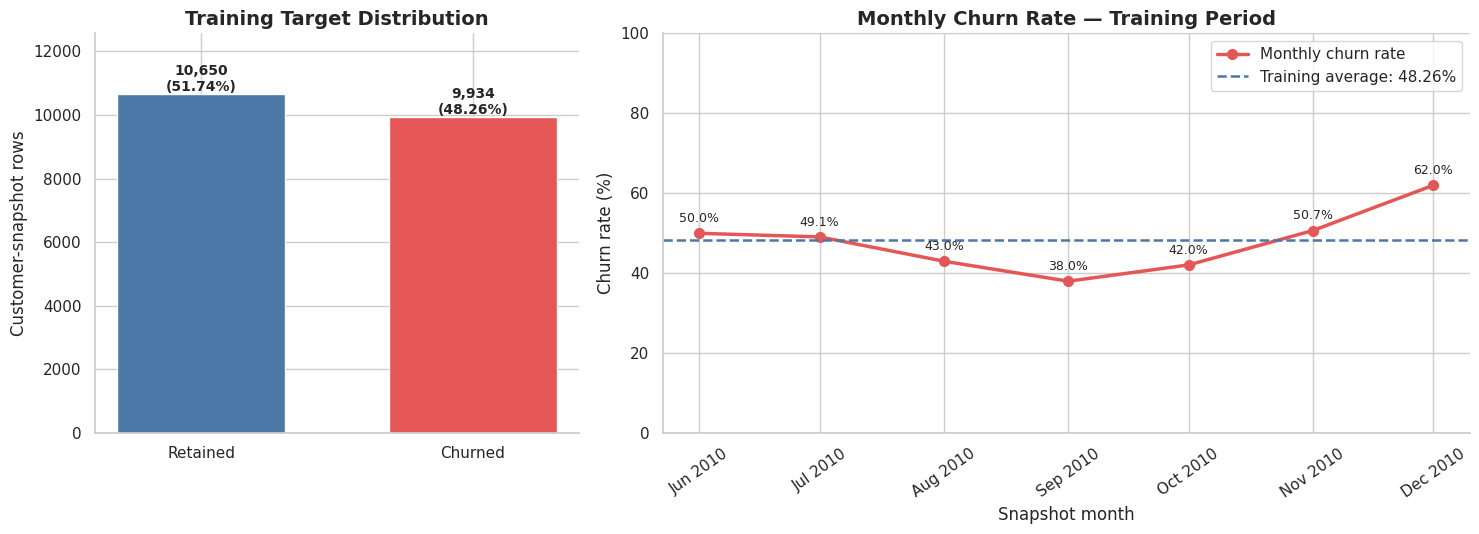

Training rows: 20,584
Training churn rate: 48.26%


,Customer Status,Customers,Percentage (%)
0,Retained,10650,51.74
1,Churned,9934,48.26


,snapshot_date,eligible_customers,retained_customers,churned_customers,churn_rate_percent
0,2010-06-01,2652,1327,1325,49.96
1,2010-07-01,2737,1394,1343,49.07
2,2010-08-01,2813,1604,1209,42.98
3,2010-09-01,2822,1750,1072,37.99
4,2010-10-01,2899,1680,1219,42.05
5,2010-11-01,3196,1577,1619,50.66
6,2010-12-01,3465,1318,2147,61.96


In [27]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

# Training target distribution
target_counts = (
    train_model_data["churn_90d"]
    .value_counts()
    .reindex([0, 1], fill_value=0)
)

training_target_summary = pd.DataFrame({
    "Customer Status": ["Retained", "Churned"],
    "Customers": target_counts.values
})

training_target_summary["Percentage (%)"] = (
    training_target_summary["Customers"]
    / training_target_summary["Customers"].sum()
    * 100
).round(2)

# Monthly churn within training data only
training_monthly_churn = (
    train_model_data
    .groupby("snapshot_date")
    .agg(
        eligible_customers=("snapshot_id", "size"),
        retained_customers=(
            "churn_90d",
            lambda values: (values == 0).sum()
        ),
        churned_customers=("churn_90d", "sum"),
        churn_rate=("churn_90d", "mean")
    )
    .reset_index()
)

training_monthly_churn["churn_rate_percent"] = (
    training_monthly_churn["churn_rate"] * 100
)

training_churn_rate = (
    train_model_data["churn_90d"].mean() * 100
)

# Create visualisations
fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5.5),
    gridspec_kw={"width_ratios": [0.9, 1.5]}
)

# Target distribution
bars = axes[0].bar(
    training_target_summary["Customer Status"],
    training_target_summary["Customers"],
    color=["#4C78A8", "#E45756"],
    width=0.62
)

axes[0].set_title(
    "Training Target Distribution",
    fontsize=14,
    fontweight="bold"
)
axes[0].set_xlabel("")
axes[0].set_ylabel("Customer-snapshot rows")
axes[0].tick_params(axis="x", labelsize=11)

for bar, count, percentage in zip(
    bars,
    training_target_summary["Customers"],
    training_target_summary["Percentage (%)"]
):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}\n({percentage:.2f}%)",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

axes[0].set_ylim(
    0,
    training_target_summary["Customers"].max() * 1.18
)

# Monthly churn trend
axes[1].plot(
    training_monthly_churn["snapshot_date"],
    training_monthly_churn["churn_rate_percent"],
    color="#E45756",
    marker="o",
    linewidth=2.5,
    markersize=7,
    label="Monthly churn rate"
)

axes[1].axhline(
    training_churn_rate,
    color="#4C78A8",
    linestyle="--",
    linewidth=1.8,
    label=f"Training average: {training_churn_rate:.2f}%"
)

for _, row in training_monthly_churn.iterrows():
    axes[1].annotate(
        f"{row['churn_rate_percent']:.1f}%",
        (
            row["snapshot_date"],
            row["churn_rate_percent"]
        ),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=9
    )

axes[1].set_title(
    "Monthly Churn Rate — Training Period",
    fontsize=14,
    fontweight="bold"
)
axes[1].set_xlabel("Snapshot month")
axes[1].set_ylabel("Churn rate (%)")
axes[1].set_ylim(0, 100)
axes[1].xaxis.set_major_formatter(
    mdates.DateFormatter("%b %Y")
)
axes[1].tick_params(
    axis="x",
    rotation=35
)
axes[1].legend(frameon=True)

sns.despine()
plt.tight_layout()
plt.show()

print(f"Training rows: {len(train_model_data):,}")
print(f"Training churn rate: {training_churn_rate:.2f}%")

display(training_target_summary)
display(
    training_monthly_churn[
        [
            "snapshot_date",
            "eligible_customers",
            "retained_customers",
            "churned_customers",
            "churn_rate_percent"
        ]
    ].round({"churn_rate_percent": 2})
)

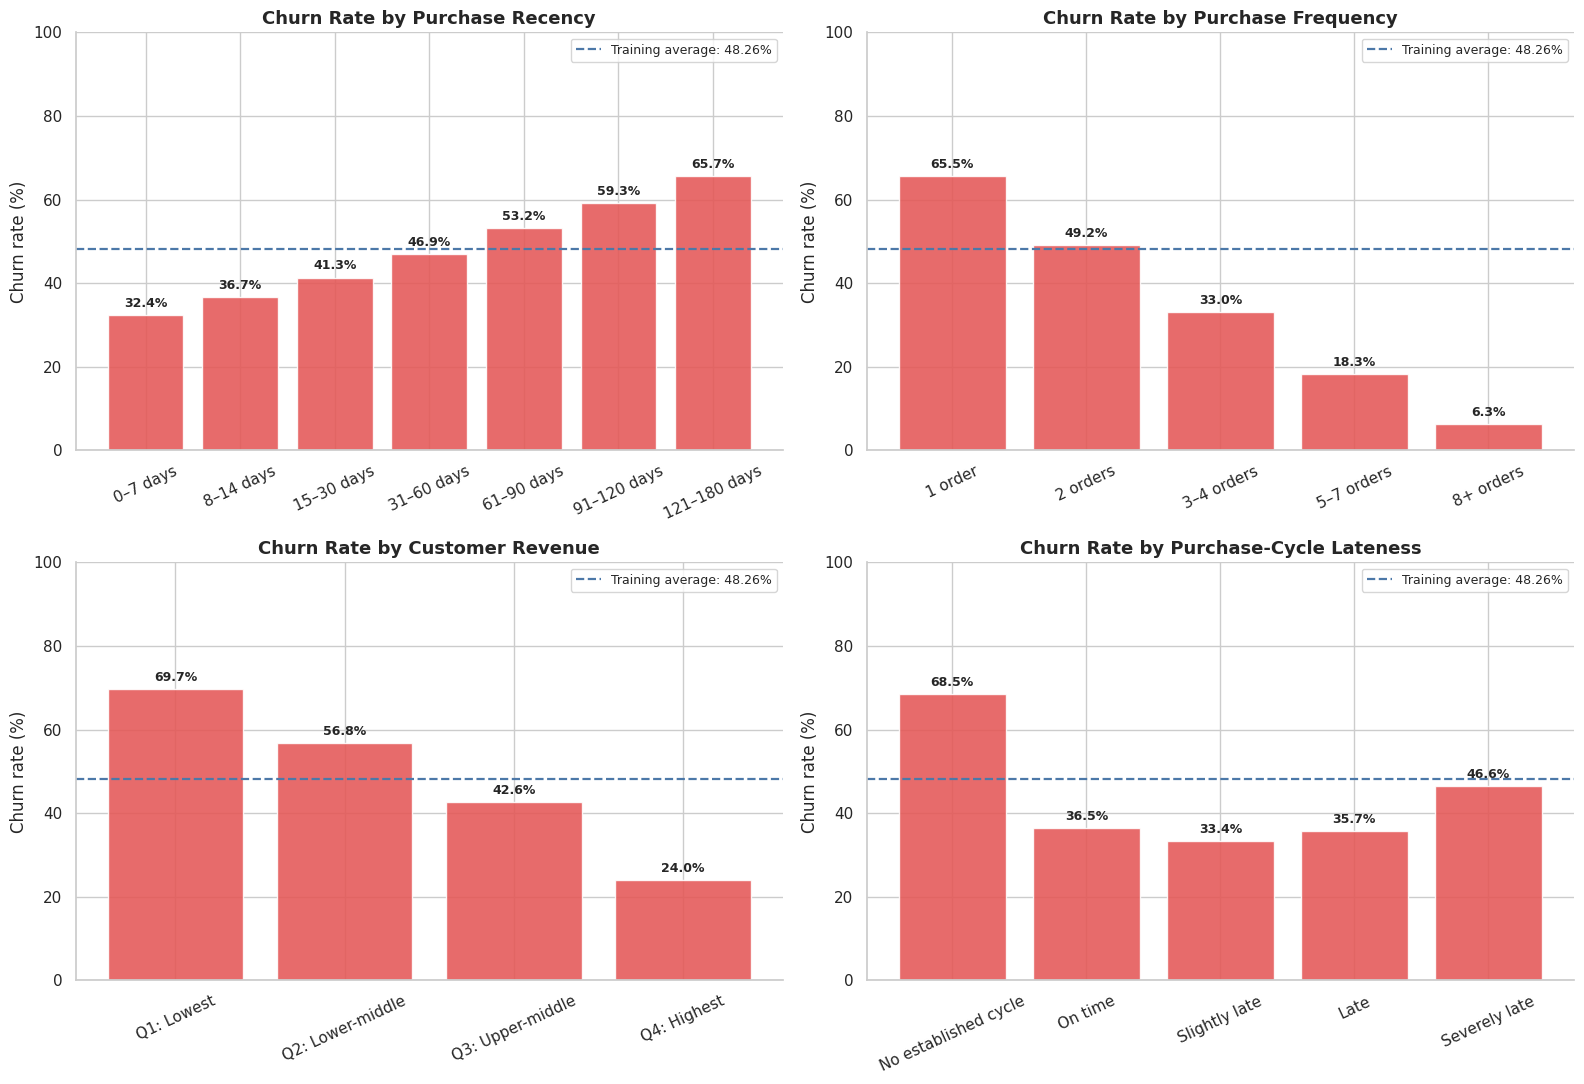

,Risk Dimension,Segment,customer_snapshots,churned_snapshots,churn_rate_percent
0,Recency,0–7 days,2369,767,32.38
1,Recency,8–14 days,2054,753,36.66
2,Recency,15–30 days,3539,1463,41.34
3,Recency,31–60 days,4443,2084,46.91
4,Recency,61–90 days,2930,1559,53.21
5,Recency,91–120 days,2167,1284,59.25
6,Recency,121–180 days,3082,2024,65.67
7,Purchase Frequency,1 order,9223,6044,65.53
8,Purchase Frequency,2 orders,4429,2179,49.20
9,Purchase Frequency,3–4 orders,3949,1305,33.05


In [28]:
# Create a training-only EDA copy
train_eda = train_model_data.copy()

# Business-friendly recency groups
train_eda["recency_segment"] = pd.cut(
    train_eda["recency_days"],
    bins=[-np.inf, 7, 14, 30, 60, 90, 120, np.inf],
    labels=[
        "0–7 days",
        "8–14 days",
        "15–30 days",
        "31–60 days",
        "61–90 days",
        "91–120 days",
        "121–180 days"
    ]
)

# Purchase-frequency groups
train_eda["frequency_segment"] = pd.cut(
    train_eda["orders_180d"],
    bins=[0, 1, 2, 4, 7, np.inf],
    labels=[
        "1 order",
        "2 orders",
        "3–4 orders",
        "5–7 orders",
        "8+ orders"
    ]
)

# Revenue quartiles based only on training data
revenue_percentile = (
    train_eda["revenue_180d"]
    .rank(method="average", pct=True)
)

train_eda["revenue_segment"] = pd.cut(
    revenue_percentile,
    bins=[0, 0.25, 0.50, 0.75, 1.00],
    labels=[
        "Q1: Lowest",
        "Q2: Lower-middle",
        "Q3: Upper-middle",
        "Q4: Highest"
    ],
    include_lowest=True
)

# Purchase-cycle lateness groups
lateness_conditions = [
    train_eda["lateness_ratio"].isna(),
    train_eda["lateness_ratio"] <= 1.0,
    train_eda["lateness_ratio"].between(
        1.0, 1.5, inclusive="right"
    ),
    train_eda["lateness_ratio"].between(
        1.5, 2.0, inclusive="right"
    ),
    train_eda["lateness_ratio"] > 2.0
]

lateness_labels = [
    "No established cycle",
    "On time",
    "Slightly late",
    "Late",
    "Severely late"
]

train_eda["lateness_segment"] = np.select(
    lateness_conditions,
    lateness_labels,
    default="No established cycle"
)

train_eda["lateness_segment"] = pd.Categorical(
    train_eda["lateness_segment"],
    categories=lateness_labels,
    ordered=True
)

# Reusable churn-profile function
def create_churn_profile(data, segment_column, dimension_name):
    profile = (
        data
        .groupby(segment_column, observed=False)
        .agg(
            customer_snapshots=("snapshot_id", "size"),
            churned_snapshots=("churn_90d", "sum"),
            churn_rate=("churn_90d", "mean")
        )
        .reset_index()
    )

    profile = profile[
        profile["customer_snapshots"] > 0
    ].copy()

    profile["churn_rate_percent"] = (
        profile["churn_rate"] * 100
    )

    profile.insert(0, "Risk Dimension", dimension_name)

    profile = profile.rename(
        columns={segment_column: "Segment"}
    )

    profile["Segment"] = profile["Segment"].astype(str)

    return profile


recency_profile = create_churn_profile(
    train_eda,
    "recency_segment",
    "Recency"
)

frequency_profile = create_churn_profile(
    train_eda,
    "frequency_segment",
    "Purchase Frequency"
)

revenue_profile = create_churn_profile(
    train_eda,
    "revenue_segment",
    "Customer Revenue"
)

lateness_profile = create_churn_profile(
    train_eda,
    "lateness_segment",
    "Purchase-Cycle Lateness"
)

risk_profiles = [
    (
        recency_profile,
        "Churn Rate by Purchase Recency"
    ),
    (
        frequency_profile,
        "Churn Rate by Purchase Frequency"
    ),
    (
        revenue_profile,
        "Churn Rate by Customer Revenue"
    ),
    (
        lateness_profile,
        "Churn Rate by Purchase-Cycle Lateness"
    )
]

# Plot the four churn-risk relationships
fig, axes = plt.subplots(
    2,
    2,
    figsize=(16, 11)
)

for axis, (profile, title) in zip(
    axes.flatten(),
    risk_profiles
):
    bars = axis.bar(
        profile["Segment"],
        profile["churn_rate_percent"],
        color="#E45756",
        alpha=0.88
    )

    axis.axhline(
        training_churn_rate,
        color="#4C78A8",
        linestyle="--",
        linewidth=1.6,
        label=f"Training average: {training_churn_rate:.2f}%"
    )

    for bar, rate in zip(
        bars,
        profile["churn_rate_percent"]
    ):
        axis.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1.2,
            f"{rate:.1f}%",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold"
        )

    axis.set_title(
        title,
        fontsize=13,
        fontweight="bold"
    )
    axis.set_xlabel("")
    axis.set_ylabel("Churn rate (%)")
    axis.set_ylim(0, 100)
    axis.tick_params(
        axis="x",
        rotation=25
    )
    axis.legend(fontsize=9)

sns.despine()
plt.tight_layout()
plt.show()

# Combined business-risk table
risk_profile_table = pd.concat(
    [
        recency_profile,
        frequency_profile,
        revenue_profile,
        lateness_profile
    ],
    ignore_index=True
)

risk_profile_table["churn_rate_percent"] = (
    risk_profile_table["churn_rate_percent"].round(2)
)

display(
    risk_profile_table[
        [
            "Risk Dimension",
            "Segment",
            "customer_snapshots",
            "churned_snapshots",
            "churn_rate_percent"
        ]
    ]
)

### Key EDA Findings

Churn is strongly associated with recency, purchase frequency and customer value. Customers with limited purchase history or no established buying cycle show the highest risk.

### Univariate Feature Screening

Numeric features are now ranked by their individual ability to distinguish churned from retained customers. This is descriptive screening, not final model importance.


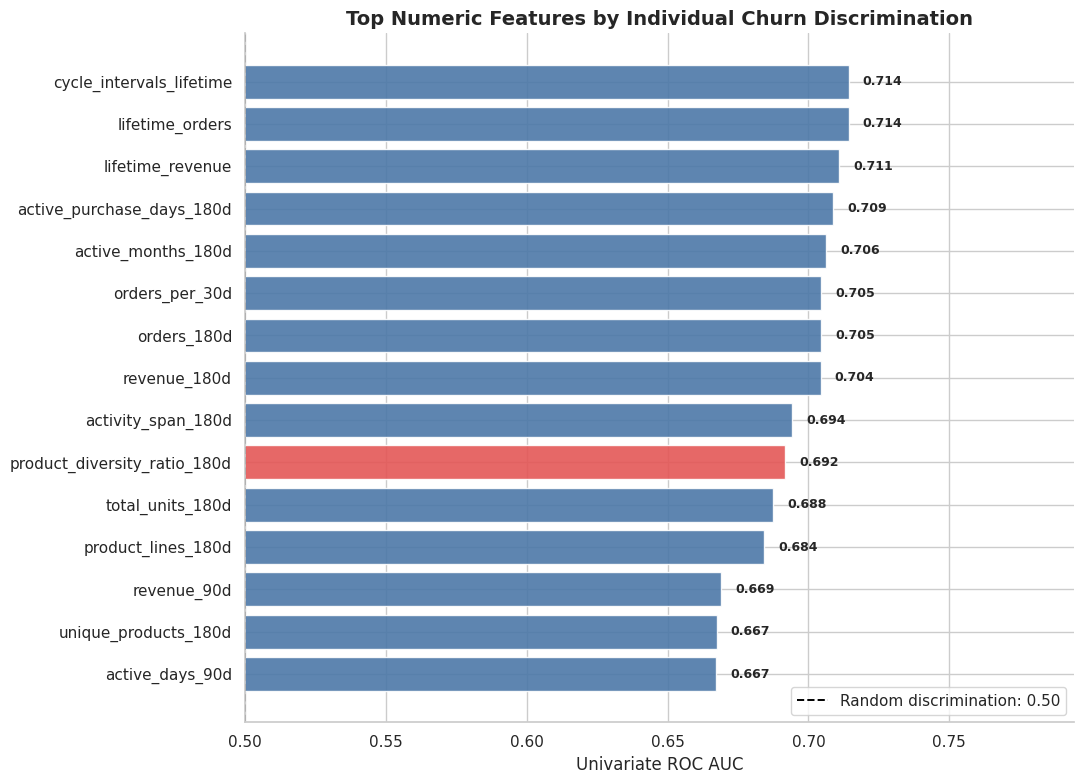

Red: higher values are associated with churn.
Blue: lower values are associated with churn.


,Feature,Univariate AUC,Raw AUC,Risk Direction,Spearman Correlation,Retained Median,Churned Median,Missing (%)
0,lifetime_orders,0.714,0.286,Lower values → churn,-0.380,3.00,2.00,0.0
1,cycle_intervals_lifetime,0.714,0.286,Lower values → churn,-0.380,2.00,1.00,0.0
2,lifetime_revenue,0.711,0.289,Lower values → churn,-0.365,1093.17,433.77,0.0
3,active_purchase_days_180d,0.709,0.291,Lower values → churn,-0.385,2.00,1.00,0.0
4,active_months_180d,0.706,0.294,Lower values → churn,-0.386,2.00,1.00,0.0
5,orders_180d,0.705,0.295,Lower values → churn,-0.374,2.00,1.00,0.0
6,orders_per_30d,0.705,0.295,Lower values → churn,-0.374,0.33,0.17,0.0
7,revenue_180d,0.704,0.296,Lower values → churn,-0.354,796.05,349.25,0.0
8,activity_span_180d,0.694,0.306,Lower values → churn,-0.353,71.06,0.00,0.0
9,product_diversity_ratio_180d,0.692,0.692,Higher values → churn,0.347,0.89,1.00,0.0


In [29]:
from sklearn.metrics import roc_auc_score

univariate_results = []

y_training = train_model_data[target_column]

for feature in numeric_feature_columns:
    feature_values = pd.to_numeric(
        train_model_data[feature],
        errors="coerce"
    )

    # Median filling is used only for this training-only EDA
    training_median = feature_values.median()
    filled_values = feature_values.fillna(training_median)

    if filled_values.nunique() <= 1:
        continue

    raw_auc = roc_auc_score(
        y_training,
        filled_values
    )

    discrimination_auc = max(
        raw_auc,
        1 - raw_auc
    )

    risk_direction = (
        "Higher values → churn"
        if raw_auc >= 0.50
        else "Lower values → churn"
    )

    retained_median = feature_values[
        y_training == 0
    ].median()

    churned_median = feature_values[
        y_training == 1
    ].median()

    spearman_correlation = filled_values.corr(
        y_training,
        method="spearman"
    )

    univariate_results.append({
        "Feature": feature,
        "Univariate AUC": discrimination_auc,
        "Raw AUC": raw_auc,
        "Risk Direction": risk_direction,
        "Spearman Correlation": spearman_correlation,
        "Retained Median": retained_median,
        "Churned Median": churned_median,
        "Missing (%)": feature_values.isna().mean() * 100
    })

feature_screening_table = (
    pd.DataFrame(univariate_results)
    .sort_values(
        "Univariate AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

# Select the strongest individual features
top_univariate_features = (
    feature_screening_table
    .head(15)
    .sort_values("Univariate AUC")
    .copy()
)

bar_colors = [
    "#E45756"
    if direction == "Higher values → churn"
    else "#4C78A8"
    for direction in top_univariate_features["Risk Direction"]
]

# Plot ranked univariate discrimination
fig, axis = plt.subplots(figsize=(11, 8))

bars = axis.barh(
    top_univariate_features["Feature"],
    top_univariate_features["Univariate AUC"],
    color=bar_colors,
    alpha=0.9
)

axis.axvline(
    0.50,
    color="black",
    linestyle="--",
    linewidth=1.4,
    label="Random discrimination: 0.50"
)

for bar, auc_value in zip(
    bars,
    top_univariate_features["Univariate AUC"]
):
    axis.text(
        auc_value + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{auc_value:.3f}",
        va="center",
        fontsize=9,
        fontweight="bold"
    )

axis.set_title(
    "Top Numeric Features by Individual Churn Discrimination",
    fontsize=14,
    fontweight="bold"
)
axis.set_xlabel("Univariate ROC AUC")
axis.set_ylabel("")
axis.set_xlim(
    0.50,
    min(
        1.00,
        top_univariate_features[
            "Univariate AUC"
        ].max() + 0.08
    )
)
axis.legend(loc="lower right")

sns.despine()
plt.tight_layout()
plt.show()

print(
    "Red: higher values are associated with churn.\n"
    "Blue: lower values are associated with churn."
)

display(
    feature_screening_table.head(20).round({
        "Univariate AUC": 3,
        "Raw AUC": 3,
        "Spearman Correlation": 3,
        "Retained Median": 2,
        "Churned Median": 2,
        "Missing (%)": 2
    })
)

### Feature Redundancy Check

Many high-ranked variables measure similar purchasing behaviour. Training-only Spearman correlation is used to identify near-duplicate features, retaining the stronger feature when absolute correlation reaches 0.95.


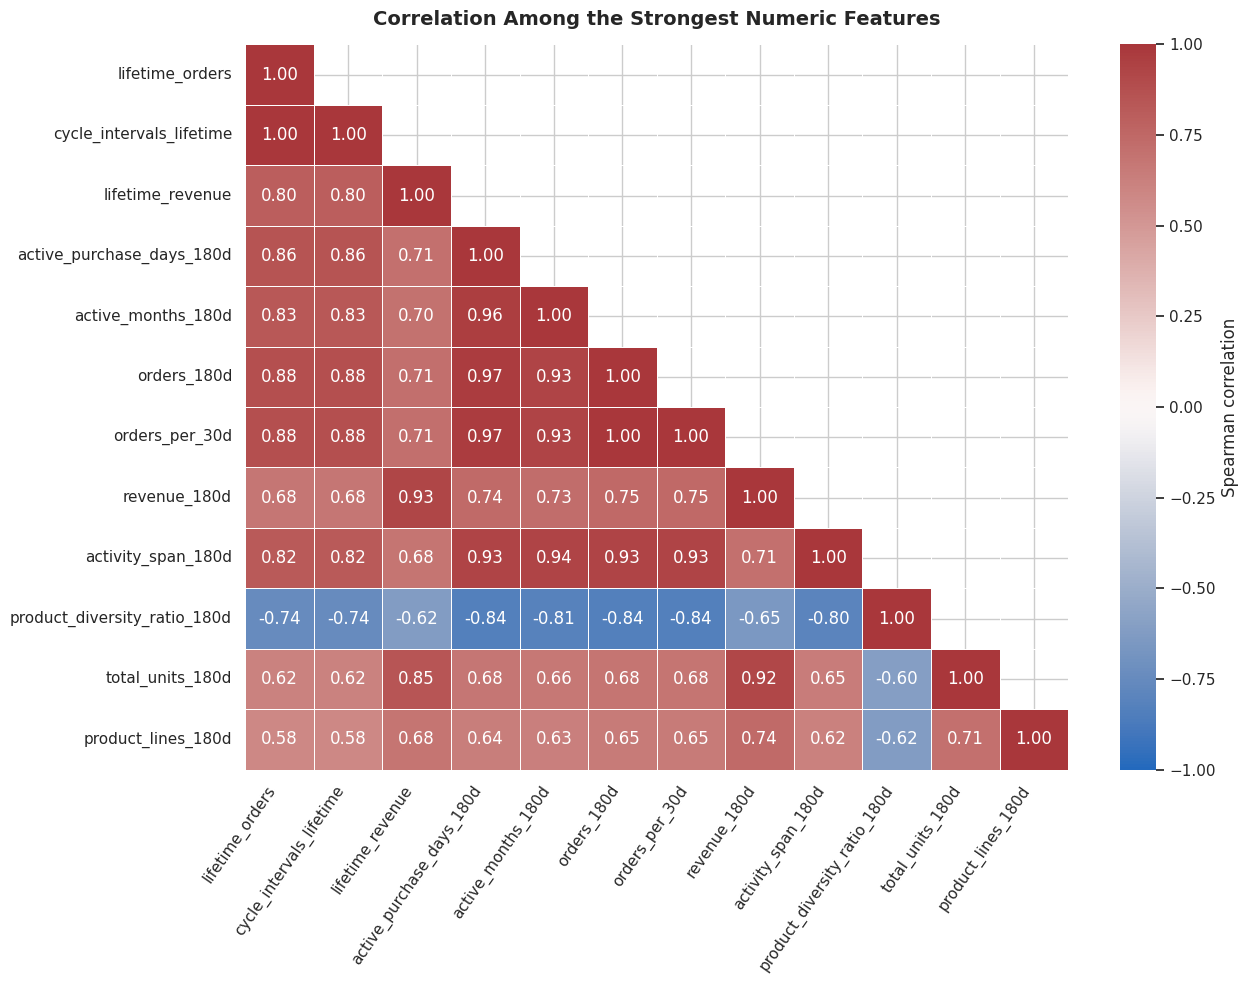

Original numeric features: 73
Highly correlated pairs (|ρ| ≥ 0.9): 90
Features removed at |ρ| ≥ 0.95: 27
Numeric features retained: 46
Total selected model features: 47

Strongest correlated feature pairs:


,Feature 1,Feature 2,Spearman Correlation,Absolute Correlation
0,orders_180d,orders_per_30d,1.000,1.000
1,lifetime_orders,cycle_intervals_lifetime,1.000,1.000
2,recency_days,recency_to_churn_horizon,1.000,1.000
3,orders_previous_30d,active_days_previous_30d,0.995,0.995
4,orders_30d,active_days_30d,0.993,0.993
5,recent_order_share_30d,recent_revenue_share_30d,0.993,0.993
6,revenue_previous_30d,units_previous_30d,0.991,0.991
7,cancelled_units_180d,cancelled_value_180d,0.990,0.990
8,revenue_30d,units_30d,0.989,0.989
9,cancellation_invoices_180d,cancellation_lines_180d,0.987,0.987



Correlation-pruning decisions:


,Dropped Feature,Retained Feature,Absolute Correlation,Dropped Feature AUC,Retained Feature AUC
0,cycle_intervals_lifetime,lifetime_orders,1.000,0.714,0.714
1,recency_days,recency_to_churn_horizon,1.000,0.625,0.625
2,recent_order_share_30d,recent_revenue_share_30d,0.993,0.550,0.553
3,units_previous_30d,revenue_previous_30d,0.991,0.600,0.603
4,units_30d,revenue_30d,0.989,0.599,0.601
5,cancellation_lines_180d,cancellation_invoices_180d,0.987,0.601,0.603
6,unique_products_180d,product_lines_180d,0.987,0.667,0.684
7,orders_60d,active_days_60d,0.985,0.636,0.636
8,revenue_momentum_log_30d,revenue_change_30d,0.984,0.500,0.502
9,had_cancellation_180d,cancellation_invoices_180d,0.980,0.593,0.603


In [31]:
CORRELATION_REPORT_THRESHOLD = 0.90
CORRELATION_PRUNING_THRESHOLD = 0.95

# Prepare numeric training features for correlation analysis
correlation_data = (
    train_model_data[numeric_feature_columns]
    .apply(pd.to_numeric, errors="coerce")
    .copy()
)

# Training-only median values
correlation_medians = correlation_data.median()

correlation_data = correlation_data.fillna(
    correlation_medians
)

# Spearman is more appropriate for skewed behavioural data
spearman_correlation_matrix = correlation_data.corr(
    method="spearman"
)

# Extract unique feature pairs
upper_triangle_mask = np.triu(
    np.ones(
        spearman_correlation_matrix.shape,
        dtype=bool
    ),
    k=1
)

upper_correlation_matrix = (
    spearman_correlation_matrix
    .where(upper_triangle_mask)
)

correlation_pairs = (
    upper_correlation_matrix
    .stack()
    .reset_index()
)

correlation_pairs.columns = [
    "Feature 1",
    "Feature 2",
    "Spearman Correlation"
]

correlation_pairs["Absolute Correlation"] = (
    correlation_pairs[
        "Spearman Correlation"
    ].abs()
)

high_correlation_pairs = (
    correlation_pairs[
        correlation_pairs["Absolute Correlation"]
        >= CORRELATION_REPORT_THRESHOLD
    ]
    .sort_values(
        "Absolute Correlation",
        ascending=False
    )
    .reset_index(drop=True)
)

# Rank features using the previous training-only AUC results
auc_lookup = (
    feature_screening_table
    .set_index("Feature")["Univariate AUC"]
    .to_dict()
)

ordered_numeric_features = (
    feature_screening_table["Feature"].tolist()
)

selected_numeric_feature_columns = []
redundancy_records = []

for feature in ordered_numeric_features:

    if not selected_numeric_feature_columns:
        selected_numeric_feature_columns.append(feature)
        continue

    correlations_with_selected = (
        spearman_correlation_matrix
        .loc[
            feature,
            selected_numeric_feature_columns
        ]
        .abs()
    )

    strongest_related_feature = (
        correlations_with_selected.idxmax()
    )

    strongest_correlation = (
        correlations_with_selected.max()
    )

    if (
        strongest_correlation
        >= CORRELATION_PRUNING_THRESHOLD
    ):
        redundancy_records.append({
            "Dropped Feature": feature,
            "Retained Feature": strongest_related_feature,
            "Absolute Correlation": strongest_correlation,
            "Dropped Feature AUC": auc_lookup.get(
                feature,
                np.nan
            ),
            "Retained Feature AUC": auc_lookup.get(
                strongest_related_feature,
                np.nan
            )
        })
    else:
        selected_numeric_feature_columns.append(feature)

redundancy_log = (
    pd.DataFrame(redundancy_records)
    .sort_values(
        "Absolute Correlation",
        ascending=False
    )
    .reset_index(drop=True)
)

# Final feature list for model pipelines
selected_model_feature_columns = (
    selected_numeric_feature_columns
    + categorical_feature_columns
)

# Correlation heatmap for strongest features
heatmap_features = (
    feature_screening_table
    .head(12)["Feature"]
    .tolist()
)

heatmap_correlation = (
    spearman_correlation_matrix
    .loc[heatmap_features, heatmap_features]
)

heatmap_mask = np.triu(
    np.ones_like(
        heatmap_correlation,
        dtype=bool
    ),
    k=1
)

plt.figure(figsize=(13, 10))

sns.heatmap(
    heatmap_correlation,
    mask=heatmap_mask,
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={
        "label": "Spearman correlation"
    }
)

plt.title(
    "Correlation Among the Strongest Numeric Features",
    fontsize=14,
    fontweight="bold",
    pad=14
)
plt.xticks(rotation=55, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print(f"Original numeric features: {len(numeric_feature_columns)}")
print(
    "Highly correlated pairs "
    f"(|ρ| ≥ {CORRELATION_REPORT_THRESHOLD}): "
    f"{len(high_correlation_pairs)}"
)
print(
    "Features removed at "
    f"|ρ| ≥ {CORRELATION_PRUNING_THRESHOLD}: "
    f"{len(redundancy_log)}"
)
print(
    "Numeric features retained: "
    f"{len(selected_numeric_feature_columns)}"
)
print(
    "Total selected model features: "
    f"{len(selected_model_feature_columns)}"
)

print("\nStrongest correlated feature pairs:")
display(
    high_correlation_pairs.head(25).round({
        "Spearman Correlation": 3,
        "Absolute Correlation": 3
    })
)

print("\nCorrelation-pruning decisions:")
display(
    redundancy_log.head(25).round({
        "Absolute Correlation": 3,
        "Dropped Feature AUC": 3,
        "Retained Feature AUC": 3
    })
)

In [32]:
# Apply domain-informed feature preferences
feature_preference_rules = [
    {
        "Current Feature": "recency_to_churn_horizon",
        "Preferred Feature": "recency_days",
        "Reason": "Direct recency is easier to interpret"
    },
    {
        "Current Feature": "revenue_change_30d",
        "Preferred Feature": "revenue_momentum_log_30d",
        "Reason": "Log momentum is more robust to revenue outliers"
    }
]

preference_changes = []

for rule in feature_preference_rules:
    current_feature = rule["Current Feature"]
    preferred_feature = rule["Preferred Feature"]

    if (
        current_feature
        in selected_numeric_feature_columns
        and preferred_feature
        not in selected_numeric_feature_columns
    ):
        feature_position = (
            selected_numeric_feature_columns.index(
                current_feature
            )
        )

        selected_numeric_feature_columns[
            feature_position
        ] = preferred_feature

        preference_changes.append(rule)

# Rebuild final model feature list
selected_model_feature_columns = (
    selected_numeric_feature_columns
    + categorical_feature_columns
)

# Recheck correlation after the preference changes
selected_correlation_matrix = (
    spearman_correlation_matrix.loc[
        selected_numeric_feature_columns,
        selected_numeric_feature_columns
    ]
)

selected_upper_mask = np.triu(
    np.ones(
        selected_correlation_matrix.shape,
        dtype=bool
    ),
    k=1
)

remaining_high_correlations = (
    selected_correlation_matrix
    .where(selected_upper_mask)
    .stack()
    .reset_index()
)

remaining_high_correlations.columns = [
    "Feature 1",
    "Feature 2",
    "Spearman Correlation"
]

remaining_high_correlations[
    "Absolute Correlation"
] = remaining_high_correlations[
    "Spearman Correlation"
].abs()

remaining_high_correlations = (
    remaining_high_correlations[
        remaining_high_correlations[
            "Absolute Correlation"
        ] >= CORRELATION_PRUNING_THRESHOLD
    ]
    .sort_values(
        "Absolute Correlation",
        ascending=False
    )
    .reset_index(drop=True)
)

feature_selection_validation = pd.DataFrame({
    "Validation Check": [
        "Duplicate selected features",
        "Missing selected features",
        "Remaining correlations at or above 0.95"
    ],
    "Issues Found": [
        len(selected_model_feature_columns)
        - len(set(selected_model_feature_columns)),

        sum(
            feature not in model_data.columns
            for feature in selected_model_feature_columns
        ),

        len(remaining_high_correlations)
    ]
})

feature_selection_validation["Expected"] = 0
feature_selection_validation["Status"] = np.where(
    feature_selection_validation["Issues Found"] == 0,
    "PASS",
    "CHECK"
)

print("Domain-informed feature refinement completed.")
print(
    f"Final numeric features: "
    f"{len(selected_numeric_feature_columns)}"
)
print(
    f"Final categorical features: "
    f"{len(categorical_feature_columns)}"
)
print(
    f"Final total model features: "
    f"{len(selected_model_feature_columns)}"
)

print("\nPreference changes:")
display(pd.DataFrame(preference_changes))

display(feature_selection_validation)

if len(remaining_high_correlations) > 0:
    display(remaining_high_correlations)

Domain-informed feature refinement completed.
Final numeric features: 46
Final categorical features: 1
Final total model features: 47

Preference changes:


,Current Feature,Preferred Feature,Reason
0,recency_to_churn_horizon,recency_days,Direct recency is easier to interpret
1,revenue_change_30d,revenue_momentum_log_30d,Log momentum is more robust to revenue outliers


,Validation Check,Issues Found,Expected,Status
0,Duplicate selected features,0,0,PASS
1,Missing selected features,0,0,PASS
2,Remaining correlations at or above 0.95,0,0,PASS


## 13. Temporal Feature Stability

Population Stability Index compares training and validation feature distributions. PSI below 0.10 indicates stability, 0.10–0.25 indicates moderate drift and above 0.25 indicates high drift. The test set remains untouched.


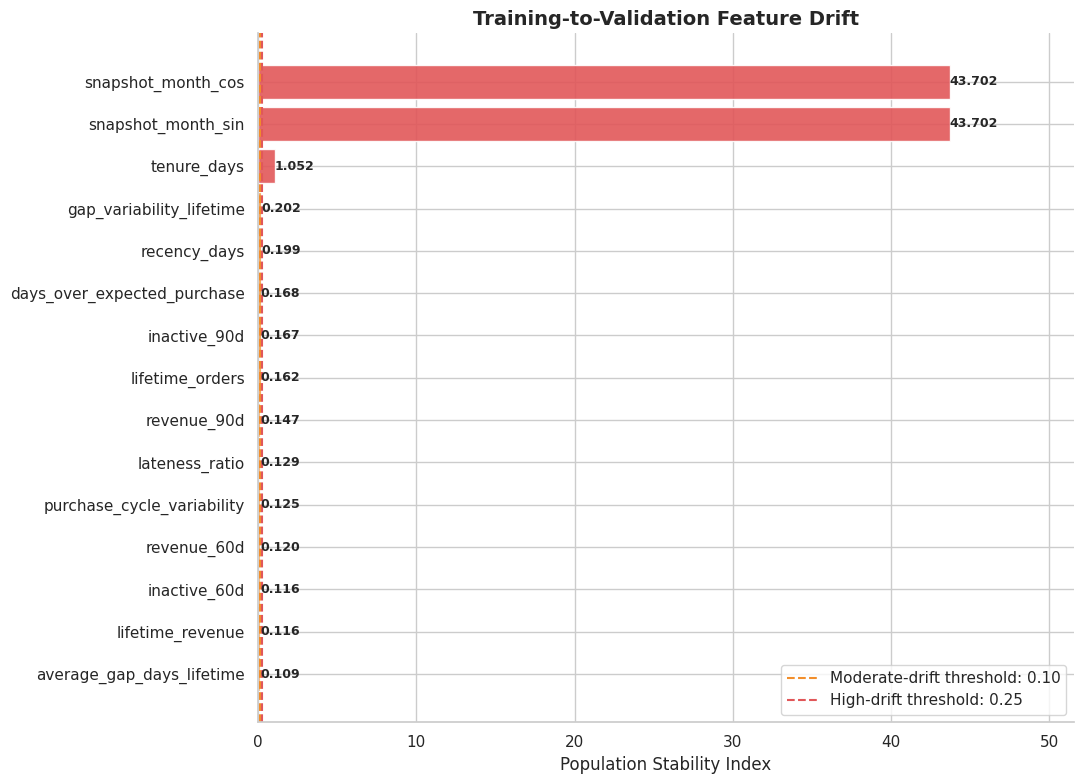

Validation feature-drift audit completed.
The test dataset was not used.


,Drift Level,Features
0,Stable,32
1,Moderate drift,12
2,High drift,3



Features with the greatest validation drift:


,Feature,Feature Type,Validation PSI,Drift Level
0,snapshot_month_sin,Numeric,43.702,High drift
1,snapshot_month_cos,Numeric,43.702,High drift
2,tenure_days,Numeric,1.052,High drift
3,gap_variability_lifetime,Numeric,0.202,Moderate drift
4,recency_days,Numeric,0.199,Moderate drift
5,days_over_expected_purchase,Numeric,0.168,Moderate drift
6,inactive_90d,Numeric,0.167,Moderate drift
7,lifetime_orders,Numeric,0.162,Moderate drift
8,revenue_90d,Numeric,0.147,Moderate drift
9,lateness_ratio,Numeric,0.129,Moderate drift


,Validation Check,Issues Found,Expected,Status
0,Selected features assessed,0,0,PASS
1,Missing drift results,0,0,PASS
2,Non-finite PSI values,0,0,PASS


In [33]:
PSI_EPSILON = 1e-6
PSI_BINS = 10


def calculate_label_psi(reference_labels, comparison_labels):
    reference_labels = (
        pd.Series(reference_labels)
        .astype("object")
        .where(
            pd.Series(reference_labels).notna(),
            "__MISSING__"
        )
        .astype(str)
    )

    comparison_labels = (
        pd.Series(comparison_labels)
        .astype("object")
        .where(
            pd.Series(comparison_labels).notna(),
            "__MISSING__"
        )
        .astype(str)
    )

    categories = sorted(
        set(reference_labels.unique())
        | set(comparison_labels.unique())
    )

    reference_counts = (
        reference_labels
        .value_counts()
        .reindex(categories, fill_value=0)
        .astype(float)
    )

    comparison_counts = (
        comparison_labels
        .value_counts()
        .reindex(categories, fill_value=0)
        .astype(float)
    )

    reference_proportions = (
        reference_counts + PSI_EPSILON
    ) / (
        reference_counts.sum()
        + PSI_EPSILON * len(categories)
    )

    comparison_proportions = (
        comparison_counts + PSI_EPSILON
    ) / (
        comparison_counts.sum()
        + PSI_EPSILON * len(categories)
    )

    psi_value = (
        (
            comparison_proportions
            - reference_proportions
        )
        * np.log(
            comparison_proportions
            / reference_proportions
        )
    ).sum()

    return float(psi_value)


def calculate_numeric_psi(
    reference_series,
    comparison_series,
    number_of_bins=10
):
    reference_numeric = pd.to_numeric(
        reference_series,
        errors="coerce"
    )

    comparison_numeric = pd.to_numeric(
        comparison_series,
        errors="coerce"
    )

    # Treat low-cardinality numeric features as categories
    if reference_numeric.nunique(dropna=True) <= 10:
        return calculate_label_psi(
            reference_numeric,
            comparison_numeric
        )

    reference_nonmissing = reference_numeric.dropna()

    quantile_edges = np.unique(
        reference_nonmissing.quantile(
            np.linspace(
                0,
                1,
                number_of_bins + 1
            )
        ).to_numpy()
    )

    if len(quantile_edges) < 2:
        return calculate_label_psi(
            reference_numeric,
            comparison_numeric
        )

    quantile_edges[0] = -np.inf
    quantile_edges[-1] = np.inf

    reference_bins = pd.cut(
        reference_numeric,
        bins=quantile_edges,
        include_lowest=True,
        duplicates="drop"
    )

    comparison_bins = pd.cut(
        comparison_numeric,
        bins=quantile_edges,
        include_lowest=True,
        duplicates="drop"
    )

    return calculate_label_psi(
        reference_bins,
        comparison_bins
    )


def assign_drift_level(psi_value):
    if psi_value < 0.10:
        return "Stable"
    elif psi_value < 0.25:
        return "Moderate drift"
    else:
        return "High drift"


# Calculate validation drift for selected numeric features
validation_drift_records = []

for feature in selected_numeric_feature_columns:
    psi_value = calculate_numeric_psi(
        train_model_data[feature],
        validation_model_data[feature],
        number_of_bins=PSI_BINS
    )

    validation_drift_records.append({
        "Feature": feature,
        "Feature Type": "Numeric",
        "Validation PSI": psi_value,
        "Drift Level": assign_drift_level(
            psi_value
        )
    })

# Calculate categorical drift
for feature in categorical_feature_columns:
    psi_value = calculate_label_psi(
        train_model_data[feature],
        validation_model_data[feature]
    )

    validation_drift_records.append({
        "Feature": feature,
        "Feature Type": "Categorical",
        "Validation PSI": psi_value,
        "Drift Level": assign_drift_level(
            psi_value
        )
    })

validation_drift_summary = (
    pd.DataFrame(validation_drift_records)
    .sort_values(
        "Validation PSI",
        ascending=False
    )
    .reset_index(drop=True)
)

# Drift-level counts
drift_level_counts = (
    validation_drift_summary["Drift Level"]
    .value_counts()
    .reindex(
        [
            "Stable",
            "Moderate drift",
            "High drift"
        ],
        fill_value=0
    )
    .rename_axis("Drift Level")
    .reset_index(name="Features")
)

# Plot the features with the greatest drift
top_drift_features = (
    validation_drift_summary
    .head(15)
    .sort_values("Validation PSI")
    .copy()
)

drift_colors = {
    "Stable": "#59A14F",
    "Moderate drift": "#F28E2B",
    "High drift": "#E15759"
}

bar_colors = [
    drift_colors[level]
    for level in top_drift_features["Drift Level"]
]

fig, axis = plt.subplots(figsize=(11, 8))

bars = axis.barh(
    top_drift_features["Feature"],
    top_drift_features["Validation PSI"],
    color=bar_colors,
    alpha=0.9
)

axis.axvline(
    0.10,
    color="#F28E2B",
    linestyle="--",
    linewidth=1.5,
    label="Moderate-drift threshold: 0.10"
)

axis.axvline(
    0.25,
    color="#E15759",
    linestyle="--",
    linewidth=1.5,
    label="High-drift threshold: 0.25"
)

for bar, psi_value in zip(
    bars,
    top_drift_features["Validation PSI"]
):
    axis.text(
        psi_value + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{psi_value:.3f}",
        va="center",
        fontsize=9,
        fontweight="bold"
    )

axis.set_title(
    "Training-to-Validation Feature Drift",
    fontsize=14,
    fontweight="bold"
)
axis.set_xlabel("Population Stability Index")
axis.set_ylabel("")
axis.set_xlim(
    0,
    max(
        0.30,
        top_drift_features[
            "Validation PSI"
        ].max() * 1.18
    )
)
axis.legend(loc="lower right")

sns.despine()
plt.tight_layout()
plt.show()

# Validation checks for the drift calculation
drift_validation = pd.DataFrame({
    "Validation Check": [
        "Selected features assessed",
        "Missing drift results",
        "Non-finite PSI values"
    ],
    "Issues Found": [
        len(selected_model_feature_columns)
        - len(validation_drift_summary),

        validation_drift_summary[
            "Validation PSI"
        ].isna().sum(),

        int(
            (~np.isfinite(
                validation_drift_summary[
                    "Validation PSI"
                ]
            )).sum()
        )
    ]
})

drift_validation["Expected"] = 0
drift_validation["Status"] = np.where(
    drift_validation["Issues Found"] == 0,
    "PASS",
    "CHECK"
)

print("Validation feature-drift audit completed.")
print("The test dataset was not used.")

display(drift_level_counts)

print("\nFeatures with the greatest validation drift:")
display(
    validation_drift_summary.head(20).round({
        "Validation PSI": 3
    })
)

display(drift_validation)

### Drift Interpretation

The extreme calendar-feature PSI is expected because training and validation represent different months. Calendar features and high-drift tenure are retained initially, but a drift-robust feature set will also be evaluated during model selection.


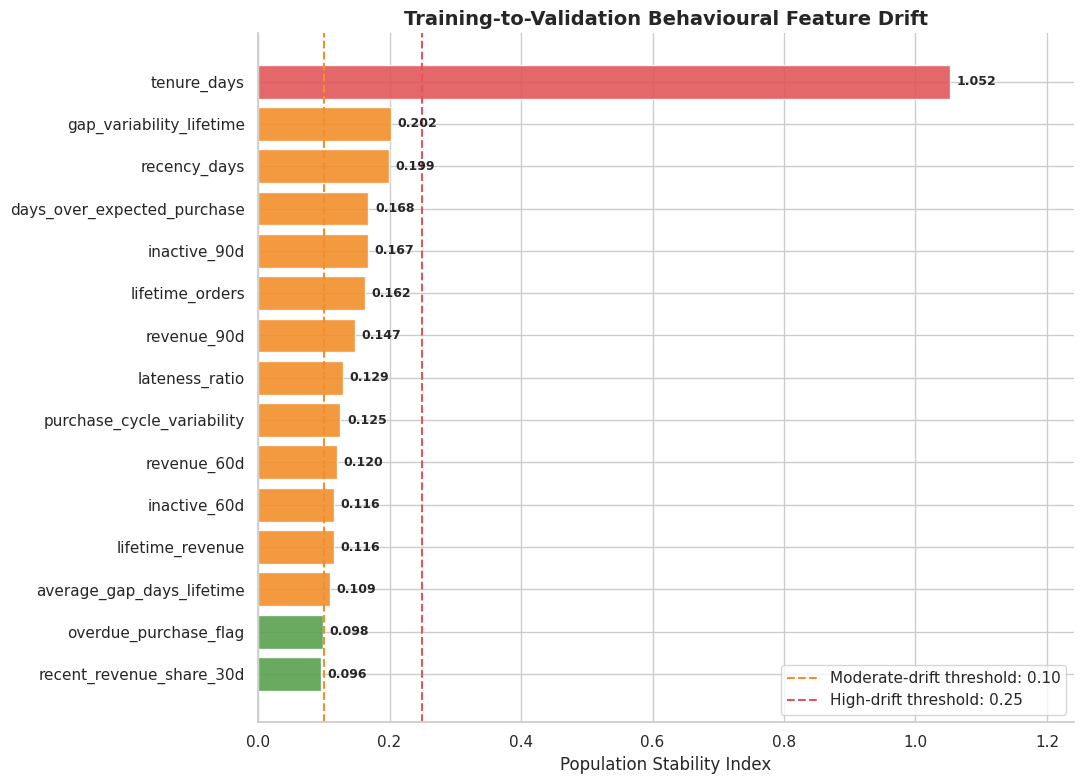

Structural calendar features:


,Feature,Validation PSI,Drift Level,Interpretation
0,snapshot_month_sin,43.702,High drift,Expected calendar-period shift
1,snapshot_month_cos,43.702,High drift,Expected calendar-period shift



Behavioural drift summary:


,Drift Level,Features
0,Stable,32
1,Moderate drift,12
2,High drift,1



High behavioural-drift features: ['tenure_days']
Features reserved for ablation: ['snapshot_month_sin', 'snapshot_month_cos', 'tenure_days']
Full candidate feature count: 47
Drift-robust candidate feature count: 44

No feature has been removed permanently; both feature sets will be compared on validation data.


In [34]:
# Separate deterministic calendar shift from behavioural drift
structural_time_features = [
    feature for feature in [
        "snapshot_month_sin",
        "snapshot_month_cos"
    ]
    if feature in selected_model_feature_columns
]

structural_time_drift = (
    validation_drift_summary[
        validation_drift_summary["Feature"].isin(
            structural_time_features
        )
    ]
    .copy()
)

behavioural_drift_summary = (
    validation_drift_summary[
        ~validation_drift_summary["Feature"].isin(
            structural_time_features
        )
    ]
    .copy()
    .reset_index(drop=True)
)

behavioural_drift_counts = (
    behavioural_drift_summary["Drift Level"]
    .value_counts()
    .reindex(
        [
            "Stable",
            "Moderate drift",
            "High drift"
        ],
        fill_value=0
    )
    .rename_axis("Drift Level")
    .reset_index(name="Features")
)

# Identify features for later validation ablation
high_behavioural_drift_features = (
    behavioural_drift_summary.loc[
        behavioural_drift_summary[
            "Validation PSI"
        ] >= 0.25,
        "Feature"
    ]
    .tolist()
)

drift_ablation_features = list(
    dict.fromkeys(
        structural_time_features
        + high_behavioural_drift_features
    )
)

drift_robust_model_feature_columns = [
    feature
    for feature in selected_model_feature_columns
    if feature not in drift_ablation_features
]

# Create a readable behavioural-drift chart
top_behavioural_drift = (
    behavioural_drift_summary
    .head(15)
    .sort_values("Validation PSI")
    .copy()
)

behavioural_bar_colors = [
    drift_colors[level]
    for level in top_behavioural_drift["Drift Level"]
]

fig, axis = plt.subplots(figsize=(11, 8))

bars = axis.barh(
    top_behavioural_drift["Feature"],
    top_behavioural_drift["Validation PSI"],
    color=behavioural_bar_colors,
    alpha=0.9
)

axis.axvline(
    0.10,
    color="#F28E2B",
    linestyle="--",
    linewidth=1.5,
    label="Moderate-drift threshold: 0.10"
)

axis.axvline(
    0.25,
    color="#E15759",
    linestyle="--",
    linewidth=1.5,
    label="High-drift threshold: 0.25"
)

for bar, psi_value in zip(
    bars,
    top_behavioural_drift["Validation PSI"]
):
    axis.text(
        psi_value + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{psi_value:.3f}",
        va="center",
        fontsize=9,
        fontweight="bold"
    )

axis.set_title(
    "Training-to-Validation Behavioural Feature Drift",
    fontsize=14,
    fontweight="bold"
)
axis.set_xlabel("Population Stability Index")
axis.set_ylabel("")
axis.set_xlim(
    0,
    max(
        0.30,
        top_behavioural_drift[
            "Validation PSI"
        ].max() * 1.18
    )
)
axis.legend(loc="lower right")

sns.despine()
plt.tight_layout()
plt.show()

# Add explanations to structural shift table
structural_time_drift = (
    structural_time_drift[
        [
            "Feature",
            "Validation PSI",
            "Drift Level"
        ]
    ]
    .copy()
)

structural_time_drift["Interpretation"] = (
    "Expected calendar-period shift"
)

print("Structural calendar features:")
display(
    structural_time_drift.round({
        "Validation PSI": 3
    })
)

print("\nBehavioural drift summary:")
display(behavioural_drift_counts)

print(
    "\nHigh behavioural-drift features:",
    high_behavioural_drift_features
)

print(
    "Features reserved for ablation:",
    drift_ablation_features
)

print(
    "Full candidate feature count:",
    len(selected_model_feature_columns)
)

print(
    "Drift-robust candidate feature count:",
    len(drift_robust_model_feature_columns)
)

print(
    "\nNo feature has been removed permanently; "
    "both feature sets will be compared on validation data."
)

## 14. Model Development

Models are trained on the chronological training period and selected using validation data. Performance is assessed using ROC-AUC, PR-AUC, F1, calibration and top-20% customer lift. The test set remains sealed until the final model is selected.


In [35]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)

RANDOM_STATE = 42
TOP_CUSTOMER_FRACTION = 0.20

# Register both candidate feature sets
feature_set_registry = {
    "Full Feature Set":
        selected_model_feature_columns.copy(),

    "Drift-Robust Feature Set":
        drift_robust_model_feature_columns.copy()
}

# Prepare targets
y_train = (
    train_model_data[target_column]
    .astype(int)
    .copy()
)

y_validation = (
    validation_model_data[target_column]
    .astype(int)
    .copy()
)

# Prepare feature matrices without accessing the test set
X_train_registry = {
    feature_set_name:
        train_model_data[feature_columns].copy()

    for feature_set_name, feature_columns
    in feature_set_registry.items()
}

X_validation_registry = {
    feature_set_name:
        validation_model_data[feature_columns].copy()

    for feature_set_name, feature_columns
    in feature_set_registry.items()
}


def create_one_hot_encoder():
    """
    Create a version-compatible encoder that groups
    infrequent countries where supported.
    """
    try:
        return OneHotEncoder(
            handle_unknown="infrequent_if_exist",
            min_frequency=20,
            sparse_output=False
        )
    except TypeError:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse=False
        )


def build_preprocessor(
    feature_columns,
    scale_numeric=True
):
    numeric_columns = [
        feature
        for feature in selected_numeric_feature_columns
        if feature in feature_columns
    ]

    categorical_columns = [
        feature
        for feature in categorical_feature_columns
        if feature in feature_columns
    ]

    numeric_steps = [
        (
            "median_imputer",
            SimpleImputer(
                strategy="median",
                add_indicator=True
            )
        )
    ]

    if scale_numeric:
        numeric_steps.append(
            (
                "robust_scaler",
                RobustScaler()
            )
        )

    numeric_pipeline = Pipeline(
        steps=numeric_steps
    )

    categorical_pipeline = Pipeline(
        steps=[
            (
                "category_imputer",
                SimpleImputer(
                    strategy="most_frequent"
                )
            ),
            (
                "one_hot_encoder",
                create_one_hot_encoder()
            )
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "numeric",
                numeric_pipeline,
                numeric_columns
            ),
            (
                "categorical",
                categorical_pipeline,
                categorical_columns
            )
        ],
        remainder="drop",
        verbose_feature_names_out=False
    )

    return (
        preprocessor,
        numeric_columns,
        categorical_columns
    )


def evaluate_classifier(
    estimator,
    X,
    y,
    model_name,
    feature_set_name,
    dataset_name="Validation",
    threshold=0.50,
    top_fraction=0.20
):
    probabilities = estimator.predict_proba(X)[:, 1]

    predictions = (
        probabilities >= threshold
    ).astype(int)

    y_array = np.asarray(y)

    top_customer_count = max(
        1,
        int(np.ceil(len(y_array) * top_fraction))
    )

    top_customer_indices = (
        np.argsort(probabilities)[::-1]
        [:top_customer_count]
    )

    overall_churn_rate = y_array.mean()

    top_customer_churn_rate = (
        y_array[top_customer_indices].mean()
    )

    recall_at_top_fraction = (
        y_array[top_customer_indices].sum()
        / max(y_array.sum(), 1)
    )

    lift_at_top_fraction = (
        top_customer_churn_rate
        / overall_churn_rate
        if overall_churn_rate > 0
        else np.nan
    )

    metrics_row = {
        "Model": model_name,
        "Feature Set": feature_set_name,
        "Dataset": dataset_name,
        "Threshold": threshold,
        "ROC-AUC": roc_auc_score(
            y_array,
            probabilities
        ),
        "PR-AUC": average_precision_score(
            y_array,
            probabilities
        ),
        "Accuracy": accuracy_score(
            y_array,
            predictions
        ),
        "Balanced Accuracy":
            balanced_accuracy_score(
                y_array,
                predictions
            ),
        "Precision": precision_score(
            y_array,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_array,
            predictions,
            zero_division=0
        ),
        "F1": f1_score(
            y_array,
            predictions,
            zero_division=0
        ),
        "Brier Score": brier_score_loss(
            y_array,
            probabilities
        ),
        "Recall @ Top 20%":
            recall_at_top_fraction,
        "Lift @ Top 20%":
            lift_at_top_fraction
    }

    return metrics_row, probabilities


# Reusable result stores
model_results = []
trained_models = {}
validation_probability_store = {}

# Modelling setup summary
setup_records = []

for feature_set_name, feature_columns in (
    feature_set_registry.items()
):
    numeric_count = sum(
        feature in selected_numeric_feature_columns
        for feature in feature_columns
    )

    categorical_count = sum(
        feature in categorical_feature_columns
        for feature in feature_columns
    )

    setup_records.append({
        "Feature Set": feature_set_name,
        "Numeric Features": numeric_count,
        "Categorical Features": categorical_count,
        "Total Features": len(feature_columns),
        "Training Rows": len(y_train),
        "Validation Rows": len(y_validation),
        "Training Churn (%)":
            y_train.mean() * 100,
        "Validation Churn (%)":
            y_validation.mean() * 100
    })

modelling_setup_summary = pd.DataFrame(
    setup_records
)

# Readiness checks
modelling_readiness = pd.DataFrame({
    "Validation Check": [
        "Missing training feature columns",
        "Missing validation feature columns",
        "Missing training targets",
        "Missing validation targets",
        "Overlapping train-validation snapshot IDs"
    ],
    "Issues Found": [
        sum(
            feature not in train_model_data.columns
            for feature in selected_model_feature_columns
        ),
        sum(
            feature not in validation_model_data.columns
            for feature in selected_model_feature_columns
        ),
        y_train.isna().sum(),
        y_validation.isna().sum(),
        len(
            set(train_model_data["snapshot_id"])
            & set(
                validation_model_data["snapshot_id"]
            )
        )
    ]
})

modelling_readiness["Expected"] = 0
modelling_readiness["Status"] = np.where(
    modelling_readiness["Issues Found"] == 0,
    "PASS",
    "CHECK"
)

print("Model-development setup completed.")
print("The test dataset has not been accessed.")

display(
    modelling_setup_summary.round({
        "Training Churn (%)": 2,
        "Validation Churn (%)": 2
    })
)

display(modelling_readiness)

Model-development setup completed.
The test dataset has not been accessed.


,Feature Set,Numeric Features,Categorical Features,Total Features,Training Rows,Validation Rows,Training Churn (%),Validation Churn (%)
0,Full Feature Set,46,1,47,20584,9684,48.26,55.41
1,Drift-Robust Feature Set,43,1,44,20584,9684,48.26,55.41


,Validation Check,Issues Found,Expected,Status
0,Missing training feature columns,0,0,PASS
1,Missing validation feature columns,0,0,PASS
2,Missing training targets,0,0,PASS
3,Missing validation targets,0,0,PASS
4,Overlapping train-validation snapshot IDs,0,0,PASS


### Baseline Models

A no-skill classifier establishes the minimum benchmark, while regularized logistic regression provides an interpretable statistical baseline. Both feature sets are evaluated without resampling because the training target is balanced.


In [36]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from time import perf_counter


def calculate_top_fraction_metrics(
    y_true,
    probabilities,
    top_fraction
):
    y_array = np.asarray(y_true)

    top_count = max(
        1,
        int(np.ceil(len(y_array) * top_fraction))
    )

    selected_fraction = top_count / len(y_array)

    # Constant scores have no ranking ability
    if np.ptp(probabilities) <= 1e-12:
        return selected_fraction, 1.0

    top_indices = (
        np.argsort(probabilities)[::-1][:top_count]
    )

    overall_churn_rate = y_array.mean()

    top_churn_rate = y_array[top_indices].mean()

    recall_at_top = (
        y_array[top_indices].sum()
        / max(y_array.sum(), 1)
    )

    lift_at_top = (
        top_churn_rate / overall_churn_rate
        if overall_churn_rate > 0
        else np.nan
    )

    return recall_at_top, lift_at_top


# Redefine evaluation with tie-safe ranking metrics
def evaluate_classifier(
    estimator,
    X,
    y,
    model_name,
    feature_set_name,
    dataset_name="Validation",
    threshold=0.50,
    top_fraction=0.20
):
    probabilities = estimator.predict_proba(X)[:, 1]

    predictions = (
        probabilities >= threshold
    ).astype(int)

    y_array = np.asarray(y)

    recall_at_top, lift_at_top = (
        calculate_top_fraction_metrics(
            y_array,
            probabilities,
            top_fraction
        )
    )

    metrics_row = {
        "Model": model_name,
        "Feature Set": feature_set_name,
        "Dataset": dataset_name,
        "Threshold": threshold,
        "ROC-AUC": roc_auc_score(
            y_array,
            probabilities
        ),
        "PR-AUC": average_precision_score(
            y_array,
            probabilities
        ),
        "Accuracy": accuracy_score(
            y_array,
            predictions
        ),
        "Balanced Accuracy":
            balanced_accuracy_score(
                y_array,
                predictions
            ),
        "Precision": precision_score(
            y_array,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_array,
            predictions,
            zero_division=0
        ),
        "F1": f1_score(
            y_array,
            predictions,
            zero_division=0
        ),
        "Brier Score": brier_score_loss(
            y_array,
            probabilities
        ),
        "Recall @ Top 20%": recall_at_top,
        "Lift @ Top 20%": lift_at_top
    }

    return metrics_row, probabilities


# Remove previous baseline results if this cell is rerun
baseline_model_names = [
    "No-Skill Dummy",
    "Logistic Regression"
]

model_results = [
    result for result in model_results
    if result["Model"] not in baseline_model_names
]

for model_key in list(trained_models.keys()):
    if any(
        model_key.startswith(model_name)
        for model_name in baseline_model_names
    ):
        trained_models.pop(model_key, None)
        validation_probability_store.pop(
            model_key,
            None
        )


baseline_model_builders = {
    "No-Skill Dummy":
        lambda: DummyClassifier(
            strategy="prior"
        ),

    "Logistic Regression":
        lambda: LogisticRegression(
            penalty="l2",
            C=1.0,
            solver="liblinear",
            max_iter=2000,
            random_state=RANDOM_STATE
        )
}


for feature_set_name, feature_columns in (
    feature_set_registry.items()
):
    for model_name, model_builder in (
        baseline_model_builders.items()
    ):
        preprocessor, _, _ = build_preprocessor(
            feature_columns=feature_columns,
            scale_numeric=True
        )

        baseline_pipeline = Pipeline(
            steps=[
                (
                    "preprocessor",
                    preprocessor
                ),
                (
                    "classifier",
                    model_builder()
                )
            ]
        )

        model_key = (
            f"{model_name} | {feature_set_name}"
        )

        start_time = perf_counter()

        baseline_pipeline.fit(
            X_train_registry[feature_set_name],
            y_train
        )

        fit_time = perf_counter() - start_time

        metrics_row, validation_probabilities = (
            evaluate_classifier(
                estimator=baseline_pipeline,
                X=X_validation_registry[
                    feature_set_name
                ],
                y=y_validation,
                model_name=model_name,
                feature_set_name=feature_set_name
            )
        )

        metrics_row["Fit Time (Seconds)"] = fit_time

        model_results.append(metrics_row)

        trained_models[model_key] = (
            baseline_pipeline
        )

        validation_probability_store[
            model_key
        ] = validation_probabilities

        print(
            f"Completed: {model_key} "
            f"({fit_time:.2f} seconds)"
        )


baseline_results_table = (
    pd.DataFrame(model_results)
    .query("Model in @baseline_model_names")
    .sort_values(
        ["ROC-AUC", "PR-AUC"],
        ascending=False
    )
    .reset_index(drop=True)
)

baseline_display_columns = [
    "Model",
    "Feature Set",
    "ROC-AUC",
    "PR-AUC",
    "Accuracy",
    "Balanced Accuracy",
    "Precision",
    "Recall",
    "F1",
    "Brier Score",
    "Recall @ Top 20%",
    "Lift @ Top 20%",
    "Fit Time (Seconds)"
]

print("\nValidation baseline results:")

display(
    baseline_results_table[
        baseline_display_columns
    ].round(3)
)

Completed: No-Skill Dummy | Full Feature Set (0.37 seconds)
Completed: Logistic Regression | Full Feature Set (5.18 seconds)
Completed: No-Skill Dummy | Drift-Robust Feature Set (0.28 seconds)
Completed: Logistic Regression | Drift-Robust Feature Set (1.12 seconds)

Validation baseline results:


,Model,Feature Set,ROC-AUC,PR-AUC,Accuracy,Balanced Accuracy,Precision,Recall,F1,Brier Score,Recall @ Top 20%,Lift @ Top 20%,Fit Time (Seconds)
0,Logistic Regression,Drift-Robust Feature Set,0.772,0.775,0.684,0.691,0.760,0.628,0.688,0.200,0.298,1.489,1.123
1,Logistic Regression,Full Feature Set,0.769,0.776,0.708,0.693,0.701,0.825,0.758,0.194,0.295,1.477,5.175
2,No-Skill Dummy,Full Feature Set,0.500,0.554,0.446,0.500,0.000,0.000,0.000,0.252,0.200,1.000,0.372
3,No-Skill Dummy,Drift-Robust Feature Set,0.500,0.554,0.446,0.500,0.000,0.000,0.000,0.252,0.200,1.000,0.278


### Nonlinear Model Comparison

Random forest and histogram gradient boosting are evaluated to capture nonlinear behaviour and feature interactions. The same chronological validation period and metrics are used for a fair comparison.


In [37]:
from sklearn.ensemble import (
    RandomForestClassifier,
    HistGradientBoostingClassifier
)

nonlinear_model_names = [
    "Random Forest",
    "Histogram Gradient Boosting"
]

# Remove previous nonlinear results if rerun
model_results = [
    result for result in model_results
    if result["Model"] not in nonlinear_model_names
]

for model_key in list(trained_models.keys()):
    if any(
        model_key.startswith(model_name)
        for model_name in nonlinear_model_names
    ):
        trained_models.pop(model_key, None)
        validation_probability_store.pop(
            model_key,
            None
        )


nonlinear_model_builders = {
    "Random Forest":
        lambda: RandomForestClassifier(
            n_estimators=500,
            max_depth=14,
            min_samples_split=20,
            min_samples_leaf=8,
            max_features="sqrt",
            bootstrap=True,
            n_jobs=-1,
            random_state=RANDOM_STATE
        ),

    "Histogram Gradient Boosting":
        lambda: HistGradientBoostingClassifier(
            learning_rate=0.05,
            max_iter=250,
            max_leaf_nodes=31,
            min_samples_leaf=30,
            l2_regularization=1.0,
            early_stopping=False,
            random_state=RANDOM_STATE
        )
}


for feature_set_name, feature_columns in (
    feature_set_registry.items()
):
    for model_name, model_builder in (
        nonlinear_model_builders.items()
    ):
        # Tree models require imputation and encoding,
        # but numeric scaling is unnecessary
        preprocessor, _, _ = build_preprocessor(
            feature_columns=feature_columns,
            scale_numeric=False
        )

        nonlinear_pipeline = Pipeline(
            steps=[
                (
                    "preprocessor",
                    preprocessor
                ),
                (
                    "classifier",
                    model_builder()
                )
            ]
        )

        model_key = (
            f"{model_name} | {feature_set_name}"
        )

        start_time = perf_counter()

        nonlinear_pipeline.fit(
            X_train_registry[feature_set_name],
            y_train
        )

        fit_time = perf_counter() - start_time

        metrics_row, validation_probabilities = (
            evaluate_classifier(
                estimator=nonlinear_pipeline,
                X=X_validation_registry[
                    feature_set_name
                ],
                y=y_validation,
                model_name=model_name,
                feature_set_name=feature_set_name
            )
        )

        metrics_row["Fit Time (Seconds)"] = fit_time

        model_results.append(metrics_row)

        trained_models[model_key] = (
            nonlinear_pipeline
        )

        validation_probability_store[
            model_key
        ] = validation_probabilities

        print(
            f"Completed: {model_key} "
            f"({fit_time:.2f} seconds)"
        )


model_comparison_table = (
    pd.DataFrame(model_results)
    .sort_values(
        [
            "ROC-AUC",
            "PR-AUC",
            "Brier Score"
        ],
        ascending=[False, False, True]
    )
    .reset_index(drop=True)
)

comparison_display_columns = [
    "Model",
    "Feature Set",
    "ROC-AUC",
    "PR-AUC",
    "Accuracy",
    "Balanced Accuracy",
    "Precision",
    "Recall",
    "F1",
    "Brier Score",
    "Recall @ Top 20%",
    "Lift @ Top 20%",
    "Fit Time (Seconds)"
]

print("\nChronological validation comparison:")

display(
    model_comparison_table[
        comparison_display_columns
    ].round(3)
)

Completed: Random Forest | Full Feature Set (22.29 seconds)
Completed: Histogram Gradient Boosting | Full Feature Set (3.19 seconds)
Completed: Random Forest | Drift-Robust Feature Set (18.89 seconds)
Completed: Histogram Gradient Boosting | Drift-Robust Feature Set (3.05 seconds)

Chronological validation comparison:


,Model,Feature Set,ROC-AUC,PR-AUC,Accuracy,Balanced Accuracy,Precision,Recall,F1,Brier Score,Recall @ Top 20%,Lift @ Top 20%,Fit Time (Seconds)
0,Logistic Regression,Drift-Robust Feature Set,0.772,0.775,0.684,0.691,0.760,0.628,0.688,0.200,0.298,1.489,1.123
1,Random Forest,Full Feature Set,0.769,0.766,0.692,0.698,0.764,0.643,0.699,0.201,0.289,1.447,22.285
2,Logistic Regression,Full Feature Set,0.769,0.776,0.708,0.693,0.701,0.825,0.758,0.194,0.295,1.477,5.175
3,Random Forest,Drift-Robust Feature Set,0.764,0.761,0.685,0.690,0.751,0.644,0.694,0.202,0.288,1.438,18.888
4,Histogram Gradient Boosting,Full Feature Set,0.760,0.764,0.647,0.663,0.774,0.512,0.616,0.224,0.292,1.462,3.185
5,Histogram Gradient Boosting,Drift-Robust Feature Set,0.748,0.748,0.661,0.669,0.742,0.595,0.660,0.210,0.283,1.416,3.048
6,No-Skill Dummy,Full Feature Set,0.500,0.554,0.446,0.500,0.000,0.000,0.000,0.252,0.200,1.000,0.372
7,No-Skill Dummy,Drift-Robust Feature Set,0.500,0.554,0.446,0.500,0.000,0.000,0.000,0.252,0.200,1.000,0.278


### Purged Rolling Cross-Validation

Hyperparameters are tuned using expanding chronological folds inside the training period. A 90-day purge prevents churn-outcome windows from overlapping. External validation and test data are excluded from tuning.


In [38]:
MINIMUM_CV_TRAINING_SNAPSHOTS = 2

# Reset indices so the generated positions work directly
# with scikit-learn cross-validation
cv_training_data = (
    train_model_data
    .reset_index(drop=True)
    .copy()
)

cv_training_dates = sorted(
    cv_training_data[
        "snapshot_date"
    ].unique()
)

purged_temporal_cv_splits = []
cv_fold_records = []

for validation_date_value in cv_training_dates:
    validation_date = pd.Timestamp(
        validation_date_value
    )

    # Training labels must finish before validation begins
    eligible_training_mask = (
        cv_training_data["snapshot_date"]
        + pd.Timedelta(
            days=CHURN_HORIZON_DAYS
        )
        <= validation_date
    )

    validation_fold_mask = (
        cv_training_data["snapshot_date"]
        == validation_date
    )

    eligible_training_dates = (
        cv_training_data.loc[
            eligible_training_mask,
            "snapshot_date"
        ]
        .drop_duplicates()
        .sort_values()
    )

    if (
        len(eligible_training_dates)
        < MINIMUM_CV_TRAINING_SNAPSHOTS
    ):
        continue

    training_indices = np.flatnonzero(
        eligible_training_mask.to_numpy()
    )

    validation_indices = np.flatnonzero(
        validation_fold_mask.to_numpy()
    )

    if (
        len(training_indices) == 0
        or len(validation_indices) == 0
    ):
        continue

    purged_temporal_cv_splits.append(
        (
            training_indices,
            validation_indices
        )
    )

    latest_training_snapshot = (
        cv_training_data.loc[
            training_indices,
            "snapshot_date"
        ].max()
    )

    training_outcome_end = (
        latest_training_snapshot
        + pd.Timedelta(
            days=CHURN_HORIZON_DAYS
        )
    )

    purged_snapshot_dates = [
        pd.Timestamp(date)
        for date in cv_training_dates
        if (
            latest_training_snapshot
            < pd.Timestamp(date)
            < validation_date
        )
    ]

    cv_fold_records.append({
        "Fold": len(
            purged_temporal_cv_splits
        ),
        "Training Start":
            cv_training_data.loc[
                training_indices,
                "snapshot_date"
            ].min(),
        "Training End":
            latest_training_snapshot,
        "Training Snapshots":
            len(eligible_training_dates),
        "Training Rows":
            len(training_indices),
        "Training Churn (%)":
            cv_training_data.loc[
                training_indices,
                target_column
            ].mean() * 100,
        "Outcome End Exclusive":
            training_outcome_end,
        "Purged Snapshots":
            len(purged_snapshot_dates),
        "Validation Snapshot":
            validation_date,
        "Validation Rows":
            len(validation_indices),
        "Validation Churn (%)":
            cv_training_data.loc[
                validation_indices,
                target_column
            ].mean() * 100
    })


purged_cv_summary = pd.DataFrame(
    cv_fold_records
)

# Create feature and target objects used for tuning
X_cv_registry = {
    feature_set_name:
        cv_training_data[
            feature_columns
        ].copy()

    for feature_set_name, feature_columns
    in feature_set_registry.items()
}

y_cv_training = (
    cv_training_data[target_column]
    .astype(int)
    .copy()
)

# Validate the rolling folds
row_overlap_issues = 0
temporal_overlap_issues = 0
insufficient_training_issues = 0

for (
    training_indices,
    validation_indices
) in purged_temporal_cv_splits:

    row_overlap_issues += len(
        np.intersect1d(
            training_indices,
            validation_indices
        )
    )

    latest_training_date = (
        cv_training_data.loc[
            training_indices,
            "snapshot_date"
        ].max()
    )

    validation_start_date = (
        cv_training_data.loc[
            validation_indices,
            "snapshot_date"
        ].min()
    )

    training_label_end = (
        latest_training_date
        + pd.Timedelta(
            days=CHURN_HORIZON_DAYS
        )
    )

    temporal_overlap_issues += int(
        training_label_end
        > validation_start_date
    )

    insufficient_training_issues += int(
        cv_training_data.loc[
            training_indices,
            "snapshot_date"
        ].nunique()
        < MINIMUM_CV_TRAINING_SNAPSHOTS
    )


cv_validation_table = pd.DataFrame({
    "Validation Check": [
        "Expected rolling folds created",
        "Rows overlapping within folds",
        "Outcome windows crossing validation",
        "Folds with insufficient training history"
    ],
    "Issues Found": [
        abs(
            len(purged_temporal_cv_splits)
            - 3
        ),
        row_overlap_issues,
        temporal_overlap_issues,
        insufficient_training_issues
    ]
})

cv_validation_table["Expected"] = 0
cv_validation_table["Status"] = np.where(
    cv_validation_table["Issues Found"] == 0,
    "PASS",
    "CHECK"
)

print(
    "Purged rolling cross-validation created."
)
print(
    "Number of tuning folds:",
    len(purged_temporal_cv_splits)
)
print(
    "External validation and test data "
    "were not used."
)

display(
    purged_cv_summary.round({
        "Training Churn (%)": 2,
        "Validation Churn (%)": 2
    })
)

display(cv_validation_table)

Purged rolling cross-validation created.
Number of tuning folds: 3
External validation and test data were not used.


,Fold,Training Start,Training End,Training Snapshots,Training Rows,Training Churn (%),Outcome End Exclusive,Purged Snapshots,Validation Snapshot,Validation Rows,Validation Churn (%)
0,1,2010-06-01,2010-07-01,2,5389,49.51,2010-09-29,2,2010-10-01,2899,42.05
1,2,2010-06-01,2010-08-01,3,8202,47.27,2010-10-30,2,2010-11-01,3196,50.66
2,3,2010-06-01,2010-09-01,4,11024,44.89,2010-11-30,2,2010-12-01,3465,61.96


,Validation Check,Issues Found,Expected,Status
0,Expected rolling folds created,0,0,PASS
1,Rows overlapping within folds,0,0,PASS
2,Outcome windows crossing validation,0,0,PASS
3,Folds with insufficient training history,0,0,PASS


### Logistic Regression Tuning

Regularization strength and penalty type are tuned through purged rolling cross-validation. The chosen configurations are then evaluated once on the external validation period.


In [39]:
from sklearn.model_selection import GridSearchCV

TUNED_LOGISTIC_NAME = "Tuned Logistic Regression"

# Remove prior tuned-logistic results if rerun
model_results = [
    result for result in model_results
    if result["Model"] != TUNED_LOGISTIC_NAME
]

for model_key in list(trained_models.keys()):
    if model_key.startswith(
        TUNED_LOGISTIC_NAME
    ):
        trained_models.pop(model_key, None)
        validation_probability_store.pop(
            model_key,
            None
        )

logistic_parameter_grid = {
    "classifier__penalty": [
        "l1",
        "l2"
    ],
    "classifier__C": [
        0.01,
        0.05,
        0.10,
        0.50,
        1.00,
        2.00,
        5.00,
        10.00
    ]
}

logistic_tuning_searches = {}
logistic_tuning_records = []

for feature_set_name, feature_columns in (
    feature_set_registry.items()
):
    preprocessor, _, _ = build_preprocessor(
        feature_columns=feature_columns,
        scale_numeric=True
    )

    logistic_tuning_pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "classifier",
                LogisticRegression(
                    solver="liblinear",
                    max_iter=3000,
                    random_state=RANDOM_STATE
                )
            )
        ]
    )

    logistic_grid_search = GridSearchCV(
        estimator=logistic_tuning_pipeline,
        param_grid=logistic_parameter_grid,
        scoring={
            "roc_auc": "roc_auc",
            "pr_auc": "average_precision",
            "neg_brier": "neg_brier_score"
        },
        refit="roc_auc",
        cv=purged_temporal_cv_splits,
        n_jobs=-1,
        return_train_score=False,
        error_score="raise"
    )

    start_time = perf_counter()

    logistic_grid_search.fit(
        X_cv_registry[feature_set_name],
        y_cv_training
    )

    tuning_time = perf_counter() - start_time

    best_index = (
        logistic_grid_search.best_index_
    )

    best_estimator = (
        logistic_grid_search.best_estimator_
    )

    metrics_row, validation_probabilities = (
        evaluate_classifier(
            estimator=best_estimator,
            X=X_validation_registry[
                feature_set_name
            ],
            y=y_validation,
            model_name=TUNED_LOGISTIC_NAME,
            feature_set_name=feature_set_name
        )
    )

    metrics_row["Fit Time (Seconds)"] = (
        tuning_time
    )

    model_results.append(metrics_row)

    model_key = (
        f"{TUNED_LOGISTIC_NAME} | "
        f"{feature_set_name}"
    )

    trained_models[model_key] = best_estimator

    validation_probability_store[
        model_key
    ] = validation_probabilities

    logistic_tuning_searches[
        feature_set_name
    ] = logistic_grid_search

    logistic_tuning_records.append({
        "Feature Set": feature_set_name,
        "Best Penalty":
            logistic_grid_search.best_params_[
                "classifier__penalty"
            ],
        "Best C":
            logistic_grid_search.best_params_[
                "classifier__C"
            ],
        "Mean CV ROC-AUC":
            logistic_grid_search.cv_results_[
                "mean_test_roc_auc"
            ][best_index],
        "CV ROC-AUC Std":
            logistic_grid_search.cv_results_[
                "std_test_roc_auc"
            ][best_index],
        "Mean CV PR-AUC":
            logistic_grid_search.cv_results_[
                "mean_test_pr_auc"
            ][best_index],
        "Mean CV Brier Score":
            -logistic_grid_search.cv_results_[
                "mean_test_neg_brier"
            ][best_index],
        "External Validation ROC-AUC":
            metrics_row["ROC-AUC"],
        "External Validation PR-AUC":
            metrics_row["PR-AUC"],
        "External Validation F1":
            metrics_row["F1"],
        "External Validation Brier":
            metrics_row["Brier Score"],
        "Tuning Time (Seconds)":
            tuning_time
    })

    print(
        f"Completed tuning: {feature_set_name} "
        f"({tuning_time:.2f} seconds)"
    )


logistic_tuning_summary = (
    pd.DataFrame(logistic_tuning_records)
    .sort_values(
        "External Validation ROC-AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\nTuned logistic-regression results:")

display(
    logistic_tuning_summary.round({
        "Mean CV ROC-AUC": 3,
        "CV ROC-AUC Std": 3,
        "Mean CV PR-AUC": 3,
        "Mean CV Brier Score": 3,
        "External Validation ROC-AUC": 3,
        "External Validation PR-AUC": 3,
        "External Validation F1": 3,
        "External Validation Brier": 3,
        "Tuning Time (Seconds)": 2
    })
)

# Compare tuned and untuned logistic models
logistic_comparison_table = (
    pd.DataFrame(model_results)
    .query(
        "Model in "
        "['Logistic Regression', "
        "'Tuned Logistic Regression']"
    )
    .sort_values(
        ["ROC-AUC", "PR-AUC"],
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    logistic_comparison_table[
        comparison_display_columns
    ].round(3)
)

Completed tuning: Full Feature Set (18.03 seconds)
Completed tuning: Drift-Robust Feature Set (12.65 seconds)

Tuned logistic-regression results:


,Feature Set,Best Penalty,Best C,Mean CV ROC-AUC,CV ROC-AUC Std,Mean CV PR-AUC,Mean CV Brier Score,External Validation ROC-AUC,External Validation PR-AUC,External Validation F1,External Validation Brier,Tuning Time (Seconds)
0,Drift-Robust Feature Set,l1,0.5,0.744,0.021,0.713,0.221,0.772,0.776,0.689,0.200,12.65
1,Full Feature Set,l1,0.5,0.749,0.021,0.715,0.286,0.769,0.776,0.757,0.194,18.03


,Model,Feature Set,ROC-AUC,PR-AUC,Accuracy,Balanced Accuracy,Precision,Recall,F1,Brier Score,Recall @ Top 20%,Lift @ Top 20%,Fit Time (Seconds)
0,Tuned Logistic Regression,Drift-Robust Feature Set,0.772,0.776,0.685,0.692,0.761,0.629,0.689,0.200,0.298,1.488,12.645
1,Logistic Regression,Drift-Robust Feature Set,0.772,0.775,0.684,0.691,0.760,0.628,0.688,0.200,0.298,1.489,1.123
2,Logistic Regression,Full Feature Set,0.769,0.776,0.708,0.693,0.701,0.825,0.758,0.194,0.295,1.477,5.175
3,Tuned Logistic Regression,Full Feature Set,0.769,0.776,0.707,0.693,0.701,0.824,0.757,0.194,0.295,1.474,18.026


### Random Forest Tuning

The full feature set is tuned because it performed better for random forest across ranking, classification and calibration metrics. A randomized search limits computation while exploring key tree-complexity settings.


In [42]:
# Fast, resource-safe Random Forest tuning
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from time import perf_counter
import pandas as pd
import gc

# Clean up workers left by the interrupted search
try:
    from joblib.externals.loky import get_reusable_executor
    get_reusable_executor().shutdown(wait=True, kill_workers=True)
except Exception:
    pass

gc.collect()

# Reuse the preprocessing pipeline already created
fast_rf_pipeline = clone(rf_random_search.estimator)

# Automatically find the Random Forest pipeline-step name
rf_step_name = next(
    name for name, estimator in fast_rf_pipeline.named_steps.items()
    if isinstance(estimator, RandomForestClassifier)
)

# Parallelize trees, but run CV candidates sequentially to avoid memory overload
fast_rf_pipeline.set_params(
    **{f"{rf_step_name}__n_jobs": -1}
)

# Four focused candidates × three temporal folds = only 12 fits
fast_rf_grid = [
    {
        f"{rf_step_name}__n_estimators": [200],
        f"{rf_step_name}__max_depth": [12],
        f"{rf_step_name}__min_samples_split": [20],
        f"{rf_step_name}__min_samples_leaf": [8],
        f"{rf_step_name}__max_features": ["sqrt"],
        f"{rf_step_name}__class_weight": ["balanced_subsample"]
    },
    {
        f"{rf_step_name}__n_estimators": [250],
        f"{rf_step_name}__max_depth": [16],
        f"{rf_step_name}__min_samples_split": [10],
        f"{rf_step_name}__min_samples_leaf": [5],
        f"{rf_step_name}__max_features": ["sqrt"],
        f"{rf_step_name}__class_weight": ["balanced_subsample"]
    },
    {
        f"{rf_step_name}__n_estimators": [200],
        f"{rf_step_name}__max_depth": [None],
        f"{rf_step_name}__min_samples_split": [20],
        f"{rf_step_name}__min_samples_leaf": [10],
        f"{rf_step_name}__max_features": ["sqrt"],
        f"{rf_step_name}__class_weight": ["balanced"]
    },
    {
        f"{rf_step_name}__n_estimators": [250],
        f"{rf_step_name}__max_depth": [16],
        f"{rf_step_name}__min_samples_split": [20],
        f"{rf_step_name}__min_samples_leaf": [5],
        f"{rf_step_name}__max_features": [0.5],
        f"{rf_step_name}__class_weight": [None]
    }
]

rf_fast_search = GridSearchCV(
    estimator=fast_rf_pipeline,
    param_grid=fast_rf_grid,
    scoring={
        "ROC-AUC": "roc_auc",
        "PR-AUC": "average_precision",
        "Brier Score": "neg_brier_score"
    },
    refit="ROC-AUC",
    cv=purged_temporal_cv_splits,
    n_jobs=1,
    verbose=2,
    return_train_score=False,
    error_score="raise"
)

start_time = perf_counter()

rf_fast_search.fit(
    X_cv_registry[RF_TUNING_FEATURE_SET],
    y_cv_training
)

tuning_time = perf_counter() - start_time

# Preserve the variable names needed for later cells
rf_random_search = rf_fast_search
tuned_rf_model = rf_fast_search.best_estimator_

print("\nFast Random Forest tuning completed.")
print(f"Total tuning time: {tuning_time:.2f} seconds")
print(f"Best mean CV ROC-AUC: {rf_fast_search.best_score_:.3f}")
print("\nBest parameters:")
print(rf_fast_search.best_params_)

fast_rf_results = pd.DataFrame({
    "Mean CV ROC-AUC": rf_fast_search.cv_results_["mean_test_ROC-AUC"],
    "Mean CV PR-AUC": rf_fast_search.cv_results_["mean_test_PR-AUC"],
    "Mean CV Brier Score": -rf_fast_search.cv_results_["mean_test_Brier Score"],
    "Parameters": rf_fast_search.cv_results_["params"]
}).sort_values("Mean CV ROC-AUC", ascending=False)

display(fast_rf_results.round(3))

Fitting 3 folds for each of 4 candidates, totalling 12 fits
[CV] END classifier__class_weight=balanced_subsample, classifier__max_depth=12, classifier__max_features=sqrt, classifier__min_samples_leaf=8, classifier__min_samples_split=20, classifier__n_estimators=200; total time=   5.3s
[CV] END classifier__class_weight=balanced_subsample, classifier__max_depth=12, classifier__max_features=sqrt, classifier__min_samples_leaf=8, classifier__min_samples_split=20, classifier__n_estimators=200; total time=   4.0s
[CV] END classifier__class_weight=balanced_subsample, classifier__max_depth=12, classifier__max_features=sqrt, classifier__min_samples_leaf=8, classifier__min_samples_split=20, classifier__n_estimators=200; total time=   5.8s
[CV] END classifier__class_weight=balanced_subsample, classifier__max_depth=16, classifier__max_features=sqrt, classifier__min_samples_leaf=5, classifier__min_samples_split=10, classifier__n_estimators=250; total time=   3.2s
[CV] END classifier__class_weight=ba

,Mean CV ROC-AUC,Mean CV PR-AUC,Mean CV Brier Score,Parameters
0,0.735,0.693,0.218,{'classifier__class_weight': 'balanced_subsamp...
2,0.734,0.692,0.219,"{'classifier__class_weight': 'balanced', 'clas..."
1,0.732,0.691,0.221,{'classifier__class_weight': 'balanced_subsamp...
3,0.730,0.688,0.226,"{'classifier__class_weight': None, 'classifier..."


In [43]:
# Evaluate the tuned Random Forest on external validation data
import numpy as np
import pandas as pd

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    brier_score_loss
)

TUNED_RF_NAME = "Tuned Random Forest"
rf_model_key = f"{TUNED_RF_NAME} | {RF_TUNING_FEATURE_SET}"

# Validation probabilities and predictions
rf_validation_probabilities = tuned_rf_model.predict_proba(
    X_validation_registry[RF_TUNING_FEATURE_SET]
)[:, 1]

rf_validation_predictions = (
    rf_validation_probabilities >= 0.50
).astype(int)

# Top-20% retention targeting metrics
y_validation_array = np.asarray(y_validation)
top_20_count = max(1, int(np.ceil(len(y_validation_array) * 0.20)))

ranked_indices = np.argsort(
    -rf_validation_probabilities,
    kind="stable"
)[:top_20_count]

positive_customers = max(y_validation_array.sum(), 1)

recall_at_top_20 = (
    y_validation_array[ranked_indices].sum()
    / positive_customers
)

lift_at_top_20 = (
    y_validation_array[ranked_indices].mean()
    / y_validation_array.mean()
)

# Result record
tuned_rf_validation_result = {
    "Model": TUNED_RF_NAME,
    "Feature Set": RF_TUNING_FEATURE_SET,
    "ROC-AUC": roc_auc_score(
        y_validation_array,
        rf_validation_probabilities
    ),
    "PR-AUC": average_precision_score(
        y_validation_array,
        rf_validation_probabilities
    ),
    "Accuracy": accuracy_score(
        y_validation_array,
        rf_validation_predictions
    ),
    "Balanced Accuracy": balanced_accuracy_score(
        y_validation_array,
        rf_validation_predictions
    ),
    "Precision": precision_score(
        y_validation_array,
        rf_validation_predictions,
        zero_division=0
    ),
    "Recall": recall_score(
        y_validation_array,
        rf_validation_predictions,
        zero_division=0
    ),
    "F1": f1_score(
        y_validation_array,
        rf_validation_predictions,
        zero_division=0
    ),
    "Brier Score": brier_score_loss(
        y_validation_array,
        rf_validation_probabilities
    ),
    "Recall @ Top 20%": recall_at_top_20,
    "Lift @ Top 20%": lift_at_top_20,
    "Fit Time (Seconds)": tuning_time
}

# Remove any previous tuned-RF result
model_results = [
    result for result in model_results
    if not (
        result["Model"] == TUNED_RF_NAME
        and result["Feature Set"] == RF_TUNING_FEATURE_SET
    )
]

# Save result, model and probabilities
model_results.append(tuned_rf_validation_result)
trained_models[rf_model_key] = tuned_rf_model
validation_probability_store[rf_model_key] = rf_validation_probabilities

print("Tuned Random Forest external-validation result:")

display(
    pd.DataFrame([tuned_rf_validation_result])[
        comparison_display_columns
    ].round(3)
)

# Updated model comparison
updated_model_comparison = (
    pd.DataFrame(model_results)
    .sort_values(
        by=["ROC-AUC", "PR-AUC", "Brier Score"],
        ascending=[False, False, True]
    )
    .reset_index(drop=True)
)

print("\nUpdated validation model comparison:")

display(
    updated_model_comparison[
        comparison_display_columns
    ].round(3)
)

Tuned Random Forest external-validation result:


,Model,Feature Set,ROC-AUC,PR-AUC,Accuracy,Balanced Accuracy,Precision,Recall,F1,Brier Score,Recall @ Top 20%,Lift @ Top 20%,Fit Time (Seconds)
0,Tuned Random Forest,Full Feature Set,0.77,0.767,0.699,0.701,0.751,0.684,0.716,0.198,0.291,1.455,90.526



Updated validation model comparison:


,Model,Feature Set,ROC-AUC,PR-AUC,Accuracy,Balanced Accuracy,Precision,Recall,F1,Brier Score,Recall @ Top 20%,Lift @ Top 20%,Fit Time (Seconds)
0,Tuned Logistic Regression,Drift-Robust Feature Set,0.772,0.776,0.685,0.692,0.761,0.629,0.689,0.200,0.298,1.488,12.645
1,Logistic Regression,Drift-Robust Feature Set,0.772,0.775,0.684,0.691,0.760,0.628,0.688,0.200,0.298,1.489,1.123
2,Tuned Random Forest,Full Feature Set,0.770,0.767,0.699,0.701,0.751,0.684,0.716,0.198,0.291,1.455,90.526
3,Random Forest,Full Feature Set,0.769,0.766,0.692,0.698,0.764,0.643,0.699,0.201,0.289,1.447,22.285
4,Logistic Regression,Full Feature Set,0.769,0.776,0.708,0.693,0.701,0.825,0.758,0.194,0.295,1.477,5.175
5,Tuned Logistic Regression,Full Feature Set,0.769,0.776,0.707,0.693,0.701,0.824,0.757,0.194,0.295,1.474,18.026
6,Random Forest,Drift-Robust Feature Set,0.764,0.761,0.685,0.690,0.751,0.644,0.694,0.202,0.288,1.438,18.888
7,Histogram Gradient Boosting,Full Feature Set,0.760,0.764,0.647,0.663,0.774,0.512,0.616,0.224,0.292,1.462,3.185
8,Histogram Gradient Boosting,Drift-Robust Feature Set,0.748,0.748,0.661,0.669,0.742,0.595,0.660,0.210,0.283,1.416,3.048
9,No-Skill Dummy,Full Feature Set,0.500,0.554,0.446,0.500,0.000,0.000,0.000,0.252,0.200,1.000,0.372


### Validation Candidate Diagnostics

The two tuned logistic-regression models and the tuned random forest are compared using discrimination, calibration and threshold-based metrics. Selection uses validation data only; the test period remains sealed.


Validation candidate scorecard:


,Candidate,ROC-AUC,PR-AUC,Brier Score
0,Logistic – Drift-Robust,0.772,0.776,0.200
1,Random Forest – Full,0.770,0.767,0.198
2,Logistic – Full,0.769,0.776,0.194



Validation threshold scorecard:


,Candidate,Best F1 Threshold,Best Validation F1,80% Recall Threshold,Precision at 80% Recall,Achieved Recall
0,Random Forest – Full,0.329,0.775,0.435,0.715,0.800
1,Logistic – Drift-Robust,0.286,0.773,0.414,0.715,0.801
2,Logistic – Full,0.359,0.771,0.533,0.710,0.800


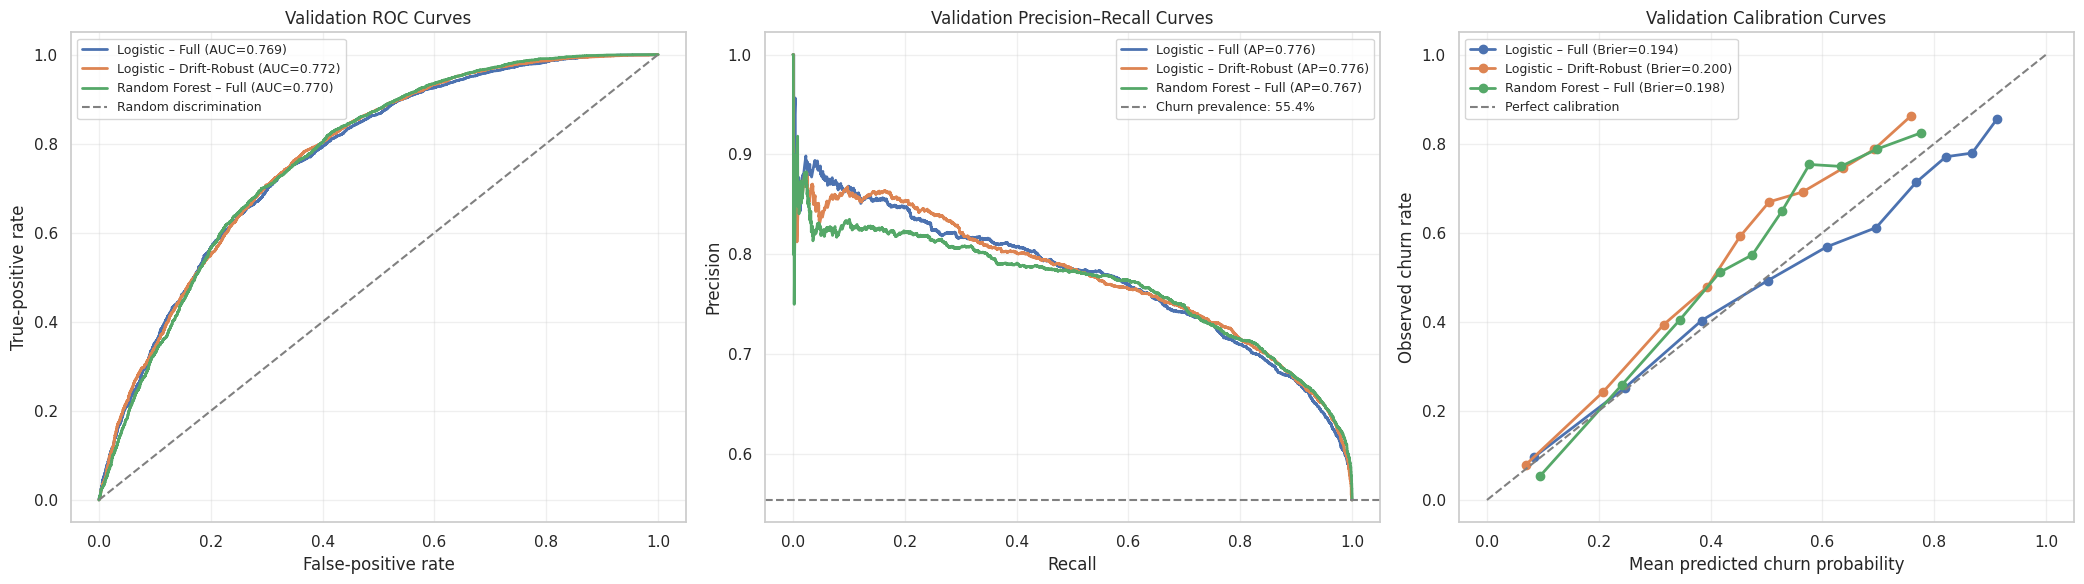


Test dataset accessed: No


In [44]:
# Validation diagnostics for the three finalist models
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    precision_recall_curve,
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)
from sklearn.calibration import calibration_curve

# Resolve stored probability keys safely
def resolve_probability_key(model_name, feature_set):
    exact_key = f"{model_name} | {feature_set}"

    if exact_key in validation_probability_store:
        return exact_key

    matches = [
        key for key in validation_probability_store
        if model_name.lower() in str(key).lower()
        and feature_set.lower() in str(key).lower()
    ]

    if len(matches) == 1:
        return matches[0]

    raise KeyError(
        f"Could not uniquely locate {model_name} with {feature_set}. "
        f"Available keys: {list(validation_probability_store.keys())}"
    )


candidate_definitions = [
    (
        "Logistic – Full",
        "Tuned Logistic Regression",
        "Full Feature Set"
    ),
    (
        "Logistic – Drift-Robust",
        "Tuned Logistic Regression",
        "Drift-Robust Feature Set"
    ),
    (
        "Random Forest – Full",
        "Tuned Random Forest",
        "Full Feature Set"
    )
]

candidate_probabilities = {}

for display_name, model_name, feature_set in candidate_definitions:
    probability_key = resolve_probability_key(
        model_name,
        feature_set
    )

    candidate_probabilities[display_name] = np.asarray(
        validation_probability_store[probability_key]
    )

y_validation_array = np.asarray(y_validation)
validation_prevalence = y_validation_array.mean()

# Overall and threshold-based scorecards
overall_rows = []
threshold_rows = []

RECALL_TARGET = 0.80

for candidate_name, probabilities in candidate_probabilities.items():

    roc_auc = roc_auc_score(
        y_validation_array,
        probabilities
    )

    pr_auc = average_precision_score(
        y_validation_array,
        probabilities
    )

    brier = brier_score_loss(
        y_validation_array,
        probabilities
    )

    overall_rows.append({
        "Candidate": candidate_name,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc,
        "Brier Score": brier
    })

    precision_values, recall_values, thresholds = (
        precision_recall_curve(
            y_validation_array,
            probabilities
        )
    )

    threshold_precision = precision_values[:-1]
    threshold_recall = recall_values[:-1]

    threshold_f1 = (
        2 * threshold_precision * threshold_recall
        / (
            threshold_precision
            + threshold_recall
            + 1e-12
        )
    )

    best_f1_index = np.argmax(threshold_f1)

    # Highest precision among thresholds achieving at least 80% recall
    eligible_indices = np.where(
        threshold_recall >= RECALL_TARGET
    )[0]

    if len(eligible_indices) > 0:
        recall_target_index = eligible_indices[
            np.argmax(threshold_precision[eligible_indices])
        ]

        recall_threshold = thresholds[recall_target_index]
        recall_target_precision = threshold_precision[
            recall_target_index
        ]
        achieved_recall = threshold_recall[
            recall_target_index
        ]
    else:
        recall_threshold = np.nan
        recall_target_precision = np.nan
        achieved_recall = np.nan

    threshold_rows.append({
        "Candidate": candidate_name,
        "Best F1 Threshold": thresholds[best_f1_index],
        "Best Validation F1": threshold_f1[best_f1_index],
        "80% Recall Threshold": recall_threshold,
        "Precision at 80% Recall": recall_target_precision,
        "Achieved Recall": achieved_recall
    })


overall_scorecard = (
    pd.DataFrame(overall_rows)
    .sort_values(
        ["ROC-AUC", "PR-AUC"],
        ascending=False
    )
    .reset_index(drop=True)
)

threshold_scorecard = (
    pd.DataFrame(threshold_rows)
    .sort_values(
        "Best Validation F1",
        ascending=False
    )
    .reset_index(drop=True)
)

print("Validation candidate scorecard:")
display(overall_scorecard.round(3))

print("\nValidation threshold scorecard:")
display(threshold_scorecard.round(3))

# ROC, precision–recall and calibration curves
fig, axes = plt.subplots(
    1,
    3,
    figsize=(21, 6)
)

for candidate_name, probabilities in candidate_probabilities.items():

    # ROC curve
    false_positive_rate, true_positive_rate, _ = roc_curve(
        y_validation_array,
        probabilities
    )

    axes[0].plot(
        false_positive_rate,
        true_positive_rate,
        linewidth=2,
        label=(
            f"{candidate_name} "
            f"(AUC={roc_auc_score(y_validation_array, probabilities):.3f})"
        )
    )

    # Precision–recall curve
    precision_values, recall_values, _ = precision_recall_curve(
        y_validation_array,
        probabilities
    )

    axes[1].plot(
        recall_values,
        precision_values,
        linewidth=2,
        label=(
            f"{candidate_name} "
            f"(AP={average_precision_score(y_validation_array, probabilities):.3f})"
        )
    )

    # Calibration curve
    observed_probability, predicted_probability = calibration_curve(
        y_validation_array,
        probabilities,
        n_bins=10,
        strategy="quantile"
    )

    axes[2].plot(
        predicted_probability,
        observed_probability,
        marker="o",
        linewidth=2,
        label=(
            f"{candidate_name} "
            f"(Brier={brier_score_loss(y_validation_array, probabilities):.3f})"
        )
    )

# ROC formatting
axes[0].plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="grey",
    label="Random discrimination"
)
axes[0].set_title("Validation ROC Curves")
axes[0].set_xlabel("False-positive rate")
axes[0].set_ylabel("True-positive rate")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Precision–recall formatting
axes[1].axhline(
    validation_prevalence,
    linestyle="--",
    color="grey",
    label=f"Churn prevalence: {validation_prevalence:.1%}"
)
axes[1].set_title("Validation Precision–Recall Curves")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

# Calibration formatting
axes[2].plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="grey",
    label="Perfect calibration"
)
axes[2].set_title("Validation Calibration Curves")
axes[2].set_xlabel("Mean predicted churn probability")
axes[2].set_ylabel("Observed churn rate")
axes[2].legend(fontsize=9)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nTest dataset accessed: No")

### Final Model Selection

The tuned drift-robust logistic regression is selected as the final production candidate. It provides the strongest ROC-AUC, joint-best PR-AUC and reliable high-recall performance while excluding unstable calendar and tenure features. The full logistic model remains a benchmark because of its slightly better calibration, while the random forest’s marginal F1 advantage does not outweigh its additional complexity.


In [45]:
# Lock the final model, feature set and operating threshold
import numpy as np
import pandas as pd

FINAL_MODEL_NAME = "Tuned Logistic Regression"
FINAL_FEATURE_SET = "Drift-Robust Feature Set"
FINAL_CANDIDATE_LABEL = "Logistic – Drift-Robust"

FINAL_THRESHOLD_POLICY = "Validation threshold targeting at least 80% recall"
FINAL_TOP_FRACTION = 0.20

# Resolve the trained-model key safely
expected_final_key = (
    f"{FINAL_MODEL_NAME} | {FINAL_FEATURE_SET}"
)

if expected_final_key in trained_models:
    FINAL_MODEL_KEY = expected_final_key
else:
    matching_model_keys = [
        key for key in trained_models
        if FINAL_MODEL_NAME.lower() in str(key).lower()
        and FINAL_FEATURE_SET.lower() in str(key).lower()
    ]

    if len(matching_model_keys) != 1:
        raise KeyError(
            "Unable to uniquely locate the selected model. "
            f"Available keys: {list(trained_models.keys())}"
        )

    FINAL_MODEL_KEY = matching_model_keys[0]

# Retrieve the previously selected validation threshold
selected_threshold_row = threshold_scorecard.loc[
    threshold_scorecard["Candidate"]
    == FINAL_CANDIDATE_LABEL
].iloc[0]

FINAL_DECISION_THRESHOLD = float(
    selected_threshold_row["80% Recall Threshold"]
)

# Retrieve validation metrics
selected_metric_row = overall_scorecard.loc[
    overall_scorecard["Candidate"]
    == FINAL_CANDIDATE_LABEL
].iloc[0]

# Lock objects for the final stage
final_model_template = trained_models[FINAL_MODEL_KEY]
final_feature_columns = list(
    drift_robust_model_feature_columns
)

final_model_selection_summary = pd.DataFrame([{
    "Selection Status": "LOCKED BEFORE TEST",
    "Final Model": FINAL_MODEL_NAME,
    "Feature Set": FINAL_FEATURE_SET,
    "Feature Count": len(final_feature_columns),
    "Decision Threshold": FINAL_DECISION_THRESHOLD,
    "Threshold Policy": FINAL_THRESHOLD_POLICY,
    "Validation ROC-AUC": selected_metric_row["ROC-AUC"],
    "Validation PR-AUC": selected_metric_row["PR-AUC"],
    "Validation Brier Score": selected_metric_row["Brier Score"],
    "Validation Precision": selected_threshold_row[
        "Precision at 80% Recall"
    ],
    "Validation Recall": selected_threshold_row[
        "Achieved Recall"
    ],
    "Campaign Ranking Fraction": FINAL_TOP_FRACTION
}])

# Selection validation checks
selection_validation = pd.DataFrame([
    {
        "Validation Check": "Final trained model available",
        "Status": (
            "PASS"
            if FINAL_MODEL_KEY in trained_models
            else "FAIL"
        )
    },
    {
        "Validation Check": "Final feature set available",
        "Status": (
            "PASS"
            if len(final_feature_columns) == 44
            else "CHECK"
        )
    },
    {
        "Validation Check": "Decision threshold within valid range",
        "Status": (
            "PASS"
            if 0 < FINAL_DECISION_THRESHOLD < 1
            else "FAIL"
        )
    },
    {
        "Validation Check": "Threshold recall target achieved",
        "Status": (
            "PASS"
            if selected_threshold_row["Achieved Recall"] >= 0.80
            else "FAIL"
        )
    }
])

display(final_model_selection_summary.round(3))
display(selection_validation)

print(
    f"Locked threshold: {FINAL_DECISION_THRESHOLD:.3f}"
)
print("The test dataset was not accessed by this cell.")

,Selection Status,Final Model,Feature Set,Feature Count,Decision Threshold,Threshold Policy,Validation ROC-AUC,Validation PR-AUC,Validation Brier Score,Validation Precision,Validation Recall,Campaign Ranking Fraction
0,LOCKED BEFORE TEST,Tuned Logistic Regression,Drift-Robust Feature Set,44,0.414,Validation threshold targeting at least 80% re...,0.772,0.776,0.2,0.715,0.801,0.2


,Validation Check,Status
0,Final trained model available,PASS
1,Final feature set available,PASS
2,Decision threshold within valid range,PASS
3,Threshold recall target achieved,PASS


Locked threshold: 0.414
The test dataset was not accessed by this cell.


### One-Time Out-of-Time Test Evaluation

The locked model is refitted using all safely labelled customer snapshots whose 90-day outcome windows end before the test period. The fixed threshold of 0.414 is then evaluated once on the August–September 2011 test set.


In [46]:
# Final refit and one-time out-of-time test evaluation
import numpy as np
import pandas as pd

from time import perf_counter
from sklearn.base import clone
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    brier_score_loss,
    confusion_matrix
)

FINAL_TEST_START_DATE = pd.Timestamp("2011-08-01")

# ---------------------------------------------------------
# 1. Create the safely labelled final-development dataset
# ---------------------------------------------------------
model_data["snapshot_date"] = pd.to_datetime(
    model_data["snapshot_date"]
)

if "outcome_end_exclusive" in model_data.columns:
    model_data["outcome_end_exclusive"] = pd.to_datetime(
        model_data["outcome_end_exclusive"]
    )

    final_development_mask = (
        model_data["outcome_end_exclusive"]
        <= FINAL_TEST_START_DATE
    )

    development_rule = (
        "Outcome window ends on or before test start"
    )
else:
    # Equivalent fallback based on the previously created schedule
    final_development_mask = (
        model_data["snapshot_date"]
        <= pd.Timestamp("2011-05-01")
    )

    development_rule = (
        "Snapshot date on or before 2011-05-01"
    )

final_development_data = (
    model_data.loc[final_development_mask]
    .copy()
    .sort_values(["snapshot_date", "customer_id"])
    .reset_index(drop=True)
)

final_test_data = (
    test_model_data.copy()
    .sort_values(["snapshot_date", "customer_id"])
    .reset_index(drop=True)
)

# Locked features and target
X_final_development = final_development_data[
    final_feature_columns
].copy()

y_final_development = final_development_data[
    target_column
].astype(int).copy()

X_final_test = final_test_data[
    final_feature_columns
].copy()

y_final_test = final_test_data[
    target_column
].astype(int).copy()

# ---------------------------------------------------------
# 2. Leakage and readiness checks before test evaluation
# ---------------------------------------------------------
missing_development_features = set(
    final_feature_columns
) - set(final_development_data.columns)

missing_test_features = set(
    final_feature_columns
) - set(final_test_data.columns)

if "snapshot_id" in final_development_data.columns:
    overlapping_snapshot_ids = len(
        set(final_development_data["snapshot_id"])
        .intersection(set(final_test_data["snapshot_id"]))
    )
else:
    overlapping_snapshot_ids = 0

if "outcome_end_exclusive" in final_development_data.columns:
    outcome_window_violations = int(
        (
            final_development_data["outcome_end_exclusive"]
            > FINAL_TEST_START_DATE
        ).sum()
    )
else:
    outcome_window_violations = 0

final_test_readiness = pd.DataFrame([
    {
        "Validation Check": "Missing development features",
        "Issues Found": len(missing_development_features),
        "Expected": 0
    },
    {
        "Validation Check": "Missing test features",
        "Issues Found": len(missing_test_features),
        "Expected": 0
    },
    {
        "Validation Check": "Overlapping development-test snapshots",
        "Issues Found": overlapping_snapshot_ids,
        "Expected": 0
    },
    {
        "Validation Check": "Development outcome windows crossing test",
        "Issues Found": outcome_window_violations,
        "Expected": 0
    },
    {
        "Validation Check": "Missing development targets",
        "Issues Found": int(y_final_development.isna().sum()),
        "Expected": 0
    },
    {
        "Validation Check": "Missing test targets",
        "Issues Found": int(y_final_test.isna().sum()),
        "Expected": 0
    }
])

final_test_readiness["Status"] = np.where(
    final_test_readiness["Issues Found"]
    == final_test_readiness["Expected"],
    "PASS",
    "FAIL"
)

if (final_test_readiness["Status"] != "PASS").any():
    display(final_test_readiness)
    raise ValueError(
        "Final test readiness validation failed."
    )

# ---------------------------------------------------------
# 3. Refit the locked model using safe pre-test data
# ---------------------------------------------------------
final_model = clone(final_model_template)

final_fit_start = perf_counter()

final_model.fit(
    X_final_development,
    y_final_development
)

FINAL_FIT_TIME_SECONDS = (
    perf_counter() - final_fit_start
)

# ---------------------------------------------------------
# 4. Perform the single locked test evaluation
# ---------------------------------------------------------
final_test_probabilities = final_model.predict_proba(
    X_final_test
)[:, 1]

final_test_class_predictions = (
    final_test_probabilities
    >= FINAL_DECISION_THRESHOLD
).astype(int)

# Business targeting metrics
top_test_count = max(
    1,
    int(np.ceil(len(y_final_test) * FINAL_TOP_FRACTION))
)

top_test_indices = np.argsort(
    -final_test_probabilities,
    kind="stable"
)[:top_test_count]

y_final_test_array = np.asarray(y_final_test)

test_recall_at_top_20 = (
    y_final_test_array[top_test_indices].sum()
    / max(y_final_test_array.sum(), 1)
)

test_lift_at_top_20 = (
    y_final_test_array[top_test_indices].mean()
    / y_final_test_array.mean()
)

# Test metrics
final_test_metric_values = {
    "ROC-AUC": roc_auc_score(
        y_final_test,
        final_test_probabilities
    ),
    "PR-AUC": average_precision_score(
        y_final_test,
        final_test_probabilities
    ),
    "Accuracy": accuracy_score(
        y_final_test,
        final_test_class_predictions
    ),
    "Balanced Accuracy": balanced_accuracy_score(
        y_final_test,
        final_test_class_predictions
    ),
    "Precision": precision_score(
        y_final_test,
        final_test_class_predictions,
        zero_division=0
    ),
    "Recall": recall_score(
        y_final_test,
        final_test_class_predictions,
        zero_division=0
    ),
    "F1": f1_score(
        y_final_test,
        final_test_class_predictions,
        zero_division=0
    ),
    "Brier Score": brier_score_loss(
        y_final_test,
        final_test_probabilities
    ),
    "Recall @ Top 20%": test_recall_at_top_20,
    "Lift @ Top 20%": test_lift_at_top_20
}

final_test_metrics = pd.DataFrame([{
    "Model": FINAL_MODEL_NAME,
    "Feature Set": FINAL_FEATURE_SET,
    "Decision Threshold": FINAL_DECISION_THRESHOLD,
    **final_test_metric_values,
    "Fit Time (Seconds)": FINAL_FIT_TIME_SECONDS
}])

# ---------------------------------------------------------
# 5. Validation-to-test generalisation comparison
# ---------------------------------------------------------
validation_probabilities = candidate_probabilities[
    FINAL_CANDIDATE_LABEL
]

validation_predictions_locked = (
    validation_probabilities
    >= FINAL_DECISION_THRESHOLD
).astype(int)

validation_locked_metrics = {
    "ROC-AUC": roc_auc_score(
        y_validation,
        validation_probabilities
    ),
    "PR-AUC": average_precision_score(
        y_validation,
        validation_probabilities
    ),
    "Accuracy": accuracy_score(
        y_validation,
        validation_predictions_locked
    ),
    "Balanced Accuracy": balanced_accuracy_score(
        y_validation,
        validation_predictions_locked
    ),
    "Precision": precision_score(
        y_validation,
        validation_predictions_locked,
        zero_division=0
    ),
    "Recall": recall_score(
        y_validation,
        validation_predictions_locked,
        zero_division=0
    ),
    "F1": f1_score(
        y_validation,
        validation_predictions_locked,
        zero_division=0
    ),
    "Brier Score": brier_score_loss(
        y_validation,
        validation_probabilities
    )
}

comparison_metrics = [
    "ROC-AUC",
    "PR-AUC",
    "Accuracy",
    "Balanced Accuracy",
    "Precision",
    "Recall",
    "F1",
    "Brier Score"
]

final_generalisation_comparison = pd.DataFrame([
    {
        "Metric": metric,
        "Validation": validation_locked_metrics[metric],
        "Test": final_test_metric_values[metric],
        "Test minus Validation": (
            final_test_metric_values[metric]
            - validation_locked_metrics[metric]
        )
    }
    for metric in comparison_metrics
])

# Confusion matrix
true_negative, false_positive, false_negative, true_positive = (
    confusion_matrix(
        y_final_test,
        final_test_class_predictions,
        labels=[0, 1]
    ).ravel()
)

final_test_confusion_summary = pd.DataFrame([{
    "True Negatives": true_negative,
    "False Positives": false_positive,
    "False Negatives": false_negative,
    "True Positives": true_positive
}])

# ---------------------------------------------------------
# 6. Create row-level scored test data for later analysis
# ---------------------------------------------------------
identifier_columns = [
    column for column in [
        "snapshot_id",
        "customer_id",
        "snapshot_date",
        target_column
    ]
    if column in final_test_data.columns
]

final_test_scored_data = final_test_data[
    identifier_columns
].copy()

final_test_scored_data = final_test_scored_data.rename(
    columns={target_column: "actual_churn"}
)

final_test_scored_data["churn_probability"] = (
    final_test_probabilities
)

final_test_scored_data["predicted_churn"] = (
    final_test_class_predictions
)

final_test_scored_data["risk_percentile"] = (
    pd.Series(final_test_probabilities)
    .rank(method="average", pct=True)
    .mul(100)
    .to_numpy()
)

top_20_flags = np.zeros(
    len(final_test_scored_data),
    dtype=int
)
top_20_flags[top_test_indices] = 1

final_test_scored_data["top_20_priority"] = (
    top_20_flags
)

# ---------------------------------------------------------
# 7. Display final results
# ---------------------------------------------------------
print("Final development and test setup:")
print(f"Development rule: {development_rule}")
print(
    f"Development rows: {len(final_development_data):,}"
)
print(
    f"Development snapshots: "
    f"{final_development_data['snapshot_date'].nunique()}"
)
print(
    f"Test rows: {len(final_test_data):,}"
)
print(
    f"Test snapshots: "
    f"{final_test_data['snapshot_date'].nunique()}"
)
print(
    f"Locked threshold: {FINAL_DECISION_THRESHOLD:.3f}"
)

print("\nFinal test readiness:")
display(final_test_readiness)

print("\nOne-time out-of-time test results:")
display(final_test_metrics.round(3))

print("\nValidation-to-test comparison:")
display(final_generalisation_comparison.round(3))

print("\nTest confusion matrix summary:")
display(final_test_confusion_summary)

print(
    "\nTest dataset accessed: Yes — "
    "the single locked evaluation is complete."
)

Final development and test setup:
Development rule: Snapshot date on or before 2011-05-01
Development rows: 37,019
Development snapshots: 12
Test rows: 5,534
Test snapshots: 2
Locked threshold: 0.414

Final test readiness:


,Validation Check,Issues Found,Expected,Status
0,Missing development features,0,0,PASS
1,Missing test features,0,0,PASS
2,Overlapping development-test snapshots,0,0,PASS
3,Development outcome windows crossing test,0,0,PASS
4,Missing development targets,0,0,PASS
5,Missing test targets,0,0,PASS



One-time out-of-time test results:


,Model,Feature Set,Decision Threshold,ROC-AUC,PR-AUC,Accuracy,Balanced Accuracy,Precision,Recall,F1,Brier Score,Recall @ Top 20%,Lift @ Top 20%,Fit Time (Seconds)
0,Tuned Logistic Regression,Drift-Robust Feature Set,0.414,0.773,0.683,0.648,0.681,0.549,0.881,0.677,0.197,0.358,1.789,2.086



Validation-to-test comparison:


,Metric,Validation,Test,Test minus Validation
0,ROC-AUC,0.772,0.773,0.001
1,PR-AUC,0.776,0.683,-0.093
2,Accuracy,0.713,0.648,-0.065
3,Balanced Accuracy,0.702,0.681,-0.022
4,Precision,0.715,0.549,-0.166
5,Recall,0.801,0.881,0.080
6,F1,0.756,0.677,-0.079
7,Brier Score,0.200,0.197,-0.003



Test confusion matrix summary:


,True Negatives,False Positives,False Negatives,True Positives
0,1547,1673,276,2038



Test dataset accessed: Yes — the single locked evaluation is complete.


### Final Test Findings

The model preserved its out-of-time ranking performance, achieving a test ROC-AUC of 0.773 and a Brier score of 0.197. The lower test churn prevalence partly reduced precision and PR-AUC, while the locked threshold successfully identified 88.1% of actual churners. For budget-constrained campaigns, the highest-risk 20% captured 35.8% of churners with 1.79× lift.


Final diagnostic summary:


,Metric,Value
0,Validation churn prevalence,0.554
1,Test churn prevalence,0.418
2,Test ROC-AUC,0.773
3,Test PR-AUC,0.683
4,Test PR-AUC lift over prevalence,1.634
5,Test Brier score,0.197
6,No-skill Brier score,0.243
7,Brier skill score,0.188
8,Top-20% churn rate,0.748
9,Top-20% lift,1.789



Final business targeting summary:


,Test Customers,Actual Churners,Predicted At-Risk,Captured Churners,Missed Churners,Top-20% Customers,Churners in Top 20%,Top-20% Churn Rate (%)
0,5534,2314,3711,2038,276,1107,828,74.8


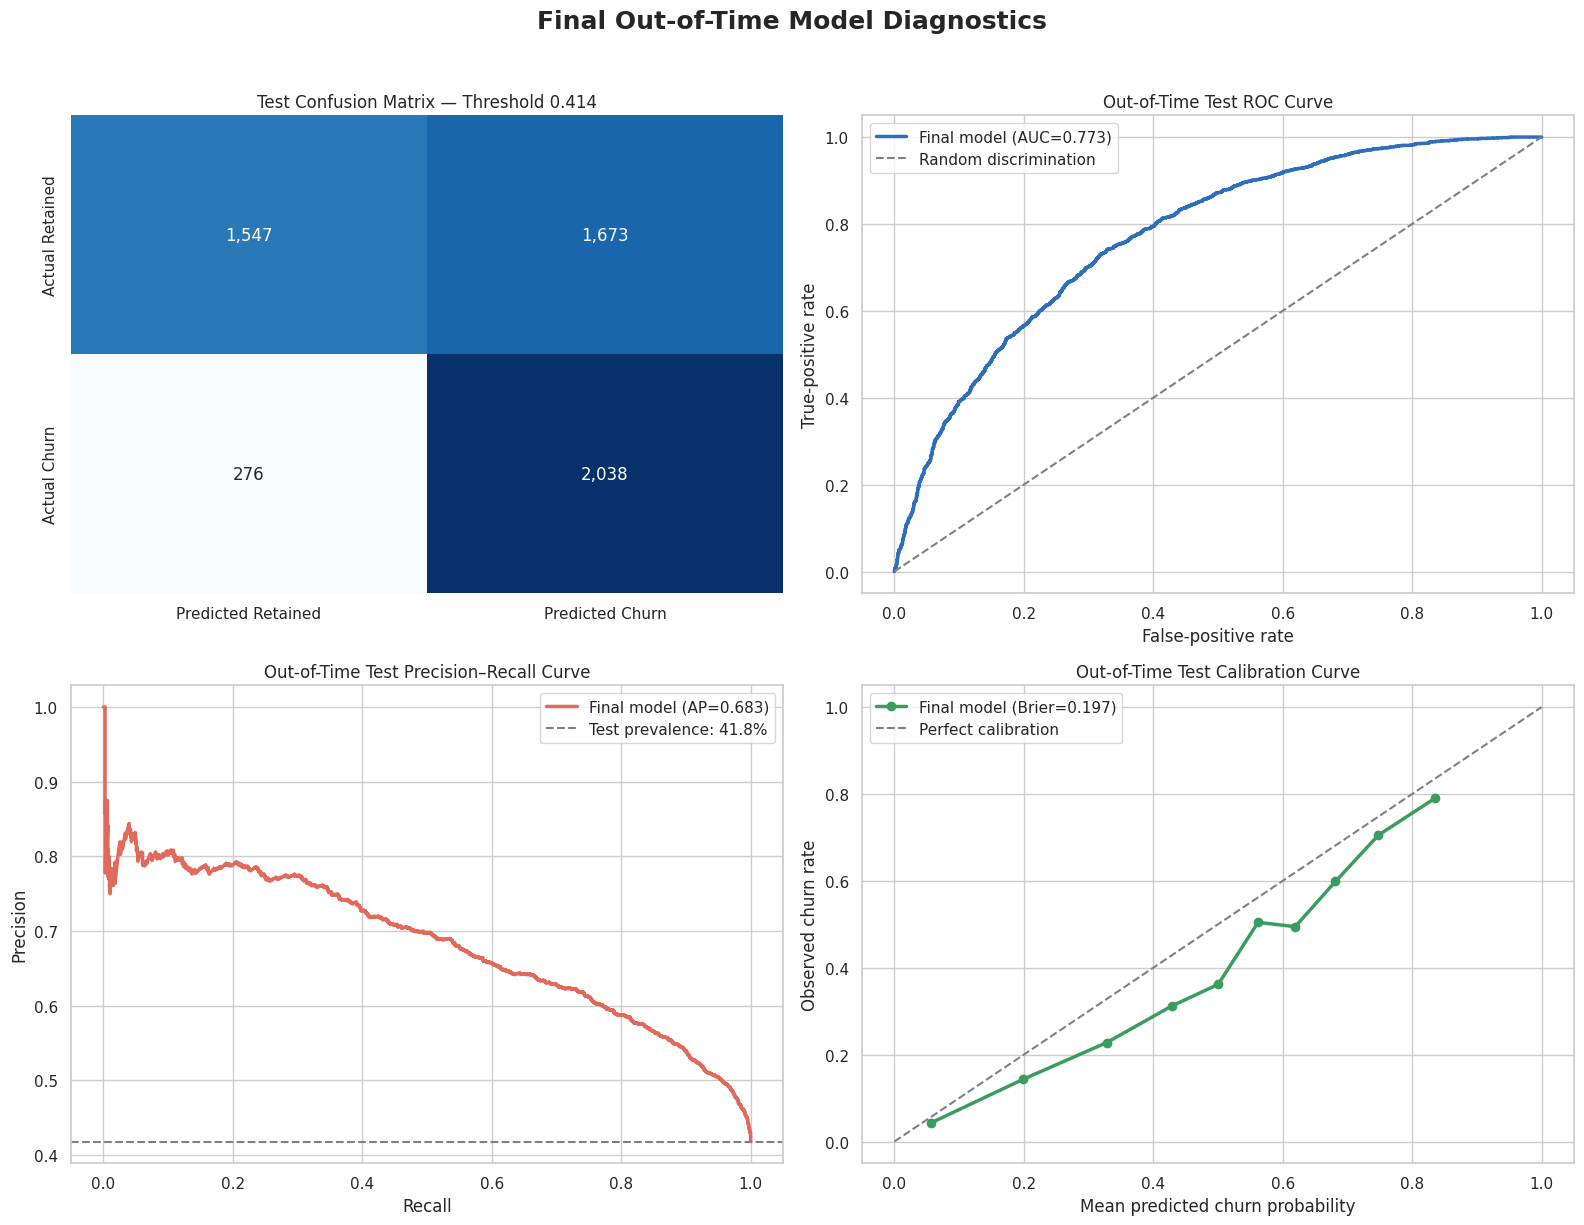

Diagnostic-only analysis completed. The locked model and threshold were not changed.


In [47]:
# Final test diagnostic summary and visual evaluation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    precision_recall_curve
)
from sklearn.calibration import calibration_curve

# ---------------------------------------------------------
# 1. Prevalence-adjusted and business metrics
# ---------------------------------------------------------
validation_churn_prevalence = np.mean(y_validation)
test_churn_prevalence = np.mean(y_final_test)

validation_pr_lift = (
    validation_locked_metrics["PR-AUC"]
    / validation_churn_prevalence
)

test_pr_lift = (
    final_test_metric_values["PR-AUC"]
    / test_churn_prevalence
)

# Brier score of a constant-prevalence prediction
test_no_skill_brier = (
    test_churn_prevalence
    * (1 - test_churn_prevalence)
)

test_brier_skill_score = (
    1
    - final_test_metric_values["Brier Score"]
    / test_no_skill_brier
)

actual_test_churners = int(y_final_test.sum())
predicted_at_risk = int(
    final_test_class_predictions.sum()
)

captured_test_churners = int(
    (
        (y_final_test_array == 1)
        & (final_test_class_predictions == 1)
    ).sum()
)

missed_test_churners = int(
    (
        (y_final_test_array == 1)
        & (final_test_class_predictions == 0)
    ).sum()
)

top_20_customers = len(top_test_indices)
top_20_churners = int(
    y_final_test_array[top_test_indices].sum()
)
top_20_churn_rate = (
    y_final_test_array[top_test_indices].mean()
)

final_diagnostic_summary = pd.DataFrame([
    {
        "Metric": "Validation churn prevalence",
        "Value": validation_churn_prevalence
    },
    {
        "Metric": "Test churn prevalence",
        "Value": test_churn_prevalence
    },
    {
        "Metric": "Test ROC-AUC",
        "Value": final_test_metric_values["ROC-AUC"]
    },
    {
        "Metric": "Test PR-AUC",
        "Value": final_test_metric_values["PR-AUC"]
    },
    {
        "Metric": "Test PR-AUC lift over prevalence",
        "Value": test_pr_lift
    },
    {
        "Metric": "Test Brier score",
        "Value": final_test_metric_values["Brier Score"]
    },
    {
        "Metric": "No-skill Brier score",
        "Value": test_no_skill_brier
    },
    {
        "Metric": "Brier skill score",
        "Value": test_brier_skill_score
    },
    {
        "Metric": "Top-20% churn rate",
        "Value": top_20_churn_rate
    },
    {
        "Metric": "Top-20% lift",
        "Value": final_test_metric_values["Lift @ Top 20%"]
    }
])

final_business_summary = pd.DataFrame([{
    "Test Customers": len(y_final_test),
    "Actual Churners": actual_test_churners,
    "Predicted At-Risk": predicted_at_risk,
    "Captured Churners": captured_test_churners,
    "Missed Churners": missed_test_churners,
    "Top-20% Customers": top_20_customers,
    "Churners in Top 20%": top_20_churners,
    "Top-20% Churn Rate (%)": top_20_churn_rate * 100
}])

print("Final diagnostic summary:")
display(final_diagnostic_summary.round(3))

print("\nFinal business targeting summary:")
display(final_business_summary.round(2))

# ---------------------------------------------------------
# 2. Final diagnostic charts
# ---------------------------------------------------------
sns.set_theme(style="whitegrid")

figure, axes = plt.subplots(
    2,
    2,
    figsize=(16, 12)
)

# Confusion matrix
test_confusion_matrix = confusion_matrix(
    y_final_test,
    final_test_class_predictions,
    labels=[0, 1]
)

sns.heatmap(
    test_confusion_matrix,
    annot=True,
    fmt=",d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Predicted Retained", "Predicted Churn"],
    yticklabels=["Actual Retained", "Actual Churn"],
    ax=axes[0, 0]
)

axes[0, 0].set_title(
    f"Test Confusion Matrix — Threshold {FINAL_DECISION_THRESHOLD:.3f}"
)
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("")

# ROC curve
test_false_positive_rate, test_true_positive_rate, _ = (
    roc_curve(
        y_final_test,
        final_test_probabilities
    )
)

axes[0, 1].plot(
    test_false_positive_rate,
    test_true_positive_rate,
    linewidth=2.5,
    color="#2E6FBB",
    label=(
        f"Final model "
        f"(AUC={final_test_metric_values['ROC-AUC']:.3f})"
    )
)

axes[0, 1].plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="grey",
    label="Random discrimination"
)

axes[0, 1].set_title("Out-of-Time Test ROC Curve")
axes[0, 1].set_xlabel("False-positive rate")
axes[0, 1].set_ylabel("True-positive rate")
axes[0, 1].legend()

# Precision–recall curve
test_precision_curve, test_recall_curve, _ = (
    precision_recall_curve(
        y_final_test,
        final_test_probabilities
    )
)

axes[1, 0].plot(
    test_recall_curve,
    test_precision_curve,
    linewidth=2.5,
    color="#E26A5B",
    label=(
        f"Final model "
        f"(AP={final_test_metric_values['PR-AUC']:.3f})"
    )
)

axes[1, 0].axhline(
    test_churn_prevalence,
    linestyle="--",
    color="grey",
    label=f"Test prevalence: {test_churn_prevalence:.1%}"
)

axes[1, 0].set_title(
    "Out-of-Time Test Precision–Recall Curve"
)
axes[1, 0].set_xlabel("Recall")
axes[1, 0].set_ylabel("Precision")
axes[1, 0].legend()

# Calibration curve
observed_test_probability, predicted_test_probability = (
    calibration_curve(
        y_final_test,
        final_test_probabilities,
        n_bins=10,
        strategy="quantile"
    )
)

axes[1, 1].plot(
    predicted_test_probability,
    observed_test_probability,
    marker="o",
    linewidth=2.5,
    color="#3A9D5D",
    label=(
        f"Final model "
        f"(Brier={final_test_metric_values['Brier Score']:.3f})"
    )
)

axes[1, 1].plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="grey",
    label="Perfect calibration"
)

axes[1, 1].set_title(
    "Out-of-Time Test Calibration Curve"
)
axes[1, 1].set_xlabel("Mean predicted churn probability")
axes[1, 1].set_ylabel("Observed churn rate")
axes[1, 1].legend()

figure.suptitle(
    "Final Out-of-Time Model Diagnostics",
    fontsize=18,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()

print(
    "Diagnostic-only analysis completed. "
    "The locked model and threshold were not changed."
)

### Model Explainability

Logistic-regression coefficients show the direction of each feature’s association with churn, while validation permutation importance measures its contribution to predictive discrimination. Positive coefficients indicate higher churn risk and negative coefficients indicate stronger retention. These relationships are predictive associations rather than causal effects.


Transformed model features: 76
Non-zero coefficients: 68

Strongest churn-risk associations:


,Feature,Coefficient,Odds Multiplier,Risk Direction
0,Missing indicator: lateness_ratio,0.730,2.075,Higher values → Churn
1,latest_country_infrequent_sklearn,0.476,1.610,Higher values → Churn
2,recency_days,0.371,1.449,Higher values → Churn
3,latest_country_Sweden,0.354,1.424,Higher values → Churn
4,extreme_lateness_flag,0.348,1.417,Higher values → Churn
5,latest_country_Norway,0.304,1.355,Higher values → Churn
6,latest_country_USA,0.270,1.311,Higher values → Churn
7,latest_country_Greece,0.237,1.267,Higher values → Churn
8,latest_country_Portugal,0.223,1.250,Higher values → Churn
9,Missing indicator: gap_variability_lifetime,0.205,1.228,Higher values → Churn



Strongest retention associations:


,Feature,Coefficient,Odds Multiplier,Risk Direction
0,latest_country_Poland,-1.996,0.136,Higher values → Retention
1,activity_span_180d,-1.008,0.365,Higher values → Retention
2,latest_country_Finland,-0.595,0.551,Higher values → Retention
3,latest_country_Belgium,-0.560,0.571,Higher values → Retention
4,latest_country_EIRE,-0.545,0.580,Higher values → Retention
5,latest_country_France,-0.516,0.597,Higher values → Retention
6,latest_country_Denmark,-0.492,0.611,Higher values → Retention
7,inactive_60d,-0.309,0.734,Higher values → Retention
8,latest_country_Germany,-0.260,0.771,Higher values → Retention
9,Missing indicator: gap_variability_180d,-0.215,0.807,Higher values → Retention



Top validation permutation features:


,Feature,Mean ROC-AUC Reduction,Importance Standard Deviation
0,activity_span_180d,0.0725,0.0033
1,active_days_90d,0.0191,0.0017
2,lifetime_orders,0.0182,0.0016
3,recency_days,0.0179,0.0011
4,days_over_expected_purchase,0.0137,0.0006
5,average_gap_days_180d,0.0098,0.0016
6,median_gap_days_lifetime,0.0096,0.0004
7,extreme_lateness_flag,0.0084,0.0006
8,lateness_ratio,0.0049,0.0003
9,lifetime_revenue,0.0048,0.0012



Explainability validation:


,Validation Check,Issues Found,Expected,Status
0,Coefficient-feature alignment,0,0,PASS
1,Non-finite coefficients,0,0,PASS
2,Raw features assessed by permutation,0,0,PASS


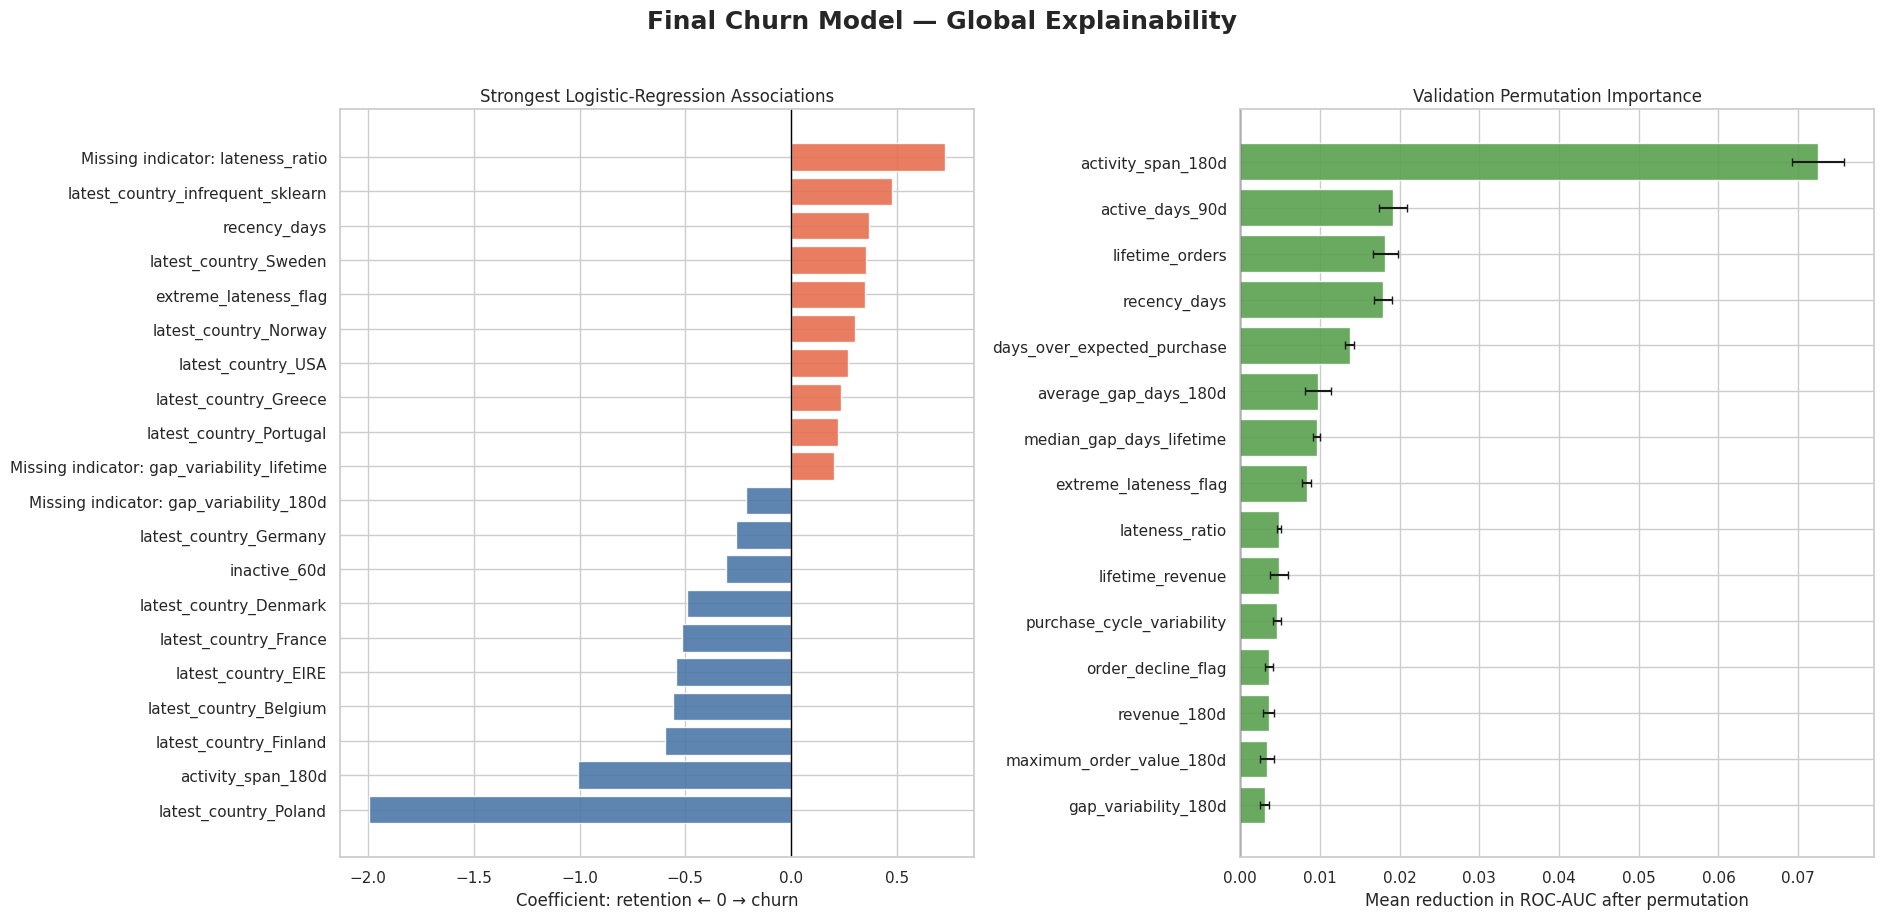

Explainability completed without changing the finalized model or test results.


In [48]:
# Global model explainability:
# logistic coefficients and validation permutation importance
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance

# ---------------------------------------------------------
# 1. Locate fitted pipeline components automatically
# ---------------------------------------------------------
preprocessor_step_name = next(
    name for name, estimator in final_model.named_steps.items()
    if isinstance(estimator, ColumnTransformer)
)

classifier_step_name = next(
    name for name, estimator in final_model.named_steps.items()
    if isinstance(estimator, LogisticRegression)
)

fitted_preprocessor = final_model.named_steps[
    preprocessor_step_name
]

fitted_classifier = final_model.named_steps[
    classifier_step_name
]

transformed_feature_names = (
    fitted_preprocessor.get_feature_names_out()
)

logistic_coefficients = (
    fitted_classifier.coef_.ravel()
)

if len(transformed_feature_names) != len(logistic_coefficients):
    raise ValueError(
        "Feature-name and coefficient counts do not match."
    )

# Clean ColumnTransformer prefixes
def clean_feature_name(feature_name):
    feature_name = str(feature_name)

    if "__" in feature_name:
        feature_name = feature_name.split("__", 1)[1]

    feature_name = feature_name.replace(
        "missingindicator_",
        "Missing indicator: "
    )

    return feature_name


cleaned_feature_names = [
    clean_feature_name(feature)
    for feature in transformed_feature_names
]

# ---------------------------------------------------------
# 2. Build coefficient interpretation table
# ---------------------------------------------------------
model_coefficient_table = pd.DataFrame({
    "Feature": cleaned_feature_names,
    "Coefficient": logistic_coefficients
})

model_coefficient_table["Absolute Coefficient"] = (
    model_coefficient_table["Coefficient"].abs()
)

model_coefficient_table["Odds Multiplier"] = np.exp(
    np.clip(
        model_coefficient_table["Coefficient"],
        -20,
        20
    )
)

model_coefficient_table["Risk Direction"] = np.select(
    [
        model_coefficient_table["Coefficient"] > 0,
        model_coefficient_table["Coefficient"] < 0
    ],
    [
        "Higher values → Churn",
        "Higher values → Retention"
    ],
    default="No contribution"
)

nonzero_coefficient_table = model_coefficient_table.loc[
    model_coefficient_table["Coefficient"].abs() > 1e-10
].copy()

top_churn_coefficients = (
    nonzero_coefficient_table
    .sort_values("Coefficient", ascending=False)
    .head(15)
    .reset_index(drop=True)
)

top_retention_coefficients = (
    nonzero_coefficient_table
    .sort_values("Coefficient", ascending=True)
    .head(15)
    .reset_index(drop=True)
)

# ---------------------------------------------------------
# 3. Validation permutation importance
# ---------------------------------------------------------
# Uses the training-fitted model and validation data.
# The finalized model and test predictions are not changed.
validation_permutation_result = permutation_importance(
    final_model_template,
    X_validation_registry[FINAL_FEATURE_SET],
    y_validation,
    scoring="roc_auc",
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

permutation_importance_table = pd.DataFrame({
    "Feature": X_validation_registry[
        FINAL_FEATURE_SET
    ].columns,
    "Mean ROC-AUC Reduction": (
        validation_permutation_result.importances_mean
    ),
    "Importance Standard Deviation": (
        validation_permutation_result.importances_std
    )
})

permutation_importance_table = (
    permutation_importance_table
    .sort_values(
        "Mean ROC-AUC Reduction",
        ascending=False
    )
    .reset_index(drop=True)
)

top_permutation_features = (
    permutation_importance_table
    .head(15)
    .copy()
)

# ---------------------------------------------------------
# 4. Explainability validation
# ---------------------------------------------------------
explainability_validation = pd.DataFrame([
    {
        "Validation Check": "Coefficient-feature alignment",
        "Issues Found": abs(
            len(transformed_feature_names)
            - len(logistic_coefficients)
        ),
        "Expected": 0
    },
    {
        "Validation Check": "Non-finite coefficients",
        "Issues Found": int(
            (~np.isfinite(logistic_coefficients)).sum()
        ),
        "Expected": 0
    },
    {
        "Validation Check": "Raw features assessed by permutation",
        "Issues Found": abs(
            len(permutation_importance_table)
            - len(final_feature_columns)
        ),
        "Expected": 0
    }
])

explainability_validation["Status"] = np.where(
    explainability_validation["Issues Found"]
    == explainability_validation["Expected"],
    "PASS",
    "FAIL"
)

print(
    f"Transformed model features: "
    f"{len(transformed_feature_names):,}"
)
print(
    f"Non-zero coefficients: "
    f"{len(nonzero_coefficient_table):,}"
)

print("\nStrongest churn-risk associations:")
display(
    top_churn_coefficients[
        [
            "Feature",
            "Coefficient",
            "Odds Multiplier",
            "Risk Direction"
        ]
    ].round(3)
)

print("\nStrongest retention associations:")
display(
    top_retention_coefficients[
        [
            "Feature",
            "Coefficient",
            "Odds Multiplier",
            "Risk Direction"
        ]
    ].round(3)
)

print("\nTop validation permutation features:")
display(top_permutation_features.round(4))

print("\nExplainability validation:")
display(explainability_validation)

# ---------------------------------------------------------
# 5. Explainability charts
# ---------------------------------------------------------
coefficient_plot_data = pd.concat([
    top_churn_coefficients.head(10),
    top_retention_coefficients.head(10)
]).drop_duplicates("Feature")

coefficient_plot_data = coefficient_plot_data.sort_values(
    "Coefficient",
    ascending=True
)

coefficient_colours = np.where(
    coefficient_plot_data["Coefficient"] > 0,
    "#E76F51",
    "#4C78A8"
)

permutation_plot_data = (
    top_permutation_features
    .sort_values(
        "Mean ROC-AUC Reduction",
        ascending=True
    )
)

figure, axes = plt.subplots(
    1,
    2,
    figsize=(19, 9)
)

axes[0].barh(
    coefficient_plot_data["Feature"],
    coefficient_plot_data["Coefficient"],
    color=coefficient_colours,
    alpha=0.9
)

axes[0].axvline(
    0,
    color="black",
    linewidth=1
)

axes[0].set_title(
    "Strongest Logistic-Regression Associations"
)
axes[0].set_xlabel(
    "Coefficient: retention ← 0 → churn"
)
axes[0].set_ylabel("")

axes[1].barh(
    permutation_plot_data["Feature"],
    permutation_plot_data["Mean ROC-AUC Reduction"],
    xerr=permutation_plot_data[
        "Importance Standard Deviation"
    ],
    color="#59A14F",
    alpha=0.9,
    capsize=3
)

axes[1].axvline(
    0,
    color="black",
    linewidth=1
)

axes[1].set_title(
    "Validation Permutation Importance"
)
axes[1].set_xlabel(
    "Mean reduction in ROC-AUC after permutation"
)
axes[1].set_ylabel("")

figure.suptitle(
    "Final Churn Model — Global Explainability",
    fontsize=18,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()

print(
    "Explainability completed without changing "
    "the finalized model or test results."
)

### Customer Risk Segmentation and Revenue at Risk

The most stable churn drivers are customer activity span, recent active days, lifetime order frequency, purchase recency and deviation from the customer’s expected purchase cycle. The latest operational snapshot is divided into percentile-based risk tiers. Estimated 90-day customer value is defined as half of historical 180-day revenue, and revenue at risk equals this value multiplied by predicted churn probability.


Latest operational snapshot: 2011-09-01
Customers scored: 2,768
Total estimated 90-day value: £1,743,419.59
Total probability-weighted revenue at risk: £392,464.26

Risk-tier performance and exposure:


,risk_tier,Customers,Customer Share (%),Actual_Churners,Churn Rate (%),Average Predicted Risk (%),Churner Capture (%),Estimated_90d_Value,Revenue_At_Risk,Revenue at Risk Share (%)
0,Low,1383,49.96,275,19.88,30.06,25.28,1476445.42,214420.37,54.63
1,Medium,831,30.02,419,50.42,62.20,38.51,185479.97,113539.08,28.93
2,High,277,10.01,180,64.98,74.85,16.54,43881.44,32793.40,8.36
3,Critical,277,10.01,214,77.26,83.77,19.67,37612.77,31711.41,8.08



Highest revenue-at-risk customers:


,priority_rank,customer_id,snapshot_date,latest_country,churn_probability,risk_percentile,risk_tier,recency_days,orders_180d,activity_span_180d,revenue_180d,estimated_90d_customer_value,revenue_at_risk,recommended_action,actual_churn
0,1,15749,2011-09-01,United Kingdom,0.427,34.790,Low,135.444,1,0.000,21535.90,10767.950,4598.599,Standard communication; avoid costly incentives,1
1,2,15098,2011-09-01,United Kingdom,0.195,14.776,Low,82.352,3,0.008,39916.50,19958.250,3890.965,Standard communication; avoid costly incentives,1
2,3,12590,2011-09-01,Germany,0.436,36.127,Low,111.385,1,0.000,9341.26,4670.630,2034.636,Standard communication; avoid costly incentives,1
3,4,16333,2011-09-01,United Kingdom,0.332,25.217,Low,23.503,13,128.984,9940.24,4970.120,1649.532,Standard communication; avoid costly incentives,0
4,5,12744,2011-09-01,Singapore,0.467,40.282,Low,44.503,2,104.040,6068.06,3034.030,1416.739,Standard communication; avoid costly incentives,0
5,6,13135,2011-09-01,United Kingdom,0.894,98.483,Critical,96.547,1,0.000,3096.00,1548.000,1383.795,Priority personal outreach and tailored incentive,1
6,7,17396,2011-09-01,United Kingdom,0.619,64.595,Medium,48.569,4,0.001,4386.30,2193.150,1357.033,Automated re-engagement and product recommenda...,0
7,8,12378,2011-09-01,Switzerland,0.668,72.760,Medium,29.560,1,0.000,4008.62,2004.310,1339.008,Automated re-engagement and product recommenda...,1
8,9,12409,2011-09-01,Switzerland,0.371,29.263,Low,82.487,1,0.000,6207.08,3103.540,1151.542,Standard communication; avoid costly incentives,0
9,10,12432,2011-09-01,Norway,0.684,75.325,Medium,72.438,2,0.001,3316.66,1658.330,1135.033,Automated re-engagement and product recommenda...,0



Risk-segmentation validation:


,Validation Check,Issues Found,Expected,Status
0,Duplicate latest customer rows,0,0,PASS
1,Missing risk tiers,0,0,PASS
2,Negative revenue-at-risk values,0,0,PASS
3,Revenue-at-risk formula mismatch,0,0,PASS
4,Churn rate rises across risk tiers,0,0,PASS


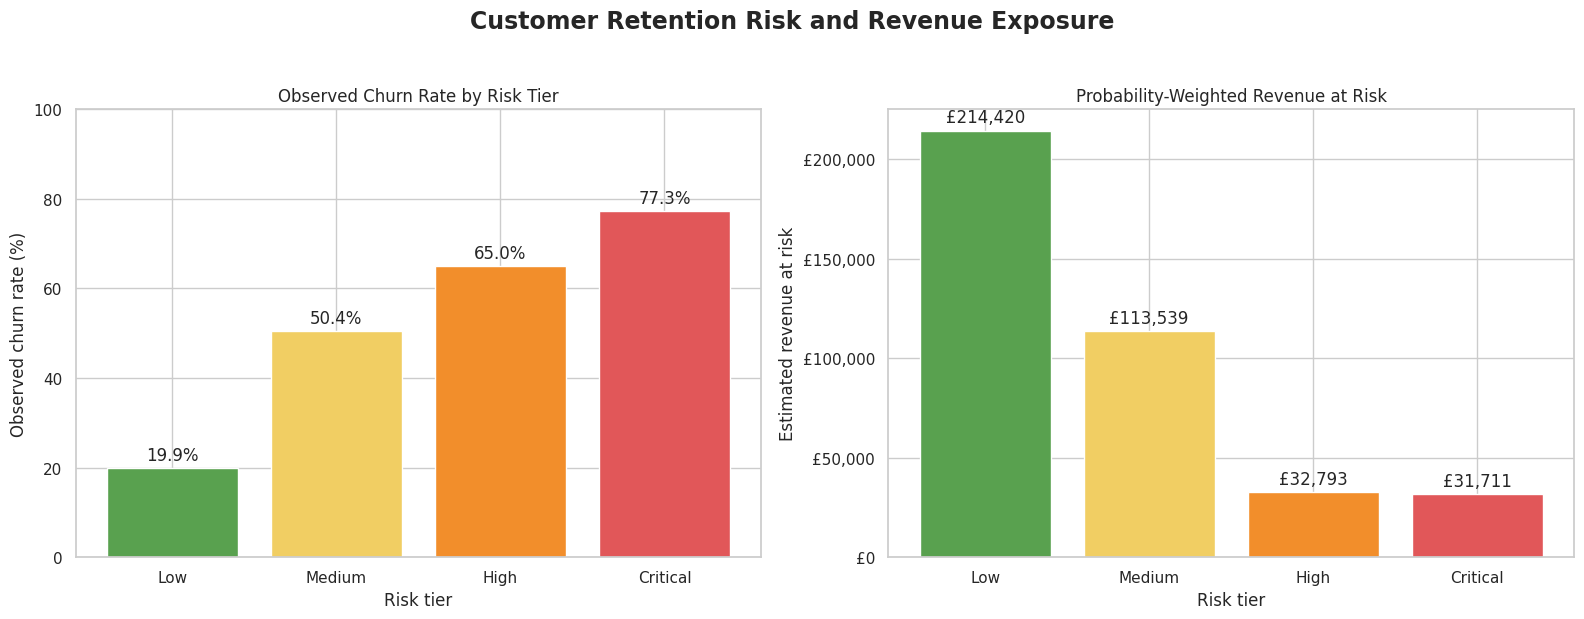

In [49]:
# Operational risk tiers, retention priorities and revenue at risk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# ---------------------------------------------------------
# 1. Build the latest operational customer snapshot
# ---------------------------------------------------------
operational_scoring_data = final_test_data.copy()

operational_scoring_data["churn_probability"] = (
    final_test_probabilities
)

operational_scoring_data["predicted_churn"] = (
    final_test_class_predictions
)

operational_scoring_data["actual_churn"] = (
    operational_scoring_data[target_column].astype(int)
)

LATEST_OPERATIONAL_SNAPSHOT = (
    operational_scoring_data["snapshot_date"].max()
)

latest_customer_scores = (
    operational_scoring_data.loc[
        operational_scoring_data["snapshot_date"]
        == LATEST_OPERATIONAL_SNAPSHOT
    ]
    .copy()
    .sort_values("customer_id")
    .reset_index(drop=True)
)

# Ensure historical revenue cannot be negative
latest_customer_scores["revenue_180d"] = (
    latest_customer_scores["revenue_180d"]
    .clip(lower=0)
)

# Historical run-rate estimate for the next 90 days
latest_customer_scores[
    "estimated_90d_customer_value"
] = (
    latest_customer_scores["revenue_180d"]
    * (90 / 180)
)

# Probability-weighted revenue exposure
latest_customer_scores["revenue_at_risk"] = (
    latest_customer_scores["churn_probability"]
    * latest_customer_scores[
        "estimated_90d_customer_value"
    ]
)

# ---------------------------------------------------------
# 2. Create percentile-based operational risk tiers
# ---------------------------------------------------------
latest_customer_scores["risk_percentile"] = (
    latest_customer_scores["churn_probability"]
    .rank(method="average", pct=True)
    .mul(100)
)

latest_customer_scores["risk_tier"] = np.select(
    [
        latest_customer_scores["risk_percentile"] >= 90,
        latest_customer_scores["risk_percentile"] >= 80,
        latest_customer_scores["risk_percentile"] >= 50
    ],
    [
        "Critical",
        "High",
        "Medium"
    ],
    default="Low"
)

risk_tier_order = [
    "Low",
    "Medium",
    "High",
    "Critical"
]

latest_customer_scores["risk_tier"] = pd.Categorical(
    latest_customer_scores["risk_tier"],
    categories=risk_tier_order,
    ordered=True
)

retention_action_map = {
    "Critical": (
        "Priority personal outreach and tailored incentive"
    ),
    "High": (
        "Targeted retention offer and account reminder"
    ),
    "Medium": (
        "Automated re-engagement and product recommendations"
    ),
    "Low": (
        "Standard communication; avoid costly incentives"
    )
}

latest_customer_scores["recommended_action"] = (
    latest_customer_scores["risk_tier"]
    .astype("object")
    .map(retention_action_map)
)

latest_customer_scores["campaign_priority"] = np.where(
    latest_customer_scores["risk_tier"]
    .astype(str)
    .isin(["Critical", "High"]),
    1,
    0
)

# ---------------------------------------------------------
# 3. Create tier-level business summary
# ---------------------------------------------------------
risk_tier_summary = (
    latest_customer_scores
    .groupby("risk_tier", observed=True)
    .agg(
        Customers=("customer_id", "nunique"),
        Actual_Churners=("actual_churn", "sum"),
        Churn_Rate=("actual_churn", "mean"),
        Average_Predicted_Risk=(
            "churn_probability",
            "mean"
        ),
        Estimated_90d_Value=(
            "estimated_90d_customer_value",
            "sum"
        ),
        Revenue_At_Risk=(
            "revenue_at_risk",
            "sum"
        )
    )
    .reindex(risk_tier_order)
    .reset_index()
)

total_customers = risk_tier_summary[
    "Customers"
].sum()

total_actual_churners = risk_tier_summary[
    "Actual_Churners"
].sum()

total_revenue_at_risk = risk_tier_summary[
    "Revenue_At_Risk"
].sum()

risk_tier_summary["Customer_Share"] = (
    risk_tier_summary["Customers"]
    / total_customers
)

risk_tier_summary["Churner_Capture_Share"] = (
    risk_tier_summary["Actual_Churners"]
    / max(total_actual_churners, 1)
)

risk_tier_summary["Revenue_At_Risk_Share"] = (
    risk_tier_summary["Revenue_At_Risk"]
    / max(total_revenue_at_risk, 1)
)

# Percentage versions for reporting
risk_tier_summary["Churn Rate (%)"] = (
    risk_tier_summary["Churn_Rate"] * 100
)

risk_tier_summary["Average Predicted Risk (%)"] = (
    risk_tier_summary["Average_Predicted_Risk"] * 100
)

risk_tier_summary["Customer Share (%)"] = (
    risk_tier_summary["Customer_Share"] * 100
)

risk_tier_summary["Churner Capture (%)"] = (
    risk_tier_summary["Churner_Capture_Share"] * 100
)

risk_tier_summary["Revenue at Risk Share (%)"] = (
    risk_tier_summary["Revenue_At_Risk_Share"] * 100
)

# ---------------------------------------------------------
# 4. Build the prioritized customer action table
# ---------------------------------------------------------
priority_columns = [
    column for column in [
        "customer_id",
        "snapshot_date",
        "latest_country",
        "churn_probability",
        "risk_percentile",
        "risk_tier",
        "recency_days",
        "orders_180d",
        "activity_span_180d",
        "revenue_180d",
        "estimated_90d_customer_value",
        "revenue_at_risk",
        "recommended_action",
        "actual_churn"
    ]
    if column in latest_customer_scores.columns
]

retention_priority_table = (
    latest_customer_scores[
        priority_columns
    ]
    .sort_values(
        ["revenue_at_risk", "churn_probability"],
        ascending=False
    )
    .reset_index(drop=True)
)

retention_priority_table.insert(
    0,
    "priority_rank",
    np.arange(1, len(retention_priority_table) + 1)
)

# ---------------------------------------------------------
# 5. Validate the segmentation
# ---------------------------------------------------------
maximum_formula_difference = (
    latest_customer_scores["revenue_at_risk"]
    - (
        latest_customer_scores["churn_probability"]
        * latest_customer_scores[
            "estimated_90d_customer_value"
        ]
    )
).abs().max()

ordered_churn_rates = (
    risk_tier_summary["Churn_Rate"]
    .fillna(0)
    .to_numpy()
)

monotonic_risk_tiers = bool(
    np.all(np.diff(ordered_churn_rates) >= -1e-12)
)

risk_segmentation_validation = pd.DataFrame([
    {
        "Validation Check": "Duplicate latest customer rows",
        "Issues Found": int(
            latest_customer_scores[
                "customer_id"
            ].duplicated().sum()
        ),
        "Expected": 0,
        "Status": "PASS"
        if not latest_customer_scores[
            "customer_id"
        ].duplicated().any()
        else "FAIL"
    },
    {
        "Validation Check": "Missing risk tiers",
        "Issues Found": int(
            latest_customer_scores[
                "risk_tier"
            ].isna().sum()
        ),
        "Expected": 0,
        "Status": "PASS"
        if not latest_customer_scores[
            "risk_tier"
        ].isna().any()
        else "FAIL"
    },
    {
        "Validation Check": "Negative revenue-at-risk values",
        "Issues Found": int(
            (
                latest_customer_scores[
                    "revenue_at_risk"
                ] < 0
            ).sum()
        ),
        "Expected": 0,
        "Status": "PASS"
        if not (
            latest_customer_scores[
                "revenue_at_risk"
            ] < 0
        ).any()
        else "FAIL"
    },
    {
        "Validation Check": "Revenue-at-risk formula mismatch",
        "Issues Found": int(
            maximum_formula_difference > 1e-8
        ),
        "Expected": 0,
        "Status": "PASS"
        if maximum_formula_difference <= 1e-8
        else "FAIL"
    },
    {
        "Validation Check": "Churn rate rises across risk tiers",
        "Issues Found": int(
            not monotonic_risk_tiers
        ),
        "Expected": 0,
        "Status": "PASS"
        if monotonic_risk_tiers
        else "CHECK"
    }
])

# ---------------------------------------------------------
# 6. Display operational outputs
# ---------------------------------------------------------
print(
    f"Latest operational snapshot: "
    f"{LATEST_OPERATIONAL_SNAPSHOT.date()}"
)
print(
    f"Customers scored: "
    f"{len(latest_customer_scores):,}"
)
print(
    f"Total estimated 90-day value: "
    f"£{latest_customer_scores['estimated_90d_customer_value'].sum():,.2f}"
)
print(
    f"Total probability-weighted revenue at risk: "
    f"£{total_revenue_at_risk:,.2f}"
)

print("\nRisk-tier performance and exposure:")
display(
    risk_tier_summary[
        [
            "risk_tier",
            "Customers",
            "Customer Share (%)",
            "Actual_Churners",
            "Churn Rate (%)",
            "Average Predicted Risk (%)",
            "Churner Capture (%)",
            "Estimated_90d_Value",
            "Revenue_At_Risk",
            "Revenue at Risk Share (%)"
        ]
    ].round(2)
)

print("\nHighest revenue-at-risk customers:")
display(
    retention_priority_table.head(20).round(3)
)

print("\nRisk-segmentation validation:")
display(risk_segmentation_validation)

# ---------------------------------------------------------
# 7. Risk-tier charts
# ---------------------------------------------------------
tier_colours = [
    "#59A14F",
    "#F1CE63",
    "#F28E2B",
    "#E15759"
]

figure, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6)
)

churn_bars = axes[0].bar(
    risk_tier_summary["risk_tier"].astype(str),
    risk_tier_summary["Churn Rate (%)"],
    color=tier_colours
)

axes[0].set_title("Observed Churn Rate by Risk Tier")
axes[0].set_xlabel("Risk tier")
axes[0].set_ylabel("Observed churn rate (%)")
axes[0].set_ylim(
    0,
    max(
        100,
        risk_tier_summary["Churn Rate (%)"].max() * 1.15
    )
)

axes[0].bar_label(
    churn_bars,
    labels=[
        f"{value:.1f}%"
        for value in risk_tier_summary[
            "Churn Rate (%)"
        ]
    ],
    padding=3
)

revenue_bars = axes[1].bar(
    risk_tier_summary["risk_tier"].astype(str),
    risk_tier_summary["Revenue_At_Risk"],
    color=tier_colours
)

axes[1].set_title("Probability-Weighted Revenue at Risk")
axes[1].set_xlabel("Risk tier")
axes[1].set_ylabel("Estimated revenue at risk")

axes[1].yaxis.set_major_formatter(
    FuncFormatter(
        lambda value, position: f"£{value:,.0f}"
    )
)

axes[1].bar_label(
    revenue_bars,
    labels=[
        f"£{value:,.0f}"
        for value in risk_tier_summary[
            "Revenue_At_Risk"
        ]
    ],
    padding=3
)

figure.suptitle(
    "Customer Retention Risk and Revenue Exposure",
    fontsize=17,
    fontweight="bold",
    y=1.03
)

plt.tight_layout()
plt.show()

### Value-Aware Retention Prioritization

Risk likelihood and financial exposure represent different business dimensions. Although Low-risk customers have lower churn probability, they hold most of the portfolio’s customer value. We therefore combine predicted churn risk with estimated customer value to create four actionable retention strategies.


Latest operational snapshot: 2011-09-01
High-risk percentile threshold: 80%
Corresponding churn-probability cutoff: 0.714
High-value percentile threshold: 80%
Corresponding customer-value cutoff: £685.30

Value-aware retention strategy summary:


,retention_strategy,Customers,Customer_Share_Percent,Actual_Churners,Churn_Rate_Percent,Average_Predicted_Risk_Percent,Churner_Capture_Percent,Estimated_90d_Value,Revenue_At_Risk,Revenue_At_Risk_Share_Percent
0,Rescue Now,9,0.33,5,55.56,76.98,0.46,8004.86,6271.45,1.60
1,Protect High Value,545,19.69,69,12.66,19.96,6.34,1219887.92,134908.58,34.37
2,Reactivate Efficiently,545,19.69,389,71.38,79.35,35.75,73489.34,58233.36,14.84
3,Nurture / Monitor,1669,60.30,625,37.45,49.36,57.44,442037.48,193050.88,49.19



Highest-priority customers under the risk-value strategy:


,priority_rank,customer_id,snapshot_date,latest_country,churn_probability,risk_percentile,value_percentile,risk_tier,retention_strategy,recency_days,orders_180d,activity_span_180d,estimated_90d_customer_value,revenue_at_risk,value_aware_action,actual_churn
0,1,13135,2011-09-01,United Kingdom,0.894,98.483,93.786,Critical,Rescue Now,96.547,1,0.000,1548.00,1383.80,"Priority personal outreach, tailored incentive...",1
1,2,14459,2011-09-01,United Kingdom,0.852,96.676,86.741,Critical,Rescue Now,55.434,1,0.000,918.96,782.91,"Priority personal outreach, tailored incentive...",1
2,3,16152,2011-09-01,United Kingdom,0.768,88.042,86.561,High,Rescue Now,168.592,1,0.000,914.52,702.34,"Priority personal outreach, tailored incentive...",1
3,4,18173,2011-09-01,United Kingdom,0.720,80.816,85.549,High,Rescue Now,99.399,3,75.103,864.42,622.44,"Priority personal outreach, tailored incentive...",0
4,5,12798,2011-09-01,Japan,0.770,88.295,84.032,High,Rescue Now,70.576,1,0.000,803.52,618.99,"Priority personal outreach, tailored incentive...",0
5,6,13344,2011-09-01,United Kingdom,0.740,83.634,84.682,High,Rescue Now,177.564,1,0.000,828.08,612.59,"Priority personal outreach, tailored incentive...",0
6,7,17553,2011-09-01,United Kingdom,0.725,81.647,82.009,High,Rescue Now,29.583,1,0.000,743.80,538.98,"Priority personal outreach, tailored incentive...",1
7,8,16671,2011-09-01,United Kingdom,0.737,83.237,80.202,High,Rescue Now,64.528,1,0.000,691.44,509.37,"Priority personal outreach, tailored incentive...",0
8,9,13572,2011-09-01,United Kingdom,0.722,81.395,80.275,High,Rescue Now,105.501,1,0.000,692.12,500.04,"Priority personal outreach, tailored incentive...",1
9,10,15749,2011-09-01,United Kingdom,0.427,34.790,99.350,Low,Protect High Value,135.444,1,0.000,10767.95,4598.60,Proactive loyalty or VIP service without aggre...,1



Risk-value strategy validation:


,Validation Check,Issues Found,Expected,Status
0,Duplicate customer rows,0,0,PASS
1,Missing retention strategies,0,0,PASS
2,Missing value-aware actions,0,0,PASS
3,Incorrect strategy assignments,0,0,PASS
4,Customer-count mismatch,0,0,PASS
5,Estimated-value reconciliation mismatch,0,0,PASS
6,Revenue-at-risk reconciliation mismatch,0,0,PASS


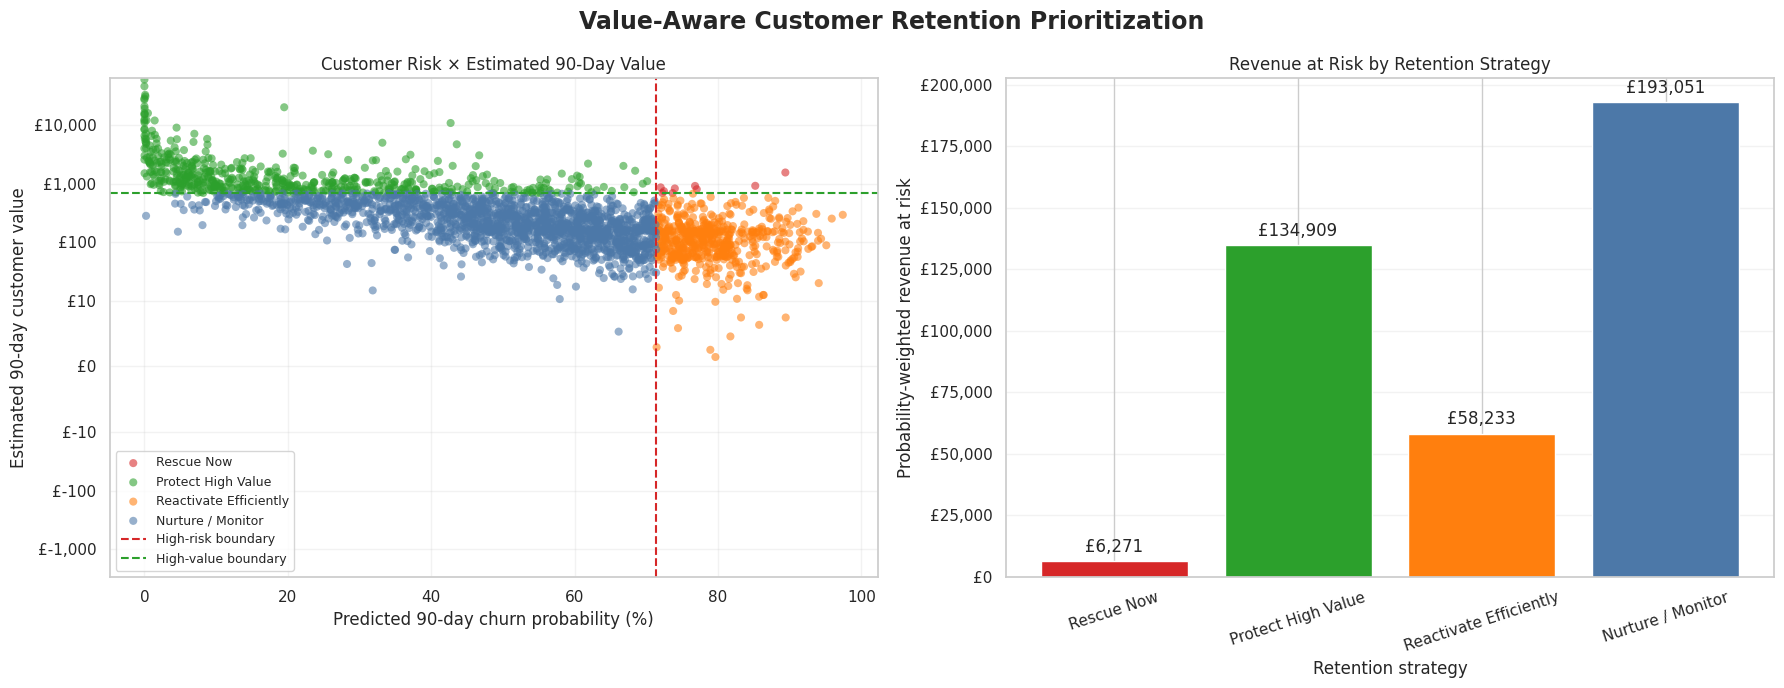

In [50]:
# ============================================================
# VALUE-AWARE RETENTION PRIORITIZATION
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

HIGH_RISK_PERCENTILE = 80
HIGH_VALUE_PERCENTILE = 80

# ------------------------------------------------------------
# 1. Create risk and value dimensions
# ------------------------------------------------------------

latest_customer_scores["value_percentile"] = (
    latest_customer_scores["estimated_90d_customer_value"]
    .rank(method="average", pct=True)
    .mul(100)
)

latest_customer_scores["high_risk_flag"] = (
    latest_customer_scores["risk_percentile"] >= HIGH_RISK_PERCENTILE
).astype(int)

latest_customer_scores["high_value_flag"] = (
    latest_customer_scores["value_percentile"] >= HIGH_VALUE_PERCENTILE
).astype(int)

high_risk_probability_cutoff = latest_customer_scores.loc[
    latest_customer_scores["high_risk_flag"] == 1,
    "churn_probability"
].min()

high_value_cutoff = latest_customer_scores.loc[
    latest_customer_scores["high_value_flag"] == 1,
    "estimated_90d_customer_value"
].min()

# ------------------------------------------------------------
# 2. Assign the four retention strategies
# ------------------------------------------------------------

strategy_conditions = [
    (
        (latest_customer_scores["high_risk_flag"] == 1) &
        (latest_customer_scores["high_value_flag"] == 1)
    ),
    (
        (latest_customer_scores["high_risk_flag"] == 0) &
        (latest_customer_scores["high_value_flag"] == 1)
    ),
    (
        (latest_customer_scores["high_risk_flag"] == 1) &
        (latest_customer_scores["high_value_flag"] == 0)
    )
]

strategy_names = [
    "Rescue Now",
    "Protect High Value",
    "Reactivate Efficiently"
]

latest_customer_scores["retention_strategy"] = np.select(
    strategy_conditions,
    strategy_names,
    default="Nurture / Monitor"
)

strategy_priority_map = {
    "Rescue Now": 1,
    "Protect High Value": 2,
    "Reactivate Efficiently": 3,
    "Nurture / Monitor": 4
}

strategy_action_map = {
    "Rescue Now":
        "Priority personal outreach, tailored incentive, and rapid follow-up",

    "Protect High Value":
        "Proactive loyalty or VIP service without aggressive discounting",

    "Reactivate Efficiently":
        "Automated re-engagement with targeted product recommendations",

    "Nurture / Monitor":
        "Low-cost nurture communication and continued monitoring"
}

latest_customer_scores["strategy_priority"] = (
    latest_customer_scores["retention_strategy"]
    .map(strategy_priority_map)
)

latest_customer_scores["value_aware_action"] = (
    latest_customer_scores["retention_strategy"]
    .map(strategy_action_map)
)

# ------------------------------------------------------------
# 3. Create strategy-level business summary
# ------------------------------------------------------------

strategy_order = [
    "Rescue Now",
    "Protect High Value",
    "Reactivate Efficiently",
    "Nurture / Monitor"
]

total_customers = len(latest_customer_scores)
total_actual_churners = latest_customer_scores["actual_churn"].sum()
total_estimated_value = (
    latest_customer_scores["estimated_90d_customer_value"].sum()
)
total_revenue_at_risk = latest_customer_scores["revenue_at_risk"].sum()

strategy_summary = (
    latest_customer_scores
    .groupby("retention_strategy")
    .agg(
        Customers=("customer_id", "size"),
        Actual_Churners=("actual_churn", "sum"),
        Average_Predicted_Risk=("churn_probability", "mean"),
        Estimated_90d_Value=("estimated_90d_customer_value", "sum"),
        Revenue_At_Risk=("revenue_at_risk", "sum")
    )
    .reindex(strategy_order)
    .reset_index()
)

strategy_summary["Customer_Share_Percent"] = (
    strategy_summary["Customers"] / total_customers * 100
)

strategy_summary["Churn_Rate_Percent"] = (
    strategy_summary["Actual_Churners"]
    / strategy_summary["Customers"] * 100
)

strategy_summary["Average_Predicted_Risk_Percent"] = (
    strategy_summary["Average_Predicted_Risk"] * 100
)

strategy_summary["Churner_Capture_Percent"] = (
    strategy_summary["Actual_Churners"]
    / total_actual_churners * 100
)

strategy_summary["Revenue_At_Risk_Share_Percent"] = (
    strategy_summary["Revenue_At_Risk"]
    / total_revenue_at_risk * 100
)

strategy_summary = strategy_summary[
    [
        "retention_strategy",
        "Customers",
        "Customer_Share_Percent",
        "Actual_Churners",
        "Churn_Rate_Percent",
        "Average_Predicted_Risk_Percent",
        "Churner_Capture_Percent",
        "Estimated_90d_Value",
        "Revenue_At_Risk",
        "Revenue_At_Risk_Share_Percent"
    ]
]

# ------------------------------------------------------------
# 4. Create customer-level action priority table
# ------------------------------------------------------------

value_aware_priority_table = (
    latest_customer_scores[
        [
            "customer_id",
            "snapshot_date",
            "latest_country",
            "churn_probability",
            "risk_percentile",
            "value_percentile",
            "risk_tier",
            "retention_strategy",
            "recency_days",
            "orders_180d",
            "activity_span_180d",
            "estimated_90d_customer_value",
            "revenue_at_risk",
            "value_aware_action",
            "actual_churn",
            "strategy_priority"
        ]
    ]
    .sort_values(
        ["strategy_priority", "revenue_at_risk"],
        ascending=[True, False]
    )
    .reset_index(drop=True)
)

value_aware_priority_table.insert(
    0,
    "priority_rank",
    np.arange(1, len(value_aware_priority_table) + 1)
)

value_aware_priority_table = value_aware_priority_table.drop(
    columns="strategy_priority"
)

# ------------------------------------------------------------
# 5. Validation
# ------------------------------------------------------------

expected_strategy = np.select(
    strategy_conditions,
    strategy_names,
    default="Nurture / Monitor"
)

validation_records = [
    {
        "Validation Check": "Duplicate customer rows",
        "Issues Found": int(
            latest_customer_scores["customer_id"].duplicated().sum()
        ),
        "Expected": 0
    },
    {
        "Validation Check": "Missing retention strategies",
        "Issues Found": int(
            latest_customer_scores["retention_strategy"].isna().sum()
        ),
        "Expected": 0
    },
    {
        "Validation Check": "Missing value-aware actions",
        "Issues Found": int(
            latest_customer_scores["value_aware_action"].isna().sum()
        ),
        "Expected": 0
    },
    {
        "Validation Check": "Incorrect strategy assignments",
        "Issues Found": int(
            (
                latest_customer_scores["retention_strategy"]
                != expected_strategy
            ).sum()
        ),
        "Expected": 0
    },
    {
        "Validation Check": "Customer-count mismatch",
        "Issues Found": int(
            strategy_summary["Customers"].sum() != total_customers
        ),
        "Expected": 0
    },
    {
        "Validation Check": "Estimated-value reconciliation mismatch",
        "Issues Found": int(
            not np.isclose(
                strategy_summary["Estimated_90d_Value"].sum(),
                total_estimated_value,
                atol=0.01
            )
        ),
        "Expected": 0
    },
    {
        "Validation Check": "Revenue-at-risk reconciliation mismatch",
        "Issues Found": int(
            not np.isclose(
                strategy_summary["Revenue_At_Risk"].sum(),
                total_revenue_at_risk,
                atol=0.01
            )
        ),
        "Expected": 0
    }
]

risk_value_validation = pd.DataFrame(validation_records)

risk_value_validation["Status"] = np.where(
    risk_value_validation["Issues Found"]
    == risk_value_validation["Expected"],
    "PASS",
    "CHECK"
)

# ------------------------------------------------------------
# 6. Display results
# ------------------------------------------------------------

print(f"Latest operational snapshot: {LATEST_OPERATIONAL_SNAPSHOT.date()}")
print(f"High-risk percentile threshold: {HIGH_RISK_PERCENTILE}%")
print(
    "Corresponding churn-probability cutoff: "
    f"{high_risk_probability_cutoff:.3f}"
)
print(f"High-value percentile threshold: {HIGH_VALUE_PERCENTILE}%")
print(f"Corresponding customer-value cutoff: £{high_value_cutoff:,.2f}")

print("\nValue-aware retention strategy summary:")

display(
    strategy_summary.round(
        {
            "Customer_Share_Percent": 2,
            "Churn_Rate_Percent": 2,
            "Average_Predicted_Risk_Percent": 2,
            "Churner_Capture_Percent": 2,
            "Estimated_90d_Value": 2,
            "Revenue_At_Risk": 2,
            "Revenue_At_Risk_Share_Percent": 2
        }
    )
)

print("\nHighest-priority customers under the risk-value strategy:")

display(
    value_aware_priority_table.head(20).round(
        {
            "churn_probability": 3,
            "risk_percentile": 3,
            "value_percentile": 3,
            "recency_days": 3,
            "activity_span_180d": 3,
            "estimated_90d_customer_value": 2,
            "revenue_at_risk": 2
        }
    )
)

print("\nRisk-value strategy validation:")
display(risk_value_validation)

# ------------------------------------------------------------
# 7. Visualize risk and value together
# ------------------------------------------------------------

strategy_colors = {
    "Rescue Now": "#d62728",
    "Protect High Value": "#2ca02c",
    "Reactivate Efficiently": "#ff7f0e",
    "Nurture / Monitor": "#4c78a8"
}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Risk-value scatter plot
for strategy in strategy_order:
    strategy_data = latest_customer_scores[
        latest_customer_scores["retention_strategy"] == strategy
    ]

    axes[0].scatter(
        strategy_data["churn_probability"] * 100,
        strategy_data["estimated_90d_customer_value"],
        label=strategy,
        color=strategy_colors[strategy],
        alpha=0.58,
        s=34,
        edgecolor="none"
    )

axes[0].axvline(
    high_risk_probability_cutoff * 100,
    color="#d62728",
    linestyle="--",
    linewidth=1.5,
    label="High-risk boundary"
)

axes[0].axhline(
    high_value_cutoff,
    color="#2ca02c",
    linestyle="--",
    linewidth=1.5,
    label="High-value boundary"
)

axes[0].set_yscale("symlog", linthresh=10)
axes[0].yaxis.set_major_formatter(
    FuncFormatter(lambda value, _: f"£{value:,.0f}")
)

axes[0].set_title("Customer Risk × Estimated 90-Day Value")
axes[0].set_xlabel("Predicted 90-day churn probability (%)")
axes[0].set_ylabel("Estimated 90-day customer value")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.25)

# Revenue-at-risk by strategy
bar_data = strategy_summary.copy()

bars = axes[1].bar(
    bar_data["retention_strategy"],
    bar_data["Revenue_At_Risk"],
    color=[
        strategy_colors[strategy]
        for strategy in bar_data["retention_strategy"]
    ]
)

axes[1].bar_label(
    bars,
    labels=[
        f"£{value:,.0f}"
        for value in bar_data["Revenue_At_Risk"]
    ],
    padding=4
)

axes[1].yaxis.set_major_formatter(
    FuncFormatter(lambda value, _: f"£{value:,.0f}")
)

axes[1].set_title("Revenue at Risk by Retention Strategy")
axes[1].set_xlabel("Retention strategy")
axes[1].set_ylabel("Probability-weighted revenue at risk")
axes[1].tick_params(axis="x", rotation=18)
axes[1].grid(axis="y", alpha=0.25)

fig.suptitle(
    "Value-Aware Customer Retention Prioritization",
    fontsize=17,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

### Risk–Value Strategy Findings

Only nine customers fall within both the highest-risk and highest-value groups, indicating that high customer value is generally associated with lower churn risk in this portfolio. Risk tiers measure churn likelihood, while the four strategies combine likelihood with financial exposure. The large exposure in Nurture / Monitor results mainly from its customer volume rather than high individual risk.


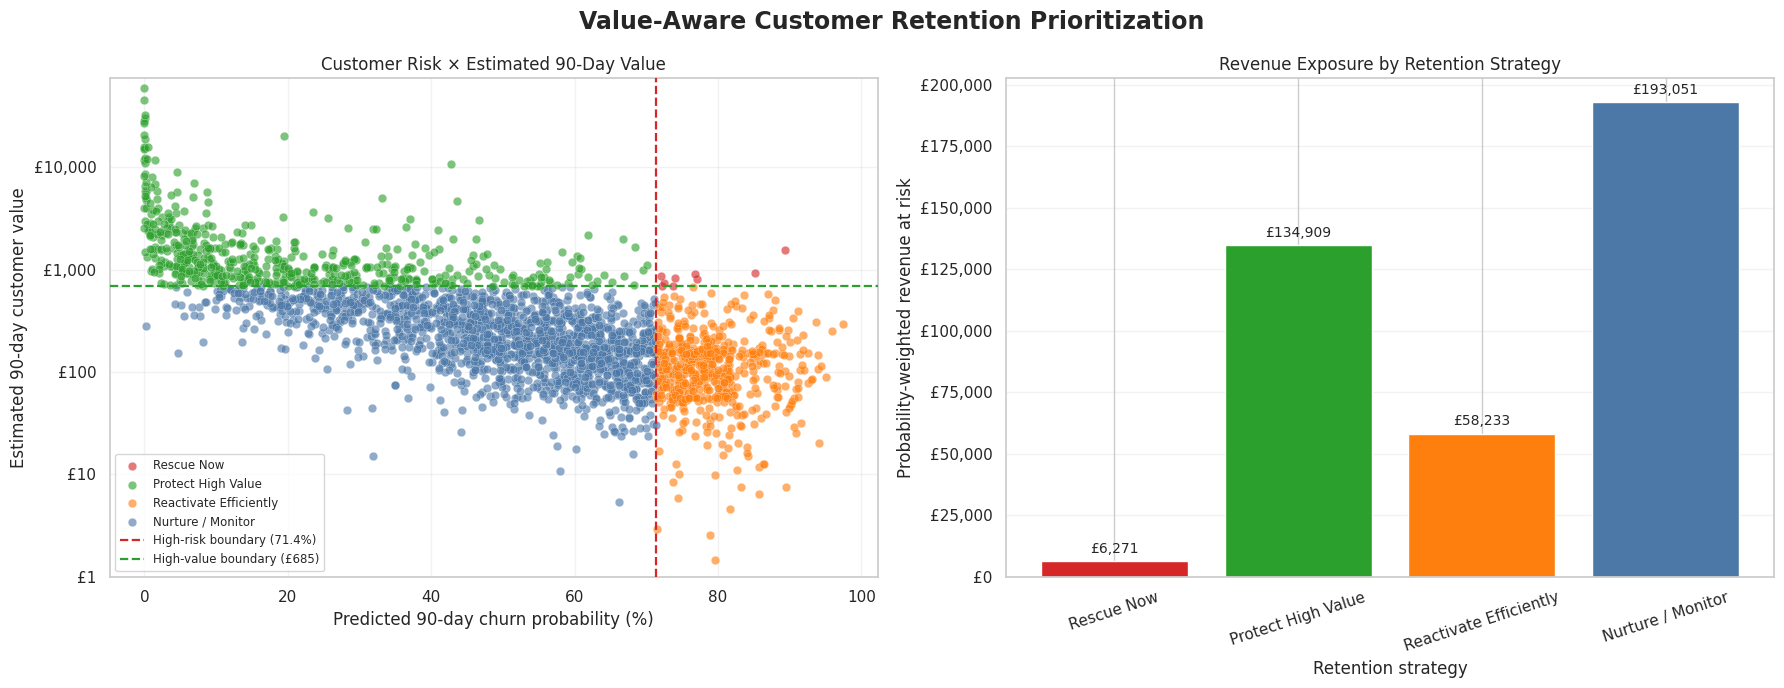

In [51]:
# ============================================================
# CORRECTED VALUE-AWARE RETENTION VISUALIZATION
# Removes negative currency ticks from the previous symlog axis
# ============================================================

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

strategy_colors = {
    "Rescue Now": "#d62728",
    "Protect High Value": "#2ca02c",
    "Reactivate Efficiently": "#ff7f0e",
    "Nurture / Monitor": "#4c78a8"
}

strategy_order = [
    "Rescue Now",
    "Protect High Value",
    "Reactivate Efficiently",
    "Nurture / Monitor"
]

strategy_priority_map = {
    "Rescue Now": 1,
    "Protect High Value": 2,
    "Reactivate Efficiently": 3,
    "Nurture / Monitor": 4
}

plot_data = latest_customer_scores.copy()

# Logarithmic axes cannot display zero, so values below £1 are
# displayed at £1 for visualization only. Original data is unchanged.
plot_data["plot_customer_value"] = (
    plot_data["estimated_90d_customer_value"].clip(lower=1)
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ------------------------------------------------------------
# 1. Risk × value portfolio
# ------------------------------------------------------------

for strategy in strategy_order:
    subset = plot_data[
        plot_data["retention_strategy"] == strategy
    ]

    axes[0].scatter(
        subset["churn_probability"] * 100,
        subset["plot_customer_value"],
        label=strategy,
        color=strategy_colors[strategy],
        alpha=0.62,
        s=38,
        edgecolor="white",
        linewidth=0.25,
        zorder=6 - strategy_priority_map[strategy]
    )

axes[0].axvline(
    high_risk_probability_cutoff * 100,
    color="#d62728",
    linestyle="--",
    linewidth=1.6,
    label=(
        "High-risk boundary "
        f"({high_risk_probability_cutoff:.1%})"
    ),
    zorder=7
)

axes[0].axhline(
    high_value_cutoff,
    color="#2ca02c",
    linestyle="--",
    linewidth=1.6,
    label=f"High-value boundary (£{high_value_cutoff:,.0f})",
    zorder=7
)

# Standard log scale prevents negative currency tick labels
axes[0].set_yscale("log")
axes[0].set_ylim(
    1,
    plot_data["plot_customer_value"].max() * 1.25
)

axes[0].yaxis.set_major_formatter(
    FuncFormatter(lambda value, _: f"£{value:,.0f}")
)

axes[0].set_title("Customer Risk × Estimated 90-Day Value")
axes[0].set_xlabel("Predicted 90-day churn probability (%)")
axes[0].set_ylabel("Estimated 90-day customer value")
axes[0].grid(alpha=0.25, which="major")
axes[0].legend(loc="lower left", fontsize=8.5)

# ------------------------------------------------------------
# 2. Revenue at risk by strategy
# ------------------------------------------------------------

bar_data = (
    strategy_summary
    .set_index("retention_strategy")
    .reindex(strategy_order)
    .reset_index()
)

bars = axes[1].bar(
    bar_data["retention_strategy"],
    bar_data["Revenue_At_Risk"],
    color=[
        strategy_colors[strategy]
        for strategy in bar_data["retention_strategy"]
    ],
    edgecolor="white"
)

axes[1].bar_label(
    bars,
    labels=[
        f"£{value:,.0f}"
        for value in bar_data["Revenue_At_Risk"]
    ],
    padding=4,
    fontsize=10
)

axes[1].yaxis.set_major_formatter(
    FuncFormatter(lambda value, _: f"£{value:,.0f}")
)

axes[1].set_title("Revenue Exposure by Retention Strategy")
axes[1].set_xlabel("Retention strategy")
axes[1].set_ylabel("Probability-weighted revenue at risk")
axes[1].tick_params(axis="x", rotation=18)
axes[1].grid(axis="y", alpha=0.25)
axes[1].set_axisbelow(True)

fig.suptitle(
    "Value-Aware Customer Retention Prioritization",
    fontsize=17,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

### Campaign Economics and Expected Net Benefit

Because historical campaign-response data is unavailable, retention uplift cannot be estimated causally. This analysis uses transparent and editable planning assumptions to estimate recoverable revenue, campaign cost, expected net benefit, return on investment, and the minimum uplift required to break even. These are scenario estimates rather than measured campaign outcomes.


Campaign economics scenario completed.
These results use planning assumptions, not measured uplift.
Recommended customers: 2,449
Estimated campaign cost: £7,307.00
Expected preserved revenue: £25,308.46
Expected net benefit: £18,001.46
Expected portfolio ROI: 246.36%

Campaign assumptions:


,retention_strategy,campaign_channel,assumed_risk_reduction_percent,campaign_cost_per_customer
0,Rescue Now,Personal outreach,25.0,50.0
1,Protect High Value,VIP or loyalty service,8.0,12.0
2,Reactivate Efficiently,Automated targeted campaign,15.0,5.0
3,Nurture / Monitor,Low-cost digital nurture,3.0,0.5



Strategy-level campaign business case:


,retention_strategy,Candidate_Customers,Recommended_Customers,Campaign_Coverage_Percent,Assumed_Risk_Reduction_Percent,Break_Even_Risk_Reduction_Percent,Cost_Per_Customer,Targeted_Revenue_At_Risk,Campaign_Cost,Expected_Preserved_Revenue,Expected_Net_Benefit,Expected_ROI_Percent
0,Rescue Now,9,9,100.00,25.0,7.18,50.0,6271.45,450.0,1567.86,1117.86,248.41
1,Protect High Value,545,300,55.05,8.0,3.07,12.0,117350.45,3600.0,9388.04,5788.04,160.78
2,Reactivate Efficiently,545,486,89.17,15.0,4.26,5.0,57104.41,2430.0,8565.66,6135.66,252.50
3,Nurture / Monitor,1669,1654,99.10,3.0,0.43,0.5,192896.63,827.0,5786.90,4959.90,599.75



Top customers ranked by expected net benefit:


,economic_priority_rank,customer_id,snapshot_date,latest_country,retention_strategy,campaign_channel,churn_probability,risk_tier,estimated_90d_customer_value,revenue_at_risk,assumed_relative_risk_reduction,expected_preserved_revenue,expected_campaign_cost,expected_net_benefit,expected_roi,break_even_risk_reduction,value_aware_action,actual_churn,cumulative_expected_net_benefit
0,1,15749,2011-09-01,United Kingdom,Protect High Value,VIP or loyalty service,0.427,Low,10767.95,4598.60,0.08,367.89,12.0,355.89,29.66,0.003,Proactive loyalty or VIP service without aggre...,1,355.89
1,2,15098,2011-09-01,United Kingdom,Protect High Value,VIP or loyalty service,0.195,Low,19958.25,3890.96,0.08,311.28,12.0,299.28,24.94,0.003,Proactive loyalty or VIP service without aggre...,1,655.17
2,3,13135,2011-09-01,United Kingdom,Rescue Now,Personal outreach,0.894,Critical,1548.00,1383.80,0.25,345.95,50.0,295.95,5.92,0.036,"Priority personal outreach, tailored incentive...",1,951.11
3,4,12590,2011-09-01,Germany,Protect High Value,VIP or loyalty service,0.436,Low,4670.63,2034.64,0.08,162.77,12.0,150.77,12.56,0.006,Proactive loyalty or VIP service without aggre...,1,1101.88
4,5,14459,2011-09-01,United Kingdom,Rescue Now,Personal outreach,0.852,Critical,918.96,782.91,0.25,195.73,50.0,145.73,2.91,0.064,"Priority personal outreach, tailored incentive...",1,1247.61
5,6,16152,2011-09-01,United Kingdom,Rescue Now,Personal outreach,0.768,High,914.52,702.34,0.25,175.59,50.0,125.59,2.51,0.071,"Priority personal outreach, tailored incentive...",1,1373.20
6,7,16333,2011-09-01,United Kingdom,Protect High Value,VIP or loyalty service,0.332,Low,4970.12,1649.53,0.08,131.96,12.0,119.96,10.00,0.007,Proactive loyalty or VIP service without aggre...,0,1493.16
7,8,18173,2011-09-01,United Kingdom,Rescue Now,Personal outreach,0.720,High,864.42,622.44,0.25,155.61,50.0,105.61,2.11,0.080,"Priority personal outreach, tailored incentive...",0,1598.77
8,9,12798,2011-09-01,Japan,Rescue Now,Personal outreach,0.770,High,803.52,618.99,0.25,154.75,50.0,104.75,2.09,0.081,"Priority personal outreach, tailored incentive...",0,1703.52
9,10,13344,2011-09-01,United Kingdom,Rescue Now,Personal outreach,0.740,High,828.08,612.59,0.25,153.15,50.0,103.15,2.06,0.082,"Priority personal outreach, tailored incentive...",0,1806.66



Campaign economics validation:


,Validation Check,Issues Found,Expected,Status
0,Missing strategy assumptions,0,0,PASS
1,Negative campaign costs,0,0,PASS
2,Risk-reduction assumptions outside 0–1,0,0,PASS
3,Preserved revenue exceeds revenue at risk,0,0,PASS
4,Net-benefit formula mismatch,0,0,PASS
5,Targeted customers with non-positive benefit,0,0,PASS
6,Campaign-cost reconciliation mismatch,0,0,PASS
7,Net-benefit reconciliation mismatch,0,0,PASS


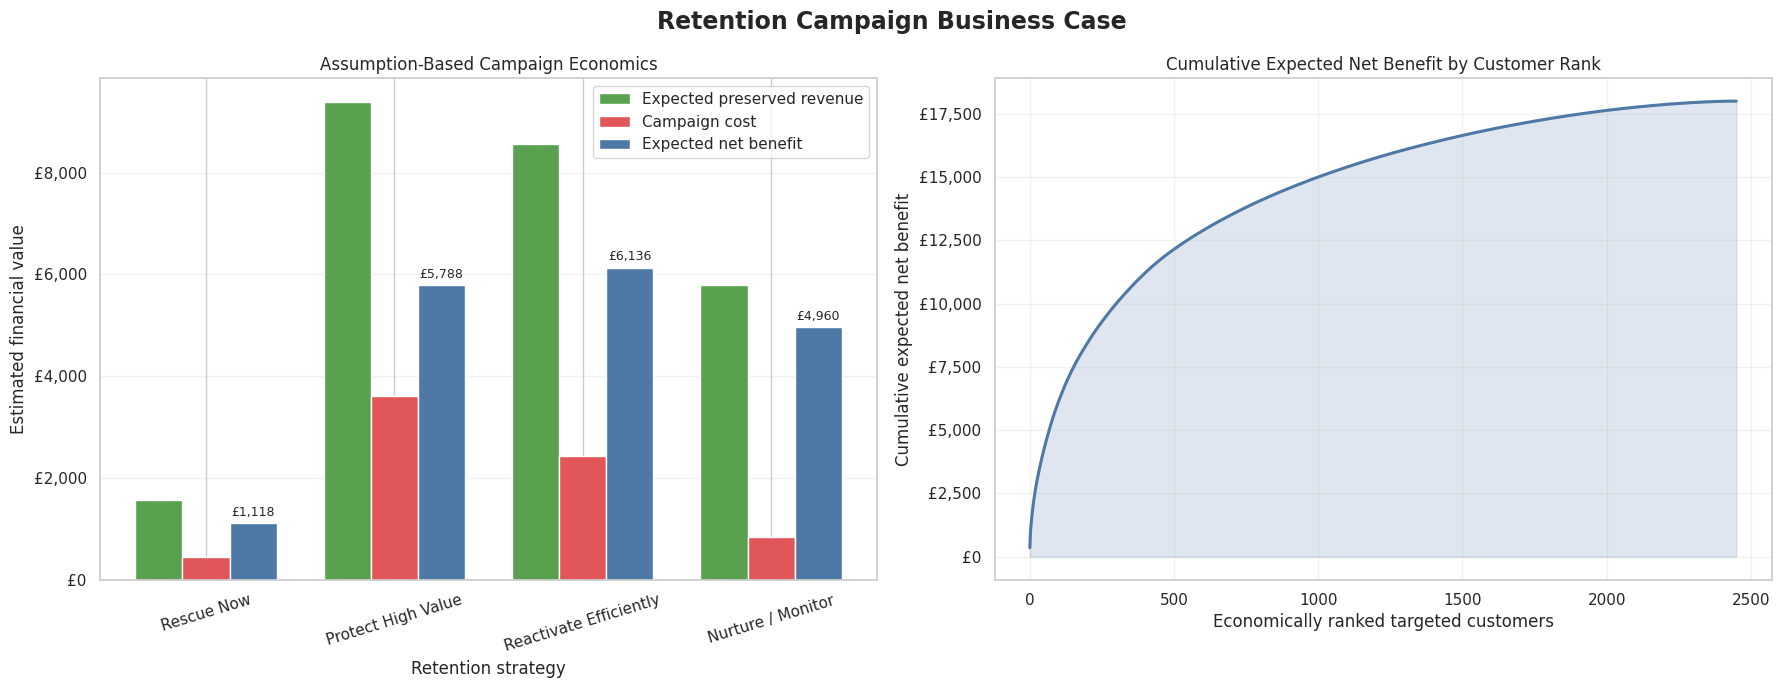

In [52]:
# ============================================================
# CAMPAIGN ECONOMICS AND EXPECTED NET-BENEFIT ANALYSIS
# Assumption-based planning scenario — not a causal estimate
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# ------------------------------------------------------------
# 1. Define transparent and editable campaign assumptions
#
# Assumed risk reduction represents the percentage of each
# customer's probability-weighted revenue at risk expected
# to be preserved by the intervention.
# ------------------------------------------------------------

campaign_assumptions = pd.DataFrame(
    {
        "retention_strategy": [
            "Rescue Now",
            "Protect High Value",
            "Reactivate Efficiently",
            "Nurture / Monitor"
        ],
        "campaign_channel": [
            "Personal outreach",
            "VIP or loyalty service",
            "Automated targeted campaign",
            "Low-cost digital nurture"
        ],
        "assumed_relative_risk_reduction": [
            0.25,
            0.08,
            0.15,
            0.03
        ],
        "campaign_cost_per_customer": [
            50.00,
            12.00,
            5.00,
            0.50
        ]
    }
)

strategy_order = [
    "Rescue Now",
    "Protect High Value",
    "Reactivate Efficiently",
    "Nurture / Monitor"
]

strategy_colors = {
    "Rescue Now": "#d62728",
    "Protect High Value": "#2ca02c",
    "Reactivate Efficiently": "#ff7f0e",
    "Nurture / Monitor": "#4c78a8"
}

# ------------------------------------------------------------
# 2. Merge assumptions with customer-level scoring results
# ------------------------------------------------------------

campaign_economics = latest_customer_scores.merge(
    campaign_assumptions,
    on="retention_strategy",
    how="left",
    validate="many_to_one"
)

# ------------------------------------------------------------
# 3. Calculate customer-level campaign economics
# ------------------------------------------------------------

campaign_economics["expected_preserved_revenue"] = (
    campaign_economics["revenue_at_risk"]
    * campaign_economics["assumed_relative_risk_reduction"]
)

campaign_economics["expected_campaign_cost"] = (
    campaign_economics["campaign_cost_per_customer"]
)

campaign_economics["expected_net_benefit"] = (
    campaign_economics["expected_preserved_revenue"]
    - campaign_economics["expected_campaign_cost"]
)

campaign_economics["expected_roi"] = np.where(
    campaign_economics["expected_campaign_cost"] > 0,
    campaign_economics["expected_net_benefit"]
    / campaign_economics["expected_campaign_cost"],
    np.nan
)

campaign_economics["break_even_risk_reduction"] = np.where(
    campaign_economics["revenue_at_risk"] > 0,
    campaign_economics["expected_campaign_cost"]
    / campaign_economics["revenue_at_risk"],
    np.inf
)

# Recommend intervention only where expected net benefit is positive
campaign_economics["campaign_recommended"] = (
    campaign_economics["expected_net_benefit"] > 0
)

campaign_economics["campaign_decision"] = np.where(
    campaign_economics["campaign_recommended"],
    "Target",
    "Do not target"
)

# Economics of the recommended campaign only
campaign_economics["recommended_campaign_cost"] = np.where(
    campaign_economics["campaign_recommended"],
    campaign_economics["expected_campaign_cost"],
    0.0
)

campaign_economics["recommended_preserved_revenue"] = np.where(
    campaign_economics["campaign_recommended"],
    campaign_economics["expected_preserved_revenue"],
    0.0
)

campaign_economics["recommended_net_benefit"] = np.where(
    campaign_economics["campaign_recommended"],
    campaign_economics["expected_net_benefit"],
    0.0
)

campaign_economics["recommended_revenue_at_risk"] = np.where(
    campaign_economics["campaign_recommended"],
    campaign_economics["revenue_at_risk"],
    0.0
)

# ------------------------------------------------------------
# 4. Strategy-level campaign business case
# ------------------------------------------------------------

campaign_strategy_summary = (
    campaign_economics
    .groupby("retention_strategy")
    .agg(
        Candidate_Customers=("customer_id", "size"),
        Recommended_Customers=("campaign_recommended", "sum"),
        Assumed_Risk_Reduction=(
            "assumed_relative_risk_reduction",
            "first"
        ),
        Cost_Per_Customer=("campaign_cost_per_customer", "first"),
        Total_Revenue_At_Risk=("revenue_at_risk", "sum"),
        Targeted_Revenue_At_Risk=("recommended_revenue_at_risk", "sum"),
        Campaign_Cost=("recommended_campaign_cost", "sum"),
        Expected_Preserved_Revenue=(
            "recommended_preserved_revenue",
            "sum"
        ),
        Expected_Net_Benefit=("recommended_net_benefit", "sum")
    )
    .reindex(strategy_order)
    .reset_index()
)

campaign_strategy_summary["Campaign_Coverage_Percent"] = (
    campaign_strategy_summary["Recommended_Customers"]
    / campaign_strategy_summary["Candidate_Customers"]
    * 100
)

campaign_strategy_summary["Assumed_Risk_Reduction_Percent"] = (
    campaign_strategy_summary["Assumed_Risk_Reduction"] * 100
)

campaign_strategy_summary["Expected_ROI_Percent"] = np.where(
    campaign_strategy_summary["Campaign_Cost"] > 0,
    campaign_strategy_summary["Expected_Net_Benefit"]
    / campaign_strategy_summary["Campaign_Cost"]
    * 100,
    np.nan
)

campaign_strategy_summary["Break_Even_Risk_Reduction_Percent"] = np.where(
    campaign_strategy_summary["Targeted_Revenue_At_Risk"] > 0,
    campaign_strategy_summary["Campaign_Cost"]
    / campaign_strategy_summary["Targeted_Revenue_At_Risk"]
    * 100,
    np.nan
)

campaign_strategy_summary = campaign_strategy_summary[
    [
        "retention_strategy",
        "Candidate_Customers",
        "Recommended_Customers",
        "Campaign_Coverage_Percent",
        "Assumed_Risk_Reduction_Percent",
        "Break_Even_Risk_Reduction_Percent",
        "Cost_Per_Customer",
        "Targeted_Revenue_At_Risk",
        "Campaign_Cost",
        "Expected_Preserved_Revenue",
        "Expected_Net_Benefit",
        "Expected_ROI_Percent"
    ]
]

# ------------------------------------------------------------
# 5. Create economically ranked customer action list
# ------------------------------------------------------------

campaign_priority_table = (
    campaign_economics.loc[
        campaign_economics["campaign_recommended"],
        [
            "customer_id",
            "snapshot_date",
            "latest_country",
            "retention_strategy",
            "campaign_channel",
            "churn_probability",
            "risk_tier",
            "estimated_90d_customer_value",
            "revenue_at_risk",
            "assumed_relative_risk_reduction",
            "expected_preserved_revenue",
            "expected_campaign_cost",
            "expected_net_benefit",
            "expected_roi",
            "break_even_risk_reduction",
            "value_aware_action",
            "actual_churn"
        ]
    ]
    .sort_values(
        "expected_net_benefit",
        ascending=False
    )
    .reset_index(drop=True)
)

campaign_priority_table.insert(
    0,
    "economic_priority_rank",
    np.arange(1, len(campaign_priority_table) + 1)
)

campaign_priority_table["cumulative_expected_net_benefit"] = (
    campaign_priority_table["expected_net_benefit"].cumsum()
)

# ------------------------------------------------------------
# 6. Portfolio-level totals
# ------------------------------------------------------------

total_recommended_customers = int(
    campaign_economics["campaign_recommended"].sum()
)

total_campaign_cost = (
    campaign_economics["recommended_campaign_cost"].sum()
)

total_expected_preserved_revenue = (
    campaign_economics["recommended_preserved_revenue"].sum()
)

total_expected_net_benefit = (
    campaign_economics["recommended_net_benefit"].sum()
)

portfolio_expected_roi = (
    total_expected_net_benefit / total_campaign_cost * 100
    if total_campaign_cost > 0
    else np.nan
)

# ------------------------------------------------------------
# 7. Validation
# ------------------------------------------------------------

campaign_validation_records = [
    {
        "Validation Check": "Missing strategy assumptions",
        "Issues Found": int(
            campaign_economics[
                "assumed_relative_risk_reduction"
            ].isna().sum()
        ),
        "Expected": 0
    },
    {
        "Validation Check": "Negative campaign costs",
        "Issues Found": int(
            (
                campaign_economics["expected_campaign_cost"] < 0
            ).sum()
        ),
        "Expected": 0
    },
    {
        "Validation Check": "Risk-reduction assumptions outside 0–1",
        "Issues Found": int(
            (
                ~campaign_economics[
                    "assumed_relative_risk_reduction"
                ].between(0, 1)
            ).sum()
        ),
        "Expected": 0
    },
    {
        "Validation Check": "Preserved revenue exceeds revenue at risk",
        "Issues Found": int(
            (
                campaign_economics["expected_preserved_revenue"]
                >
                campaign_economics["revenue_at_risk"] + 1e-9
            ).sum()
        ),
        "Expected": 0
    },
    {
        "Validation Check": "Net-benefit formula mismatch",
        "Issues Found": int(
            (
                np.abs(
                    campaign_economics["expected_net_benefit"]
                    - (
                        campaign_economics[
                            "expected_preserved_revenue"
                        ]
                        - campaign_economics[
                            "expected_campaign_cost"
                        ]
                    )
                ) > 1e-9
            ).sum()
        ),
        "Expected": 0
    },
    {
        "Validation Check": "Targeted customers with non-positive benefit",
        "Issues Found": int(
            (
                campaign_economics["campaign_recommended"]
                & (
                    campaign_economics["expected_net_benefit"] <= 0
                )
            ).sum()
        ),
        "Expected": 0
    },
    {
        "Validation Check": "Campaign-cost reconciliation mismatch",
        "Issues Found": int(
            not np.isclose(
                campaign_strategy_summary["Campaign_Cost"].sum(),
                total_campaign_cost,
                atol=0.01
            )
        ),
        "Expected": 0
    },
    {
        "Validation Check": "Net-benefit reconciliation mismatch",
        "Issues Found": int(
            not np.isclose(
                campaign_strategy_summary[
                    "Expected_Net_Benefit"
                ].sum(),
                total_expected_net_benefit,
                atol=0.01
            )
        ),
        "Expected": 0
    }
]

campaign_economics_validation = pd.DataFrame(
    campaign_validation_records
)

campaign_economics_validation["Status"] = np.where(
    campaign_economics_validation["Issues Found"]
    == campaign_economics_validation["Expected"],
    "PASS",
    "CHECK"
)

# ------------------------------------------------------------
# 8. Display results
# ------------------------------------------------------------

print("Campaign economics scenario completed.")
print("These results use planning assumptions, not measured uplift.")
print(f"Recommended customers: {total_recommended_customers:,}")
print(f"Estimated campaign cost: £{total_campaign_cost:,.2f}")
print(
    "Expected preserved revenue: "
    f"£{total_expected_preserved_revenue:,.2f}"
)
print(
    "Expected net benefit: "
    f"£{total_expected_net_benefit:,.2f}"
)
print(f"Expected portfolio ROI: {portfolio_expected_roi:,.2f}%")

print("\nCampaign assumptions:")
display(
    campaign_assumptions.assign(
        assumed_relative_risk_reduction=lambda frame:
            frame["assumed_relative_risk_reduction"] * 100
    ).rename(
        columns={
            "assumed_relative_risk_reduction":
                "assumed_risk_reduction_percent"
        }
    )
)

print("\nStrategy-level campaign business case:")
display(
    campaign_strategy_summary.round(
        {
            "Campaign_Coverage_Percent": 2,
            "Assumed_Risk_Reduction_Percent": 2,
            "Break_Even_Risk_Reduction_Percent": 2,
            "Cost_Per_Customer": 2,
            "Targeted_Revenue_At_Risk": 2,
            "Campaign_Cost": 2,
            "Expected_Preserved_Revenue": 2,
            "Expected_Net_Benefit": 2,
            "Expected_ROI_Percent": 2
        }
    )
)

print("\nTop customers ranked by expected net benefit:")
display(
    campaign_priority_table.head(20).round(
        {
            "churn_probability": 3,
            "estimated_90d_customer_value": 2,
            "revenue_at_risk": 2,
            "assumed_relative_risk_reduction": 3,
            "expected_preserved_revenue": 2,
            "expected_campaign_cost": 2,
            "expected_net_benefit": 2,
            "expected_roi": 2,
            "break_even_risk_reduction": 3,
            "cumulative_expected_net_benefit": 2
        }
    )
)

print("\nCampaign economics validation:")
display(campaign_economics_validation)

# ------------------------------------------------------------
# 9. Visualize strategy economics and cumulative benefit
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

x_positions = np.arange(len(campaign_strategy_summary))
bar_width = 0.25

preserved_bars = axes[0].bar(
    x_positions - bar_width,
    campaign_strategy_summary["Expected_Preserved_Revenue"],
    width=bar_width,
    label="Expected preserved revenue",
    color="#59a14f"
)

cost_bars = axes[0].bar(
    x_positions,
    campaign_strategy_summary["Campaign_Cost"],
    width=bar_width,
    label="Campaign cost",
    color="#e15759"
)

benefit_bars = axes[0].bar(
    x_positions + bar_width,
    campaign_strategy_summary["Expected_Net_Benefit"],
    width=bar_width,
    label="Expected net benefit",
    color="#4e79a7"
)

axes[0].set_xticks(
    x_positions,
    campaign_strategy_summary["retention_strategy"],
    rotation=17
)

axes[0].yaxis.set_major_formatter(
    FuncFormatter(lambda value, _: f"£{value:,.0f}")
)

axes[0].set_title("Assumption-Based Campaign Economics")
axes[0].set_xlabel("Retention strategy")
axes[0].set_ylabel("Estimated financial value")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.25)
axes[0].set_axisbelow(True)

axes[0].bar_label(
    benefit_bars,
    labels=[
        f"£{value:,.0f}"
        for value in campaign_strategy_summary[
            "Expected_Net_Benefit"
        ]
    ],
    padding=3,
    fontsize=9
)

axes[1].plot(
    campaign_priority_table["economic_priority_rank"],
    campaign_priority_table["cumulative_expected_net_benefit"],
    color="#4e79a7",
    linewidth=2.2
)

axes[1].fill_between(
    campaign_priority_table["economic_priority_rank"],
    campaign_priority_table["cumulative_expected_net_benefit"],
    color="#4e79a7",
    alpha=0.18
)

axes[1].yaxis.set_major_formatter(
    FuncFormatter(lambda value, _: f"£{value:,.0f}")
)

axes[1].set_title("Cumulative Expected Net Benefit by Customer Rank")
axes[1].set_xlabel("Economically ranked targeted customers")
axes[1].set_ylabel("Cumulative expected net benefit")
axes[1].grid(alpha=0.25)

fig.suptitle(
    "Retention Campaign Business Case",
    fontsize=17,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

### Budget and Campaign-Capacity Optimization

The unrestricted campaign targets 2,449 customers, but practical retention programs operate under financial and channel-capacity limits. The following analysis reserves capacity for urgent Rescue Now customers and then allocates the remaining budget to customers with the highest expected net benefit per pound. This is a transparent greedy allocation method based on planning assumptions, not an exact causal or mathematical-programming solution.


Capacity-aware campaign allocation completed.
Allocation method: Rescue Now reservation followed by highest expected net benefit per £1.

Operational capacity assumptions:


,retention_strategy,maximum_customer_capacity,capacity_reason
0,Rescue Now,9,Limited specialist outreach
1,Protect High Value,150,Limited VIP-service capacity
2,Reactivate Efficiently,400,Automated campaign limit
3,Nurture / Monitor,1000,Digital communication limit



Budget-scenario comparison:


,Budget,Selected_Customers,Campaign_Spend,Unused_Budget,Budget_Utilization_Percent,Selected_Revenue_At_Risk,Expected_Preserved_Revenue,Expected_Net_Benefit,Expected_ROI_Percent,Available_Net_Benefit_Captured_Percent,Available_Revenue_At_Risk_Covered_Percent,Incremental_Spend,Incremental_Net_Benefit,Marginal_Net_Benefit_Per_Pound
0,1000.0,606,1000.0,0.0,100.00,143249.46,8078.13,7078.13,707.81,39.32,38.34,1000.0,7078.13,7.08
1,2500.0,1250,2498.0,2.0,99.92,244497.63,15418.79,12920.79,517.25,71.78,65.44,1498.0,5842.66,3.90
2,5000.0,1559,4750.0,250.0,95.00,299955.30,21017.96,16267.96,342.48,90.37,80.28,2252.0,3347.17,1.49



Customer allocation by budget and strategy:


retention_strategy,Budget,Rescue Now,Protect High Value,Reactivate Efficiently,Nurture / Monitor
0,1000.0,9,7,38,552
1,2500.0,9,49,192,1000
2,5000.0,9,150,400,1000



Primary operating campaign: £2,500 budget
Selected customers: 1,250
Expected campaign spend: £2,498.00
Expected net benefit: £12,920.79

Top customers in the primary campaign:


,campaign_priority_rank,customer_id,snapshot_date,latest_country,retention_strategy,campaign_channel,churn_probability,risk_tier,estimated_90d_customer_value,revenue_at_risk,expected_campaign_cost,expected_preserved_revenue,expected_net_benefit,net_benefit_per_pound,cumulative_campaign_cost,cumulative_expected_net_benefit,value_aware_action,actual_churn
0,1,15749,2011-09-01,United Kingdom,Protect High Value,VIP or loyalty service,0.427,Low,10767.95,4598.60,12.0,367.89,355.89,29.66,12.0,355.89,Proactive loyalty or VIP service without aggre...,1
1,2,15098,2011-09-01,United Kingdom,Protect High Value,VIP or loyalty service,0.195,Low,19958.25,3890.96,12.0,311.28,299.28,24.94,24.0,655.17,Proactive loyalty or VIP service without aggre...,1
2,3,13135,2011-09-01,United Kingdom,Rescue Now,Personal outreach,0.894,Critical,1548.00,1383.80,50.0,345.95,295.95,5.92,74.0,951.11,"Priority personal outreach, tailored incentive...",1
3,4,12590,2011-09-01,Germany,Protect High Value,VIP or loyalty service,0.436,Low,4670.63,2034.64,12.0,162.77,150.77,12.56,86.0,1101.88,Proactive loyalty or VIP service without aggre...,1
4,5,14459,2011-09-01,United Kingdom,Rescue Now,Personal outreach,0.852,Critical,918.96,782.91,50.0,195.73,145.73,2.91,136.0,1247.61,"Priority personal outreach, tailored incentive...",1
5,6,16152,2011-09-01,United Kingdom,Rescue Now,Personal outreach,0.768,High,914.52,702.34,50.0,175.59,125.59,2.51,186.0,1373.20,"Priority personal outreach, tailored incentive...",1
6,7,16333,2011-09-01,United Kingdom,Protect High Value,VIP or loyalty service,0.332,Low,4970.12,1649.53,12.0,131.96,119.96,10.00,198.0,1493.16,Proactive loyalty or VIP service without aggre...,0
7,8,18173,2011-09-01,United Kingdom,Rescue Now,Personal outreach,0.720,High,864.42,622.44,50.0,155.61,105.61,2.11,248.0,1598.77,"Priority personal outreach, tailored incentive...",0
8,9,12798,2011-09-01,Japan,Rescue Now,Personal outreach,0.770,High,803.52,618.99,50.0,154.75,104.75,2.09,298.0,1703.52,"Priority personal outreach, tailored incentive...",0
9,10,13344,2011-09-01,United Kingdom,Rescue Now,Personal outreach,0.740,High,828.08,612.59,50.0,153.15,103.15,2.06,348.0,1806.66,"Priority personal outreach, tailored incentive...",0



Budget-optimization validation:


,Validation Check,Issues Found,Expected,Status
0,Budget overspend scenarios,0,0,PASS
1,Strategy-capacity violations,0,0,PASS
2,Duplicate customers within scenarios,0,0,PASS
3,Selected non-positive-benefit customers,0,0,PASS
4,Selected ineligible customers,0,0,PASS
5,Missing mandatory Rescue Now customers,0,0,PASS
6,Primary campaign exceeds budget,0,0,PASS


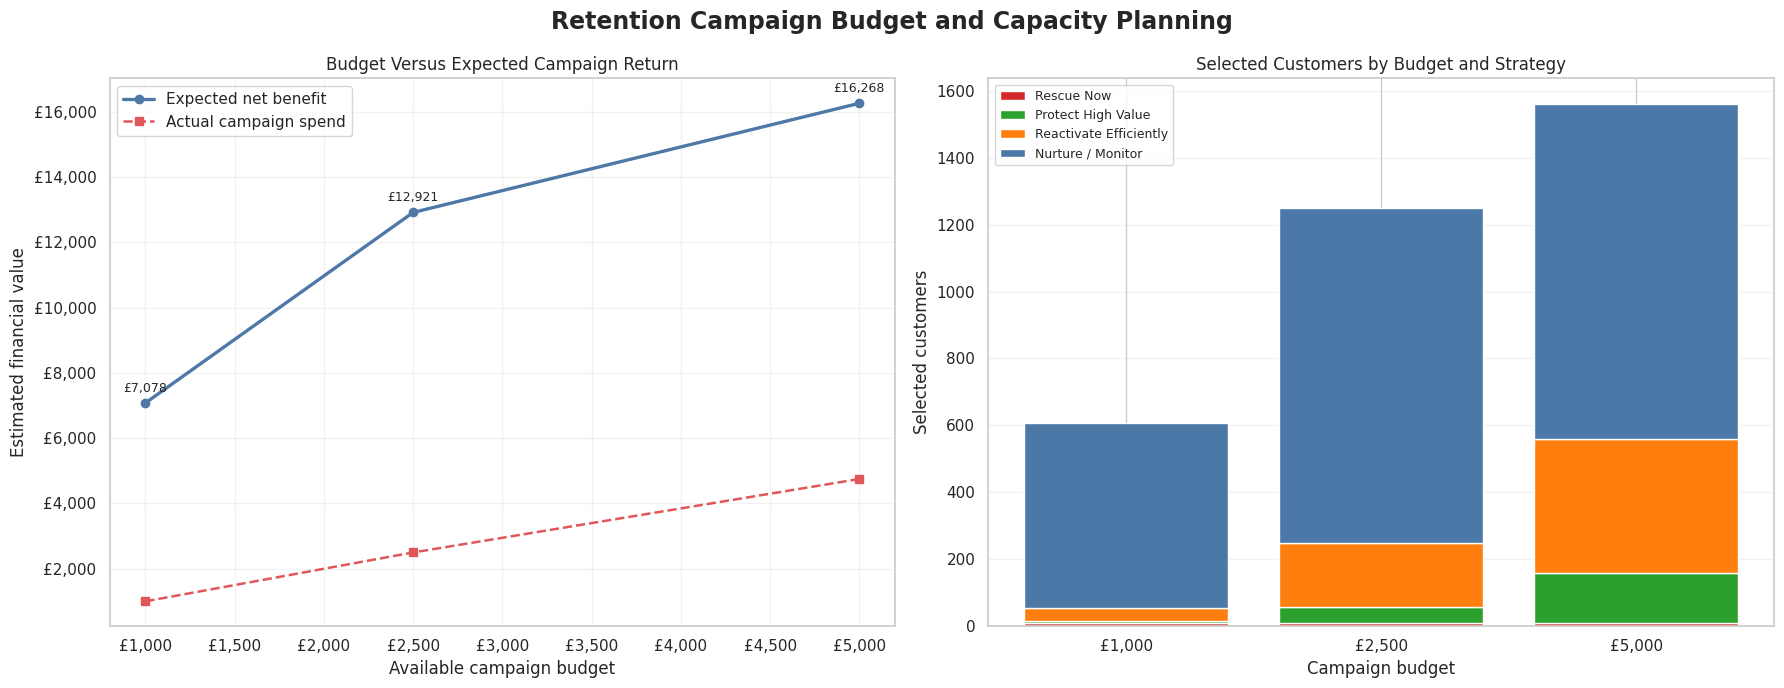

In [53]:
# ============================================================
# BUDGET AND CAMPAIGN-CAPACITY OPTIMIZATION
# Fast capacity-aware greedy allocation
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# ------------------------------------------------------------
# 1. Define budget scenarios and operational capacities
# ------------------------------------------------------------

CAMPAIGN_BUDGETS = [1000.0, 2500.0, 5000.0]
PRIMARY_OPERATING_BUDGET = 2500.0

capacity_plan = pd.DataFrame(
    {
        "retention_strategy": [
            "Rescue Now",
            "Protect High Value",
            "Reactivate Efficiently",
            "Nurture / Monitor"
        ],
        "maximum_customer_capacity": [
            9,      # Personal outreach capacity
            150,    # VIP/loyalty-service capacity
            400,    # Automated reactivation capacity
            1000    # Low-cost nurture capacity
        ],
        "capacity_reason": [
            "Limited specialist outreach",
            "Limited VIP-service capacity",
            "Automated campaign limit",
            "Digital communication limit"
        ]
    }
)

strategy_order = [
    "Rescue Now",
    "Protect High Value",
    "Reactivate Efficiently",
    "Nurture / Monitor"
]

strategy_colors = {
    "Rescue Now": "#d62728",
    "Protect High Value": "#2ca02c",
    "Reactivate Efficiently": "#ff7f0e",
    "Nurture / Monitor": "#4c78a8"
}

capacity_map = dict(
    zip(
        capacity_plan["retention_strategy"],
        capacity_plan["maximum_customer_capacity"]
    )
)

# ------------------------------------------------------------
# 2. Prepare the economically eligible customer pool
# ------------------------------------------------------------

allocation_candidates = campaign_economics.loc[
    campaign_economics["campaign_recommended"]
].copy()

allocation_candidates["net_benefit_per_pound"] = np.where(
    allocation_candidates["expected_campaign_cost"] > 0,
    allocation_candidates["expected_net_benefit"]
    / allocation_candidates["expected_campaign_cost"],
    0.0
)

allocation_candidates["_allocation_id"] = np.arange(
    len(allocation_candidates)
)

# ------------------------------------------------------------
# 3. Define capacity-aware greedy allocation function
#
# Rule:
# 1. Reserve budget for Rescue Now customers.
# 2. Rank remaining customers by expected net benefit per £1.
# 3. Select while respecting budget and channel capacities.
# ------------------------------------------------------------

def allocate_campaign_under_constraints(
    candidate_data,
    budget,
    strategy_capacities
):
    selected_ids = []
    remaining_budget = float(budget)

    capacity_used = {
        strategy: 0
        for strategy in strategy_capacities
    }

    def attempt_selection(selection_pool):
        nonlocal remaining_budget

        for _, customer in selection_pool.iterrows():
            strategy = customer["retention_strategy"]
            customer_cost = float(
                customer["expected_campaign_cost"]
            )

            capacity_available = (
                capacity_used[strategy]
                < strategy_capacities[strategy]
            )

            affordable = (
                customer_cost <= remaining_budget + 1e-9
            )

            if capacity_available and affordable:
                selected_ids.append(
                    int(customer["_allocation_id"])
                )

                capacity_used[strategy] += 1
                remaining_budget -= customer_cost

    # Mandatory first-stage allocation
    rescue_pool = (
        candidate_data[
            candidate_data["retention_strategy"]
            == "Rescue Now"
        ]
        .sort_values(
            "expected_net_benefit",
            ascending=False
        )
    )

    attempt_selection(rescue_pool)

    # Allocate remaining budget by benefit efficiency
    remaining_pool = (
        candidate_data[
            ~candidate_data["_allocation_id"].isin(
                selected_ids
            )
        ]
        .sort_values(
            [
                "net_benefit_per_pound",
                "expected_net_benefit"
            ],
            ascending=[False, False]
        )
    )

    attempt_selection(remaining_pool)

    selected_customers = candidate_data[
        candidate_data["_allocation_id"].isin(
            selected_ids
        )
    ].copy()

    selected_customers["allocation_budget"] = budget

    return selected_customers


# ------------------------------------------------------------
# 4. Run all budget scenarios
# ------------------------------------------------------------

scenario_allocations = {}
scenario_summary_records = []
strategy_allocation_records = []

total_available_net_benefit = (
    allocation_candidates["expected_net_benefit"].sum()
)

total_available_revenue_at_risk = (
    allocation_candidates["revenue_at_risk"].sum()
)

for budget in CAMPAIGN_BUDGETS:
    selected = allocate_campaign_under_constraints(
        allocation_candidates,
        budget,
        capacity_map
    )

    scenario_allocations[budget] = selected

    campaign_spend = selected[
        "expected_campaign_cost"
    ].sum()

    expected_preserved_revenue = selected[
        "expected_preserved_revenue"
    ].sum()

    expected_net_benefit = selected[
        "expected_net_benefit"
    ].sum()

    selected_revenue_at_risk = selected[
        "revenue_at_risk"
    ].sum()

    expected_roi = (
        expected_net_benefit / campaign_spend * 100
        if campaign_spend > 0
        else np.nan
    )

    scenario_summary_records.append(
        {
            "Budget": budget,
            "Selected_Customers": len(selected),
            "Campaign_Spend": campaign_spend,
            "Unused_Budget": budget - campaign_spend,
            "Budget_Utilization_Percent":
                campaign_spend / budget * 100,
            "Selected_Revenue_At_Risk":
                selected_revenue_at_risk,
            "Expected_Preserved_Revenue":
                expected_preserved_revenue,
            "Expected_Net_Benefit":
                expected_net_benefit,
            "Expected_ROI_Percent":
                expected_roi,
            "Available_Net_Benefit_Captured_Percent":
                expected_net_benefit
                / total_available_net_benefit * 100,
            "Available_Revenue_At_Risk_Covered_Percent":
                selected_revenue_at_risk
                / total_available_revenue_at_risk * 100
        }
    )

    strategy_counts = (
        selected["retention_strategy"]
        .value_counts()
        .reindex(strategy_order, fill_value=0)
    )

    for strategy in strategy_order:
        strategy_allocation_records.append(
            {
                "Budget": budget,
                "retention_strategy": strategy,
                "Selected_Customers":
                    int(strategy_counts[strategy])
            }
        )

budget_scenario_summary = (
    pd.DataFrame(scenario_summary_records)
    .sort_values("Budget")
    .reset_index(drop=True)
)

budget_strategy_allocation = pd.DataFrame(
    strategy_allocation_records
)

# ------------------------------------------------------------
# 5. Calculate marginal returns between budgets
# ------------------------------------------------------------

budget_scenario_summary[
    "Incremental_Spend"
] = budget_scenario_summary[
    "Campaign_Spend"
].diff()

budget_scenario_summary[
    "Incremental_Net_Benefit"
] = budget_scenario_summary[
    "Expected_Net_Benefit"
].diff()

budget_scenario_summary.loc[
    0, "Incremental_Spend"
] = budget_scenario_summary.loc[
    0, "Campaign_Spend"
]

budget_scenario_summary.loc[
    0, "Incremental_Net_Benefit"
] = budget_scenario_summary.loc[
    0, "Expected_Net_Benefit"
]

budget_scenario_summary[
    "Marginal_Net_Benefit_Per_Pound"
] = np.where(
    budget_scenario_summary["Incremental_Spend"] > 0,
    budget_scenario_summary["Incremental_Net_Benefit"]
    / budget_scenario_summary["Incremental_Spend"],
    np.nan
)

# ------------------------------------------------------------
# 6. Create primary operating campaign table
# ------------------------------------------------------------

primary_campaign_allocation = (
    scenario_allocations[PRIMARY_OPERATING_BUDGET]
    .sort_values(
        "expected_net_benefit",
        ascending=False
    )
    .reset_index(drop=True)
)

primary_campaign_allocation.insert(
    0,
    "campaign_priority_rank",
    np.arange(
        1,
        len(primary_campaign_allocation) + 1
    )
)

primary_campaign_allocation[
    "cumulative_campaign_cost"
] = primary_campaign_allocation[
    "expected_campaign_cost"
].cumsum()

primary_campaign_allocation[
    "cumulative_expected_net_benefit"
] = primary_campaign_allocation[
    "expected_net_benefit"
].cumsum()

primary_campaign_table = primary_campaign_allocation[
    [
        "campaign_priority_rank",
        "customer_id",
        "snapshot_date",
        "latest_country",
        "retention_strategy",
        "campaign_channel",
        "churn_probability",
        "risk_tier",
        "estimated_90d_customer_value",
        "revenue_at_risk",
        "expected_campaign_cost",
        "expected_preserved_revenue",
        "expected_net_benefit",
        "net_benefit_per_pound",
        "cumulative_campaign_cost",
        "cumulative_expected_net_benefit",
        "value_aware_action",
        "actual_churn"
    ]
].copy()

# ------------------------------------------------------------
# 7. Validation
# ------------------------------------------------------------

overspend_issues = 0
capacity_issues = 0
duplicate_issues = 0
nonpositive_benefit_issues = 0
nonrecommended_issues = 0
rescue_coverage_issues = 0

total_rescue_candidates = int(
    (
        allocation_candidates["retention_strategy"]
        == "Rescue Now"
    ).sum()
)

total_rescue_cost = (
    allocation_candidates.loc[
        allocation_candidates["retention_strategy"]
        == "Rescue Now",
        "expected_campaign_cost"
    ].sum()
)

for budget, selected in scenario_allocations.items():
    selected_spend = selected[
        "expected_campaign_cost"
    ].sum()

    overspend_issues += int(
        selected_spend > budget + 0.01
    )

    duplicate_issues += int(
        selected["customer_id"].duplicated().sum()
    )

    nonpositive_benefit_issues += int(
        (
            selected["expected_net_benefit"] <= 0
        ).sum()
    )

    nonrecommended_issues += int(
        (
            ~selected["campaign_recommended"]
        ).sum()
    )

    selected_counts = (
        selected["retention_strategy"]
        .value_counts()
    )

    for strategy, capacity in capacity_map.items():
        capacity_issues += int(
            selected_counts.get(strategy, 0) > capacity
        )

    # All Rescue Now customers should be selected whenever
    # the budget can cover their combined cost.
    if budget >= total_rescue_cost:
        selected_rescue_count = int(
            (
                selected["retention_strategy"]
                == "Rescue Now"
            ).sum()
        )

        rescue_coverage_issues += int(
            selected_rescue_count
            != min(
                total_rescue_candidates,
                capacity_map["Rescue Now"]
            )
        )

budget_validation_records = [
    {
        "Validation Check": "Budget overspend scenarios",
        "Issues Found": overspend_issues,
        "Expected": 0
    },
    {
        "Validation Check": "Strategy-capacity violations",
        "Issues Found": capacity_issues,
        "Expected": 0
    },
    {
        "Validation Check": "Duplicate customers within scenarios",
        "Issues Found": duplicate_issues,
        "Expected": 0
    },
    {
        "Validation Check": "Selected non-positive-benefit customers",
        "Issues Found": nonpositive_benefit_issues,
        "Expected": 0
    },
    {
        "Validation Check": "Selected ineligible customers",
        "Issues Found": nonrecommended_issues,
        "Expected": 0
    },
    {
        "Validation Check": "Missing mandatory Rescue Now customers",
        "Issues Found": rescue_coverage_issues,
        "Expected": 0
    },
    {
        "Validation Check": "Primary campaign exceeds budget",
        "Issues Found": int(
            primary_campaign_allocation[
                "expected_campaign_cost"
            ].sum()
            > PRIMARY_OPERATING_BUDGET + 0.01
        ),
        "Expected": 0
    }
]

budget_optimization_validation = pd.DataFrame(
    budget_validation_records
)

budget_optimization_validation["Status"] = np.where(
    budget_optimization_validation["Issues Found"]
    == budget_optimization_validation["Expected"],
    "PASS",
    "CHECK"
)

# ------------------------------------------------------------
# 8. Display results
# ------------------------------------------------------------

print("Capacity-aware campaign allocation completed.")
print(
    "Allocation method: Rescue Now reservation followed "
    "by highest expected net benefit per £1."
)

print("\nOperational capacity assumptions:")
display(capacity_plan)

print("\nBudget-scenario comparison:")
display(
    budget_scenario_summary.round(
        {
            "Campaign_Spend": 2,
            "Unused_Budget": 2,
            "Budget_Utilization_Percent": 2,
            "Selected_Revenue_At_Risk": 2,
            "Expected_Preserved_Revenue": 2,
            "Expected_Net_Benefit": 2,
            "Expected_ROI_Percent": 2,
            "Available_Net_Benefit_Captured_Percent": 2,
            "Available_Revenue_At_Risk_Covered_Percent": 2,
            "Incremental_Spend": 2,
            "Incremental_Net_Benefit": 2,
            "Marginal_Net_Benefit_Per_Pound": 2
        }
    )
)

print("\nCustomer allocation by budget and strategy:")

strategy_allocation_pivot = (
    budget_strategy_allocation
    .pivot(
        index="Budget",
        columns="retention_strategy",
        values="Selected_Customers"
    )
    .reindex(columns=strategy_order)
    .reset_index()
)

display(strategy_allocation_pivot)

print(
    f"\nPrimary operating campaign: "
    f"£{PRIMARY_OPERATING_BUDGET:,.0f} budget"
)

print(
    "Selected customers: "
    f"{len(primary_campaign_allocation):,}"
)

print(
    "Expected campaign spend: "
    f"£{primary_campaign_allocation['expected_campaign_cost'].sum():,.2f}"
)

print(
    "Expected net benefit: "
    f"£{primary_campaign_allocation['expected_net_benefit'].sum():,.2f}"
)

print("\nTop customers in the primary campaign:")

display(
    primary_campaign_table.head(20).round(
        {
            "churn_probability": 3,
            "estimated_90d_customer_value": 2,
            "revenue_at_risk": 2,
            "expected_campaign_cost": 2,
            "expected_preserved_revenue": 2,
            "expected_net_benefit": 2,
            "net_benefit_per_pound": 2,
            "cumulative_campaign_cost": 2,
            "cumulative_expected_net_benefit": 2
        }
    )
)

print("\nBudget-optimization validation:")
display(budget_optimization_validation)

# ------------------------------------------------------------
# 9. Visualize budget returns and strategy allocation
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Budget-benefit curve
axes[0].plot(
    budget_scenario_summary["Budget"],
    budget_scenario_summary["Expected_Net_Benefit"],
    marker="o",
    linewidth=2.4,
    color="#4e79a7",
    label="Expected net benefit"
)

axes[0].plot(
    budget_scenario_summary["Budget"],
    budget_scenario_summary["Campaign_Spend"],
    marker="s",
    linestyle="--",
    linewidth=1.8,
    color="#e15759",
    label="Actual campaign spend"
)

for _, row in budget_scenario_summary.iterrows():
    axes[0].annotate(
        f"£{row['Expected_Net_Benefit']:,.0f}",
        (
            row["Budget"],
            row["Expected_Net_Benefit"]
        ),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=9
    )

axes[0].xaxis.set_major_formatter(
    FuncFormatter(lambda value, _: f"£{value:,.0f}")
)

axes[0].yaxis.set_major_formatter(
    FuncFormatter(lambda value, _: f"£{value:,.0f}")
)

axes[0].set_title("Budget Versus Expected Campaign Return")
axes[0].set_xlabel("Available campaign budget")
axes[0].set_ylabel("Estimated financial value")
axes[0].legend()
axes[0].grid(alpha=0.25)

# Stacked customer allocation
allocation_plot = (
    budget_strategy_allocation
    .pivot(
        index="Budget",
        columns="retention_strategy",
        values="Selected_Customers"
    )
    .reindex(columns=strategy_order)
    .fillna(0)
)

bottom_values = np.zeros(len(allocation_plot))

for strategy in strategy_order:
    axes[1].bar(
        [
            f"£{budget:,.0f}"
            for budget in allocation_plot.index
        ],
        allocation_plot[strategy],
        bottom=bottom_values,
        label=strategy,
        color=strategy_colors[strategy]
    )

    bottom_values += allocation_plot[
        strategy
    ].to_numpy()

axes[1].set_title("Selected Customers by Budget and Strategy")
axes[1].set_xlabel("Campaign budget")
axes[1].set_ylabel("Selected customers")
axes[1].legend(fontsize=9)
axes[1].grid(axis="y", alpha=0.25)
axes[1].set_axisbelow(True)

fig.suptitle(
    "Retention Campaign Budget and Capacity Planning",
    fontsize=17,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

### Campaign Sensitivity and Uncertainty Analysis

The £2,500 campaign provides the best balance between financial return, customer coverage, and operational capacity. However, its projected benefit depends on assumed campaign effectiveness. The selected customer list is therefore kept fixed and evaluated under conservative, base, and optimistic scenarios, followed by Monte Carlo simulation. The simulated ranges represent planning uncertainty rather than empirical confidence intervals.


Primary campaign sensitivity analysis completed.
Locked campaign budget: £2,498.00
Locked campaign customers: 1,250
Portfolio break-even effectiveness: 16.20% of the base assumptions
Probability of positive simulated net benefit: 100.00%

Deterministic effectiveness scenarios:


,Scenario,Effectiveness_Multiplier,Campaign_Customers,Campaign_Cost,Expected_Preserved_Revenue,Expected_Net_Benefit,Expected_ROI_Percent,Profitable_Customers,Profitable_Customer_Share_Percent
0,Conservative,0.5,1250,2498.0,7709.40,5211.40,208.62,1250,100.0
1,Base,1.0,1250,2498.0,15418.79,12920.79,517.25,1250,100.0
2,Optimistic,1.5,1250,2498.0,23128.19,20630.19,825.87,1250,100.0



Strategy-level uncertainty assumptions:


,retention_strategy,Selected_Customers,Revenue_At_Risk,Campaign_Cost,Minimum_Risk_Reduction,Most_Likely_Risk_Reduction,Maximum_Risk_Reduction
0,Rescue Now,9,6271.45,450.0,0.10,0.25,0.40
1,Protect High Value,49,45832.00,588.0,0.03,0.08,0.15
2,Reactivate Efficiently,192,36771.21,960.0,0.05,0.15,0.25
3,Nurture / Monitor,1000,155622.98,500.0,0.01,0.03,0.06



Monte Carlo uncertainty summary:


,Simulations,Mean_Preserved_Revenue,Mean_Net_Benefit,P05_Net_Benefit,Median_Net_Benefit,P95_Net_Benefit,Mean_ROI_Percent,P05_ROI_Percent,P95_ROI_Percent,Probability_Positive_Net_Benefit_Percent
0,20000,16262.9,13764.9,9695.63,13717.27,17981.56,551.04,388.14,719.84,100.0



Sensitivity-analysis validation:


,Validation Check,Issues Found,Expected,Status
0,Primary customer count changed,0,0,PASS
1,Duplicate primary campaign customers,0,0,PASS
2,Missing strategy uncertainty assumptions,0,0,PASS
3,Invalid uncertainty ranges,0,0,PASS
4,Non-finite simulated benefits,0,0,PASS
5,Preserved revenue exceeds revenue at risk,0,0,PASS
6,Base scenario differs from locked campaign,0,0,PASS
7,Invalid break-even multiplier,0,0,PASS


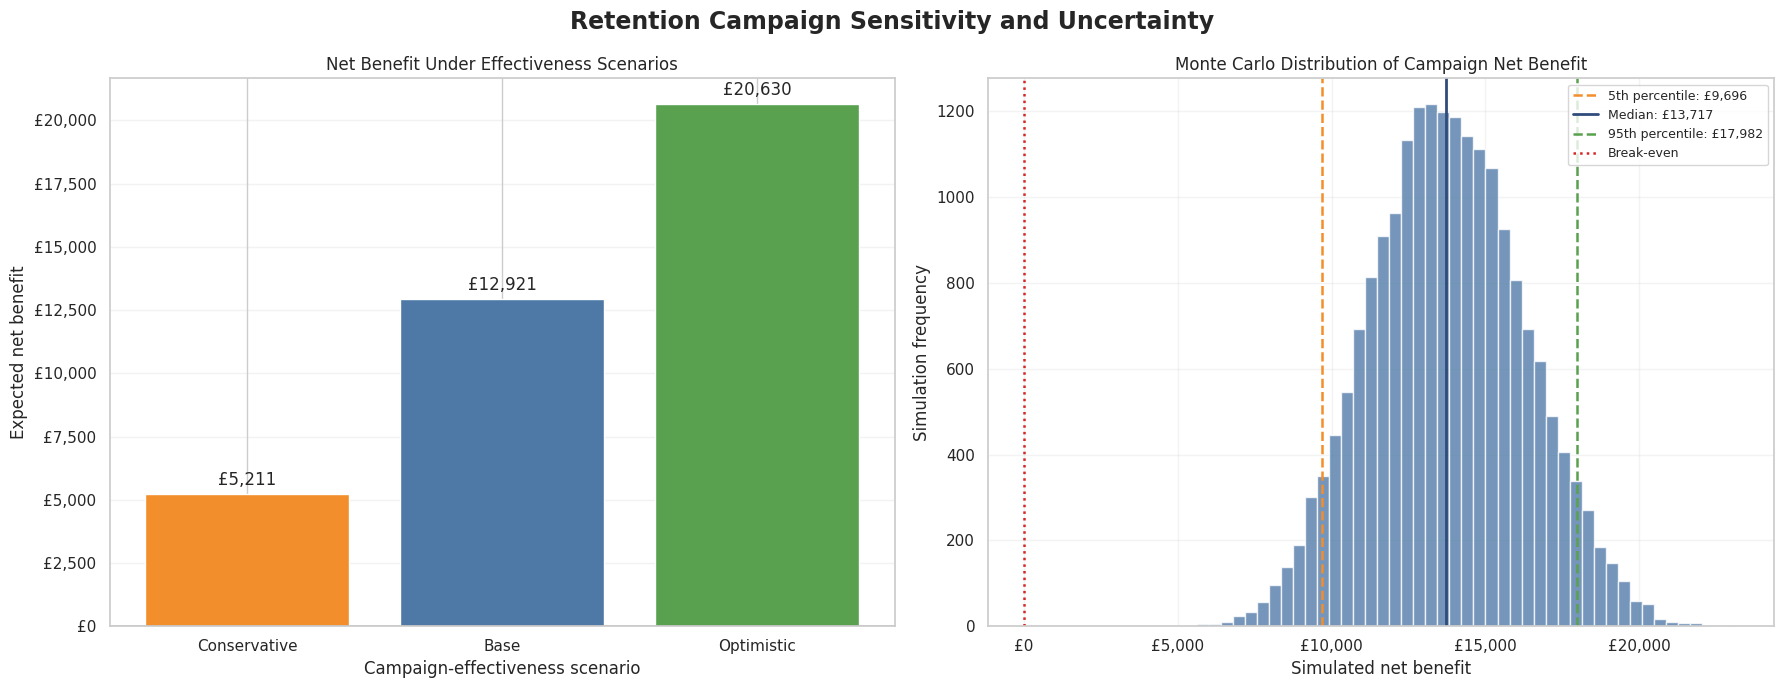

In [54]:
# ============================================================
# CAMPAIGN SENSITIVITY AND UNCERTAINTY ANALYSIS
# Uses the fixed £2,500 primary campaign allocation
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# ------------------------------------------------------------
# 1. Lock the selected primary campaign
# ------------------------------------------------------------

sensitivity_campaign = primary_campaign_allocation.copy()

locked_campaign_customers = len(sensitivity_campaign)

locked_campaign_cost = (
    sensitivity_campaign["expected_campaign_cost"].sum()
)

locked_revenue_at_risk = (
    sensitivity_campaign["revenue_at_risk"].sum()
)

base_expected_preserved_revenue = (
    sensitivity_campaign["expected_preserved_revenue"].sum()
)

base_expected_net_benefit = (
    sensitivity_campaign["expected_net_benefit"].sum()
)

# Percentage of the base assumed effect required to break even
portfolio_break_even_multiplier = (
    locked_campaign_cost
    / base_expected_preserved_revenue
)

# ------------------------------------------------------------
# 2. Deterministic sensitivity scenarios
#
# Conservative = 50% of base assumed effectiveness
# Base         = 100%
# Optimistic   = 150%
# ------------------------------------------------------------

effectiveness_scenarios = pd.DataFrame(
    {
        "Scenario": [
            "Conservative",
            "Base",
            "Optimistic"
        ],
        "Effectiveness_Multiplier": [
            0.50,
            1.00,
            1.50
        ]
    }
)

scenario_records = []

for _, scenario_row in effectiveness_scenarios.iterrows():
    scenario_name = scenario_row["Scenario"]
    multiplier = scenario_row[
        "Effectiveness_Multiplier"
    ]

    effective_risk_reduction = np.minimum(
        sensitivity_campaign[
            "assumed_relative_risk_reduction"
        ] * multiplier,
        1.0
    )

    customer_preserved_revenue = (
        sensitivity_campaign["revenue_at_risk"]
        * effective_risk_reduction
    )

    customer_net_benefit = (
        customer_preserved_revenue
        - sensitivity_campaign["expected_campaign_cost"]
    )

    scenario_preserved_revenue = (
        customer_preserved_revenue.sum()
    )

    scenario_net_benefit = (
        scenario_preserved_revenue
        - locked_campaign_cost
    )

    scenario_roi = (
        scenario_net_benefit
        / locked_campaign_cost
        * 100
    )

    profitable_customers = int(
        (customer_net_benefit > 0).sum()
    )

    scenario_records.append(
        {
            "Scenario": scenario_name,
            "Effectiveness_Multiplier":
                multiplier,
            "Campaign_Customers":
                locked_campaign_customers,
            "Campaign_Cost":
                locked_campaign_cost,
            "Expected_Preserved_Revenue":
                scenario_preserved_revenue,
            "Expected_Net_Benefit":
                scenario_net_benefit,
            "Expected_ROI_Percent":
                scenario_roi,
            "Profitable_Customers":
                profitable_customers,
            "Profitable_Customer_Share_Percent":
                profitable_customers
                / locked_campaign_customers
                * 100
        }
    )

campaign_sensitivity_summary = pd.DataFrame(
    scenario_records
)

# ------------------------------------------------------------
# 3. Define strategy-specific uncertainty ranges
#
# These triangular distributions are transparent planning
# assumptions—not experimentally estimated distributions.
# ------------------------------------------------------------

uplift_uncertainty_assumptions = pd.DataFrame(
    {
        "retention_strategy": [
            "Rescue Now",
            "Protect High Value",
            "Reactivate Efficiently",
            "Nurture / Monitor"
        ],
        "Minimum_Risk_Reduction": [
            0.10,
            0.03,
            0.05,
            0.01
        ],
        "Most_Likely_Risk_Reduction": [
            0.25,
            0.08,
            0.15,
            0.03
        ],
        "Maximum_Risk_Reduction": [
            0.40,
            0.15,
            0.25,
            0.06
        ]
    }
)

primary_strategy_exposure = (
    sensitivity_campaign
    .groupby("retention_strategy")
    .agg(
        Selected_Customers=("customer_id", "size"),
        Revenue_At_Risk=("revenue_at_risk", "sum"),
        Campaign_Cost=("expected_campaign_cost", "sum")
    )
    .reset_index()
    .merge(
        uplift_uncertainty_assumptions,
        on="retention_strategy",
        how="left",
        validate="one_to_one"
    )
)

strategy_order = [
    "Rescue Now",
    "Protect High Value",
    "Reactivate Efficiently",
    "Nurture / Monitor"
]

primary_strategy_exposure = (
    primary_strategy_exposure
    .set_index("retention_strategy")
    .reindex(strategy_order)
    .reset_index()
)

# ------------------------------------------------------------
# 4. Monte Carlo simulation
# ------------------------------------------------------------

MONTE_CARLO_SIMULATIONS = 20000
RANDOM_SEED = 42

random_generator = np.random.default_rng(
    RANDOM_SEED
)

simulation_preserved_revenue = np.zeros(
    MONTE_CARLO_SIMULATIONS
)

for _, strategy_row in primary_strategy_exposure.iterrows():
    simulated_risk_reduction = (
        random_generator.triangular(
            left=strategy_row[
                "Minimum_Risk_Reduction"
            ],
            mode=strategy_row[
                "Most_Likely_Risk_Reduction"
            ],
            right=strategy_row[
                "Maximum_Risk_Reduction"
            ],
            size=MONTE_CARLO_SIMULATIONS
        )
    )

    simulation_preserved_revenue += (
        simulated_risk_reduction
        * strategy_row["Revenue_At_Risk"]
    )

simulation_net_benefit = (
    simulation_preserved_revenue
    - locked_campaign_cost
)

simulation_roi_percent = (
    simulation_net_benefit
    / locked_campaign_cost
    * 100
)

probability_positive_net_benefit = (
    np.mean(simulation_net_benefit > 0)
    * 100
)

probability_exceeding_base_cost = (
    np.mean(
        simulation_preserved_revenue
        > locked_campaign_cost
    )
    * 100
)

monte_carlo_summary = pd.DataFrame(
    [
        {
            "Simulations":
                MONTE_CARLO_SIMULATIONS,
            "Mean_Preserved_Revenue":
                simulation_preserved_revenue.mean(),
            "Mean_Net_Benefit":
                simulation_net_benefit.mean(),
            "P05_Net_Benefit":
                np.percentile(
                    simulation_net_benefit,
                    5
                ),
            "Median_Net_Benefit":
                np.percentile(
                    simulation_net_benefit,
                    50
                ),
            "P95_Net_Benefit":
                np.percentile(
                    simulation_net_benefit,
                    95
                ),
            "Mean_ROI_Percent":
                simulation_roi_percent.mean(),
            "P05_ROI_Percent":
                np.percentile(
                    simulation_roi_percent,
                    5
                ),
            "P95_ROI_Percent":
                np.percentile(
                    simulation_roi_percent,
                    95
                ),
            "Probability_Positive_Net_Benefit_Percent":
                probability_positive_net_benefit
        }
    ]
)

# ------------------------------------------------------------
# 5. Validation
# ------------------------------------------------------------

uncertainty_range_issues = int(
    (
        (
            uplift_uncertainty_assumptions[
                "Minimum_Risk_Reduction"
            ]
            >
            uplift_uncertainty_assumptions[
                "Most_Likely_Risk_Reduction"
            ]
        )
        |
        (
            uplift_uncertainty_assumptions[
                "Most_Likely_Risk_Reduction"
            ]
            >
            uplift_uncertainty_assumptions[
                "Maximum_Risk_Reduction"
            ]
        )
        |
        (
            uplift_uncertainty_assumptions[
                "Minimum_Risk_Reduction"
            ] < 0
        )
        |
        (
            uplift_uncertainty_assumptions[
                "Maximum_Risk_Reduction"
            ] > 1
        )
    ).sum()
)

sensitivity_validation_records = [
    {
        "Validation Check":
            "Primary customer count changed",
        "Issues Found": int(
            len(sensitivity_campaign)
            != len(primary_campaign_allocation)
        ),
        "Expected": 0
    },
    {
        "Validation Check":
            "Duplicate primary campaign customers",
        "Issues Found": int(
            sensitivity_campaign[
                "customer_id"
            ].duplicated().sum()
        ),
        "Expected": 0
    },
    {
        "Validation Check":
            "Missing strategy uncertainty assumptions",
        "Issues Found": int(
            primary_strategy_exposure[
                "Most_Likely_Risk_Reduction"
            ].isna().sum()
        ),
        "Expected": 0
    },
    {
        "Validation Check":
            "Invalid uncertainty ranges",
        "Issues Found": uncertainty_range_issues,
        "Expected": 0
    },
    {
        "Validation Check":
            "Non-finite simulated benefits",
        "Issues Found": int(
            (
                ~np.isfinite(
                    simulation_net_benefit
                )
            ).sum()
        ),
        "Expected": 0
    },
    {
        "Validation Check":
            "Preserved revenue exceeds revenue at risk",
        "Issues Found": int(
            (
                simulation_preserved_revenue
                > locked_revenue_at_risk + 1e-9
            ).sum()
        ),
        "Expected": 0
    },
    {
        "Validation Check":
            "Base scenario differs from locked campaign",
        "Issues Found": int(
            not np.isclose(
                campaign_sensitivity_summary.loc[
                    campaign_sensitivity_summary[
                        "Scenario"
                    ] == "Base",
                    "Expected_Net_Benefit"
                ].iloc[0],
                base_expected_net_benefit,
                atol=0.01
            )
        ),
        "Expected": 0
    },
    {
        "Validation Check":
            "Invalid break-even multiplier",
        "Issues Found": int(
            not (
                0
                <= portfolio_break_even_multiplier
                <= 1
            )
        ),
        "Expected": 0
    }
]

campaign_sensitivity_validation = pd.DataFrame(
    sensitivity_validation_records
)

campaign_sensitivity_validation["Status"] = np.where(
    campaign_sensitivity_validation["Issues Found"]
    == campaign_sensitivity_validation["Expected"],
    "PASS",
    "CHECK"
)

# ------------------------------------------------------------
# 6. Display results
# ------------------------------------------------------------

print("Primary campaign sensitivity analysis completed.")
print(f"Locked campaign budget: £{locked_campaign_cost:,.2f}")
print(
    f"Locked campaign customers: "
    f"{locked_campaign_customers:,}"
)
print(
    "Portfolio break-even effectiveness: "
    f"{portfolio_break_even_multiplier:.2%} "
    "of the base assumptions"
)
print(
    "Probability of positive simulated net benefit: "
    f"{probability_positive_net_benefit:.2f}%"
)

print("\nDeterministic effectiveness scenarios:")

display(
    campaign_sensitivity_summary.round(
        {
            "Effectiveness_Multiplier": 2,
            "Campaign_Cost": 2,
            "Expected_Preserved_Revenue": 2,
            "Expected_Net_Benefit": 2,
            "Expected_ROI_Percent": 2,
            "Profitable_Customer_Share_Percent": 2
        }
    )
)

print("\nStrategy-level uncertainty assumptions:")

display(
    primary_strategy_exposure.round(
        {
            "Revenue_At_Risk": 2,
            "Campaign_Cost": 2,
            "Minimum_Risk_Reduction": 3,
            "Most_Likely_Risk_Reduction": 3,
            "Maximum_Risk_Reduction": 3
        }
    )
)

print("\nMonte Carlo uncertainty summary:")

display(
    monte_carlo_summary.round(
        {
            "Mean_Preserved_Revenue": 2,
            "Mean_Net_Benefit": 2,
            "P05_Net_Benefit": 2,
            "Median_Net_Benefit": 2,
            "P95_Net_Benefit": 2,
            "Mean_ROI_Percent": 2,
            "P05_ROI_Percent": 2,
            "P95_ROI_Percent": 2,
            "Probability_Positive_Net_Benefit_Percent": 2
        }
    )
)

print("\nSensitivity-analysis validation:")
display(campaign_sensitivity_validation)

# ------------------------------------------------------------
# 7. Visualize deterministic and simulated uncertainty
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

scenario_colors = [
    "#f28e2b",
    "#4e79a7",
    "#59a14f"
]

scenario_bars = axes[0].bar(
    campaign_sensitivity_summary["Scenario"],
    campaign_sensitivity_summary[
        "Expected_Net_Benefit"
    ],
    color=scenario_colors
)

axes[0].bar_label(
    scenario_bars,
    labels=[
        f"£{value:,.0f}"
        for value in campaign_sensitivity_summary[
            "Expected_Net_Benefit"
        ]
    ],
    padding=4
)

axes[0].axhline(
    0,
    color="black",
    linewidth=1
)

axes[0].yaxis.set_major_formatter(
    FuncFormatter(
        lambda value, _: f"£{value:,.0f}"
    )
)

axes[0].set_title(
    "Net Benefit Under Effectiveness Scenarios"
)
axes[0].set_xlabel("Campaign-effectiveness scenario")
axes[0].set_ylabel("Expected net benefit")
axes[0].grid(axis="y", alpha=0.25)
axes[0].set_axisbelow(True)

axes[1].hist(
    simulation_net_benefit,
    bins=45,
    color="#4e79a7",
    alpha=0.78,
    edgecolor="white"
)

p05_net_benefit = np.percentile(
    simulation_net_benefit,
    5
)

median_net_benefit = np.percentile(
    simulation_net_benefit,
    50
)

p95_net_benefit = np.percentile(
    simulation_net_benefit,
    95
)

axes[1].axvline(
    p05_net_benefit,
    color="#f28e2b",
    linestyle="--",
    linewidth=1.8,
    label=f"5th percentile: £{p05_net_benefit:,.0f}"
)

axes[1].axvline(
    median_net_benefit,
    color="#2f4b7c",
    linestyle="-",
    linewidth=2,
    label=f"Median: £{median_net_benefit:,.0f}"
)

axes[1].axvline(
    p95_net_benefit,
    color="#59a14f",
    linestyle="--",
    linewidth=1.8,
    label=f"95th percentile: £{p95_net_benefit:,.0f}"
)

axes[1].axvline(
    0,
    color="#d62728",
    linestyle=":",
    linewidth=1.8,
    label="Break-even"
)

axes[1].xaxis.set_major_formatter(
    FuncFormatter(
        lambda value, _: f"£{value:,.0f}"
    )
)

axes[1].set_title(
    "Monte Carlo Distribution of Campaign Net Benefit"
)
axes[1].set_xlabel("Simulated net benefit")
axes[1].set_ylabel("Simulation frequency")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.22)

fig.suptitle(
    "Retention Campaign Sensitivity and Uncertainty",
    fontsize=17,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

### Final Campaign Robustness

The selected £2,498 campaign remains profitable across all tested effectiveness scenarios. Its simulated downside is positive, with a 5th-percentile net benefit of approximately £9,696. These results demonstrate robustness within the specified assumptions, but campaign effectiveness must ultimately be validated through a controlled pilot or A/B test.


In [55]:
# ============================================================
# FINAL EXPORT — OPERATIONAL AND POWER BI DATA PACKAGE
# ============================================================

from pathlib import Path
import shutil
import re
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Output location
# ------------------------------------------------------------

output_root = Path("/content") if Path("/content").exists() else Path.cwd()
output_directory = output_root / "ecommerce_churn_powerbi"

output_directory.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# 2. Helpers
# ------------------------------------------------------------

def get_dataframe(*variable_names, required=False):
    """Return the first available DataFrame from the supplied names."""

    for variable_name in variable_names:
        value = globals().get(variable_name)

        if isinstance(value, pd.DataFrame):
            return value.copy()

    if required:
        raise NameError(
            "None of these required DataFrames were found: "
            + ", ".join(variable_names)
        )

    return None


def numeric_sum(dataframe, column):
    if dataframe is None or column not in dataframe.columns:
        return np.nan

    return float(
        pd.to_numeric(dataframe[column], errors="coerce").fillna(0).sum()
    )


def normalized_name(value):
    return re.sub(r"[^a-z0-9]", "", str(value).lower())


# ------------------------------------------------------------
# 3. Retrieve final project tables
# ------------------------------------------------------------

customer_source = get_dataframe(
    "campaign_economics",
    "latest_customer_scores",
    required=True
)

primary_campaign_export = get_dataframe(
    "primary_campaign_table",
    "primary_campaign_allocation",
    required=True
)

risk_tier_export = get_dataframe("risk_tier_summary")
strategy_export = get_dataframe("strategy_summary")
campaign_economics_export = get_dataframe("campaign_strategy_summary")
budget_scenario_export = get_dataframe("budget_scenario_summary")
budget_allocation_export = get_dataframe("budget_strategy_allocation")
sensitivity_export = get_dataframe("campaign_sensitivity_summary")
monte_carlo_export = get_dataframe("monte_carlo_summary")
campaign_assumptions_export = get_dataframe("campaign_assumptions")
capacity_export = get_dataframe("capacity_plan")


# ------------------------------------------------------------
# 4. Create the operational customer-score table
# ------------------------------------------------------------

operational_columns = [
    "customer_id",
    "snapshot_date",
    "latest_country",
    "churn_probability",
    "risk_percentile",
    "risk_tier",
    "value_percentile",
    "retention_strategy",
    "recency_days",
    "orders_180d",
    "revenue_180d",
    "activity_span_180d",
    "estimated_90d_customer_value",
    "revenue_at_risk",
    "campaign_channel",
    "expected_campaign_cost",
    "expected_preserved_revenue",
    "expected_net_benefit",
    "net_benefit_per_pound",
    "value_aware_action",
    "actual_churn"
]

available_operational_columns = [
    column
    for column in operational_columns
    if column in customer_source.columns
]

customer_scores_export = customer_source[
    available_operational_columns
].copy()

primary_customer_ids = set(
    primary_campaign_export["customer_id"].astype(str)
)

customer_scores_export["selected_for_primary_campaign"] = (
    customer_scores_export["customer_id"]
    .astype(str)
    .isin(primary_customer_ids)
    .astype("int8")
)

if "campaign_priority_rank" in primary_campaign_export.columns:
    priority_table = primary_campaign_export[
        ["customer_id", "campaign_priority_rank"]
    ].drop_duplicates("customer_id")

    priority_mapping = dict(
        zip(
            priority_table["customer_id"].astype(str),
            priority_table["campaign_priority_rank"]
        )
    )

    customer_scores_export["primary_campaign_priority_rank"] = (
        customer_scores_export["customer_id"]
        .astype(str)
        .map(priority_mapping)
    )


# ------------------------------------------------------------
# 5. Model-performance summary
# ------------------------------------------------------------

raw_test_metrics = globals().get("final_test_metric_values", {})

if isinstance(raw_test_metrics, pd.Series):
    raw_test_metrics = raw_test_metrics.to_dict()
elif isinstance(raw_test_metrics, pd.DataFrame) and len(raw_test_metrics) == 1:
    raw_test_metrics = raw_test_metrics.iloc[0].to_dict()
elif not isinstance(raw_test_metrics, dict):
    raw_test_metrics = {}

normalized_metrics = {
    normalized_name(key): value
    for key, value in raw_test_metrics.items()
}


def test_metric(label, fallback):
    return normalized_metrics.get(normalized_name(label), fallback)


final_threshold = globals().get(
    "LOCKED_DECISION_THRESHOLD",
    globals().get("FINAL_DECISION_THRESHOLD", 0.414)
)

model_performance_export = pd.DataFrame(
    [{
        "evaluation_period": "Out-of-time test",
        "model": "Tuned Logistic Regression",
        "feature_set": "Drift-Robust Feature Set",
        "feature_count": 44,
        "decision_threshold": final_threshold,
        "roc_auc": test_metric("ROC-AUC", 0.773),
        "pr_auc": test_metric("PR-AUC", 0.683),
        "accuracy": test_metric("Accuracy", 0.648),
        "balanced_accuracy": test_metric("Balanced Accuracy", 0.681),
        "precision": test_metric("Precision", 0.549),
        "recall": test_metric("Recall", 0.881),
        "f1": test_metric("F1", 0.677),
        "brier_score": test_metric("Brier Score", 0.197),
        "recall_at_top_20_percent": test_metric(
            "Recall @ Top 20%", 0.358
        ),
        "lift_at_top_20_percent": test_metric(
            "Lift @ Top 20%", 1.789
        )
    }]
)


# ------------------------------------------------------------
# 6. Executive KPI table
# ------------------------------------------------------------

snapshot_date = pd.to_datetime(
    customer_scores_export["snapshot_date"]
).max()

primary_spend = numeric_sum(
    primary_campaign_export,
    "expected_campaign_cost"
)

primary_preserved_revenue = numeric_sum(
    primary_campaign_export,
    "expected_preserved_revenue"
)

primary_net_benefit = numeric_sum(
    primary_campaign_export,
    "expected_net_benefit"
)

break_even_effectiveness = (
    100 * primary_spend / primary_preserved_revenue
    if primary_preserved_revenue > 0
    else np.nan
)

executive_kpis_export = pd.DataFrame(
    [{
        "snapshot_date": snapshot_date,
        "customers_scored": customer_scores_export[
            "customer_id"
        ].nunique(),
        "total_estimated_90d_value": numeric_sum(
            customer_scores_export,
            "estimated_90d_customer_value"
        ),
        "total_probability_weighted_revenue_at_risk": numeric_sum(
            customer_scores_export,
            "revenue_at_risk"
        ),
        "primary_campaign_customers": primary_campaign_export[
            "customer_id"
        ].nunique(),
        "primary_campaign_spend": primary_spend,
        "expected_preserved_revenue": primary_preserved_revenue,
        "expected_net_benefit": primary_net_benefit,
        "expected_roi_percent": (
            100 * primary_net_benefit / primary_spend
            if primary_spend > 0 else np.nan
        ),
        "break_even_effectiveness_percent": break_even_effectiveness,
        "test_roc_auc": test_metric("ROC-AUC", 0.773),
        "test_pr_auc": test_metric("PR-AUC", 0.683),
        "test_recall": test_metric("Recall", 0.881),
        "test_precision": test_metric("Precision", 0.549),
        "test_lift_at_top_20_percent": test_metric(
            "Lift @ Top 20%", 1.789
        )
    }]
)


# ------------------------------------------------------------
# 7. Assemble export tables
# ------------------------------------------------------------

export_tables = {
    "01_executive_kpis.csv": executive_kpis_export,
    "02_model_performance.csv": model_performance_export,
    "03_customer_risk_scores.csv": customer_scores_export,
    "04_primary_campaign_targets.csv": primary_campaign_export
}

optional_exports = [
    ("05_risk_tier_summary.csv", risk_tier_export),
    ("06_retention_strategy_summary.csv", strategy_export),
    ("07_campaign_economics_summary.csv", campaign_economics_export),
    ("08_budget_scenarios.csv", budget_scenario_export),
    ("09_budget_strategy_allocation.csv", budget_allocation_export),
    ("10_sensitivity_scenarios.csv", sensitivity_export),
    ("11_monte_carlo_summary.csv", monte_carlo_export),
    ("12_campaign_assumptions.csv", campaign_assumptions_export),
    ("13_operational_capacity.csv", capacity_export)
]

for filename, dataframe in optional_exports:
    if dataframe is not None:
        export_tables[filename] = dataframe


# ------------------------------------------------------------
# 8. Consolidate project validation results
# ------------------------------------------------------------

validation_sources = [
    (
        "Risk Segmentation",
        ("risk_segmentation_validation", "risk_tier_validation")
    ),
    (
        "Risk-Value Strategy",
        ("risk_value_validation", "strategy_validation")
    ),
    (
        "Campaign Economics",
        ("campaign_economics_validation",)
    ),
    (
        "Budget Optimisation",
        ("budget_optimization_validation",)
    ),
    (
        "Sensitivity Analysis",
        ("campaign_sensitivity_validation",)
    )
]

validation_tables = []

for validation_stage, possible_names in validation_sources:
    validation_frame = get_dataframe(*possible_names)

    if validation_frame is not None:
        validation_frame.insert(
            0,
            "Validation Stage",
            validation_stage
        )
        validation_tables.append(validation_frame)

if validation_tables:
    consolidated_validation = pd.concat(
        validation_tables,
        ignore_index=True
    )
else:
    consolidated_validation = pd.DataFrame()

export_tables["14_validation_results.csv"] = consolidated_validation


# ------------------------------------------------------------
# 9. Export-specific validation
# ------------------------------------------------------------

required_customer_columns = {
    "customer_id",
    "churn_probability",
    "revenue_at_risk",
    "retention_strategy"
}

missing_required_columns = len(
    required_customer_columns
    - set(customer_scores_export.columns)
)

duplicate_customer_scores = int(
    customer_scores_export["customer_id"].duplicated().sum()
)

duplicate_primary_customers = int(
    primary_campaign_export["customer_id"].duplicated().sum()
)

primary_customers_not_scored = len(
    set(primary_campaign_export["customer_id"].astype(str))
    - set(customer_scores_export["customer_id"].astype(str))
)

if "expected_net_benefit" in primary_campaign_export.columns:
    nonpositive_primary_benefit = int(
        (
            pd.to_numeric(
                primary_campaign_export["expected_net_benefit"],
                errors="coerce"
            ) <= 0
        ).sum()
    )
else:
    nonpositive_primary_benefit = 0

upstream_validation_failures = 0

if not consolidated_validation.empty and \
        "Status" in consolidated_validation.columns:
    upstream_validation_failures = int(
        consolidated_validation["Status"]
        .astype(str)
        .str.upper()
        .ne("PASS")
        .sum()
    )

export_validation = pd.DataFrame(
    {
        "Validation Check": [
            "Missing required operational columns",
            "Duplicate customer-score rows",
            "Duplicate primary-campaign customers",
            "Primary customers absent from score table",
            "Primary customers with non-positive benefit",
            "Upstream validation failures"
        ],
        "Issues Found": [
            missing_required_columns,
            duplicate_customer_scores,
            duplicate_primary_customers,
            primary_customers_not_scored,
            nonpositive_primary_benefit,
            upstream_validation_failures
        ],
        "Expected": [0, 0, 0, 0, 0, 0]
    }
)

export_validation["Status"] = np.where(
    export_validation["Issues Found"]
    == export_validation["Expected"],
    "PASS",
    "CHECK"
)

export_tables["15_export_validation.csv"] = export_validation


# ------------------------------------------------------------
# 10. Create automatic data dictionary
# ------------------------------------------------------------

field_descriptions = {
    "customer_id": "Anonymised customer identifier.",
    "snapshot_date": "Date on which customer risk was calculated.",
    "latest_country": "Most recently observed customer country.",
    "churn_probability": "Predicted probability of no purchase during the next 90 days.",
    "risk_percentile": "Customer percentile based on predicted churn probability.",
    "risk_tier": "Operational churn-risk classification.",
    "estimated_90d_customer_value": "Estimated customer value over the next 90 days.",
    "revenue_at_risk": "Predicted churn probability multiplied by estimated 90-day value.",
    "retention_strategy": "Risk-and-value-based recommended treatment group.",
    "expected_campaign_cost": "Planning cost of targeting the customer.",
    "expected_preserved_revenue": "Assumption-based expected revenue preserved.",
    "expected_net_benefit": "Expected preserved revenue minus campaign cost.",
    "selected_for_primary_campaign": "Equals 1 when selected under the primary budget.",
    "actual_churn": "Historical outcome used for evaluation; unavailable during live scoring."
}

dictionary_records = []

for filename, dataframe in export_tables.items():
    for column in dataframe.columns:
        dictionary_records.append(
            {
                "Dataset": filename,
                "Column": column,
                "Data Type": str(dataframe[column].dtype),
                "Description": field_descriptions.get(
                    column,
                    "Derived project output field."
                )
            }
        )

data_dictionary = pd.DataFrame(dictionary_records)
export_tables["16_data_dictionary.csv"] = data_dictionary


# ------------------------------------------------------------
# 11. Dataset manifest
# ------------------------------------------------------------

dataset_manifest = pd.DataFrame(
    [
        {
            "File": filename,
            "Rows": len(dataframe),
            "Columns": dataframe.shape[1]
        }
        for filename, dataframe in export_tables.items()
    ]
)

export_tables["00_dataset_manifest.csv"] = dataset_manifest


# ------------------------------------------------------------
# 12. Write CSV files
# ------------------------------------------------------------

for filename, dataframe in export_tables.items():
    dataframe.to_csv(
        output_directory / filename,
        index=False,
        date_format="%Y-%m-%d"
    )


# ------------------------------------------------------------
# 13. README for Power BI users
# ------------------------------------------------------------

readme_text = f"""
E-COMMERCE CHURN AND RETENTION ANALYTICS
========================================

Operational snapshot: {snapshot_date.date()}
Customer-score grain: one row per customer
Primary campaign grain: one row per selected customer

Recommended Power BI starting tables:
- 01_executive_kpis.csv
- 03_customer_risk_scores.csv
- 04_primary_campaign_targets.csv
- 05_risk_tier_summary.csv
- 06_retention_strategy_summary.csv
- 08_budget_scenarios.csv

Important interpretation notes:
- The churn model predicts 90-day purchase inactivity.
- Revenue at risk is probability-weighted exposure, not guaranteed lost revenue.
- Preserved revenue, net benefit and ROI depend on planning assumptions.
- actual_churn is a historical evaluation field and is not available in live deployment.
- Real retention uplift should be measured through a controlled campaign experiment.
""".strip()

(output_directory / "README.txt").write_text(
    readme_text,
    encoding="utf-8"
)


# ------------------------------------------------------------
# 14. Create downloadable ZIP bundle
# ------------------------------------------------------------

zip_base = output_root / "ecommerce_churn_powerbi_bundle"
zip_path = Path(f"{zip_base}.zip")

if zip_path.exists():
    zip_path.unlink()

zip_path = Path(
    shutil.make_archive(
        str(zip_base),
        "zip",
        root_dir=output_directory
    )
)


# ------------------------------------------------------------
# 15. Final output
# ------------------------------------------------------------

print("Final export completed successfully.")
print(f"Output directory: {output_directory}")
print(f"Files exported: {len(export_tables) + 1}")
print(f"ZIP package: {zip_path}")
print(f"ZIP size: {zip_path.stat().st_size / (1024 ** 2):,.2f} MB")

print("\nExport validation:")
display(export_validation)

print("\nDataset manifest:")
display(dataset_manifest)

# Automatically download in Google Colab.
try:
    from google.colab import files
    files.download(str(zip_path))
except ImportError:
    pass

Final export completed successfully.
Output directory: /content/ecommerce_churn_powerbi
Files exported: 18
ZIP package: /content/ecommerce_churn_powerbi_bundle.zip
ZIP size: 0.30 MB

Export validation:


,Validation Check,Issues Found,Expected,Status
0,Missing required operational columns,0,0,PASS
1,Duplicate customer-score rows,0,0,PASS
2,Duplicate primary-campaign customers,0,0,PASS
3,Primary customers absent from score table,0,0,PASS
4,Primary customers with non-positive benefit,0,0,PASS
5,Upstream validation failures,0,0,PASS



Dataset manifest:


,File,Rows,Columns
0,01_executive_kpis.csv,1,15
1,02_model_performance.csv,1,15
2,03_customer_risk_scores.csv,2768,22
3,04_primary_campaign_targets.csv,1250,18
4,05_risk_tier_summary.csv,4,15
5,06_retention_strategy_summary.csv,4,10
6,07_campaign_economics_summary.csv,4,12
7,08_budget_scenarios.csv,3,14
8,09_budget_strategy_allocation.csv,12,3
9,10_sensitivity_scenarios.csv,3,9


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>